# **Mundial 2026 — Modelo Predictivo**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

## 1. Carga de Datos

In [ ]:
df_match = pd.read_csv('/content/results.csv')
df_rankings = pd.read_csv('/content/national_teams.csv')

# Formato fecha
df_match['date'] = pd.to_datetime(df_match['date'])
df_recent_matches = df_match[df_match['date'] > '2010-01-01'].copy()

# Limpieza goles
df_recent_matches = df_recent_matches.dropna(subset=['home_score', 'away_score'])
df_recent_matches['home_score'] = df_recent_matches['home_score'].astype(int)
df_recent_matches['away_score'] = df_recent_matches['away_score'].astype(int)

# Limpieza rankings
df_rankings = df_rankings.drop(columns=['team_image_url', 'coach_name', 'url', 'last_season'])
df_rankings['confederation'] = df_rankings['confederation'].fillna('AFC')
df_rankings.loc[df_rankings['name'] == 'England', 'total_market_value'] = 1_620_000_000
df_rankings.loc[df_rankings['name'] == 'Spain',   'total_market_value'] = 1_310_000_000
df_rankings.loc[df_rankings['name'] == 'France',  'total_market_value'] = 1_360_000_000

# Limpieza columnas innecesarias
df_rankings = df_rankings[['name','confederation','squad_size','average_age',
                            'foreigners_number','foreigners_percentage',
                            'total_market_value','fifa_ranking']]

print('df_recent_matches:', df_recent_matches.shape)
print('df_rankings:', df_rankings.shape)

df_recent_matches: (15632, 9)
df_rankings: (118, 8)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Feature Engineering

In [ ]:
# ── FEATURE 1: Log_MarketValue ──────────────────────────────────────────────
df_rankings['log_market_value_raw'] = np.log1p(df_rankings['total_market_value'])
scaler_mv = MinMaxScaler()
df_rankings['Log_MarketValue'] = scaler_mv.fit_transform(df_rankings[['log_market_value_raw']])
df_rankings = df_rankings.drop(columns=['log_market_value_raw'])

print(df_rankings[['name','total_market_value','Log_MarketValue']]
      .sort_values('Log_MarketValue', ascending=False).head(10))

           name  total_market_value  Log_MarketValue
28      England        1.620000e+09         1.000000
32       France        1.360000e+09         0.976541
30        Spain        1.310000e+09         0.971518
46       Brazil        9.240000e+08         0.924710
27      Germany        8.495000e+08         0.913437
29     Portugal        8.385000e+08         0.911689
31        Italy        8.250000e+08         0.909513
34  Netherlands        7.970000e+08         0.904883
44    Argentina        7.122000e+08         0.889798
47       Norway        5.229000e+08         0.848366


In [ ]:
ELO_INICIAL = 1500

K_MAP = {
    'FIFA World Cup': 60,
    'UEFA Euro': 50,
    'Copa América': 50,
    'AFC Asian Cup': 30,
    'Africa Cup of Nations': 40,
    'UEFA Nations League': 40,
    'Gold Cup':30,
    'Friendly': 20,
}

K_DEFAULT = 30 # Para otros torneos

def get_k(tournament):
    return K_MAP.get(tournament, K_DEFAULT)

def expected(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

equipos = set(df_recent_matches['home_team']).union(set(df_recent_matches['away_team']))
elo_dict = {equipo: ELO_INICIAL for equipo in equipos}

for _, row in df_recent_matches.sort_values('date').iterrows():
    home = row['home_team']
    away = row['away_team']
    k = get_k(row['tournament'])

    elo_h = elo_dict[home]
    elo_a = elo_dict[away]

    exp_h = expected(elo_h, elo_a)
    exp_a = expected(elo_a, elo_h)

    if row['home_score'] > row['away_score']:
        res_h, res_a = 1, 0
    elif row['home_score'] < row['away_score']:
        res_h, res_a = 0, 1
    else:
        res_h, res_a = 0.5, 0.5

    elo_dict[home] = elo_h + k * (res_h - exp_h)
    elo_dict[away] = elo_a + k * (res_a - exp_a)

df_elo = pd.DataFrame(list(elo_dict.items()), columns=['name', 'ELO'])
df_elo = df_elo.sort_values('ELO', ascending=False).reset_index(drop=True)

print(df_elo.head(20))

           name          ELO
0         Spain  1980.443257
1     Argentina  1951.173485
2        France  1907.282364
3       Morocco  1873.128810
4         Japan  1853.060701
5       England  1851.625990
6      Portugal  1840.232959
7        Brazil  1827.695576
8       Germany  1824.344654
9   Netherlands  1823.811937
10     Colombia  1820.839662
11      Senegal  1805.514178
12      Croatia  1788.784696
13    Australia  1786.962439
14      Ecuador  1786.603545
15       Mexico  1783.226939
16         Iran  1781.237496
17  South Korea  1774.135761
18      Algeria  1773.875031
19        Italy  1773.157416


In [ ]:
# ── FEATURE 3: Momentum_15 ──────────────────────────────────────────────────
torneos_oficiales = ['FIFA World Cup','UEFA Euro','Copa América','AFC Asian Cup',
                     'Africa Cup of Nations','UEFA Nations League']
df_oficial = df_recent_matches[df_recent_matches['tournament'] != 'Friendly'].copy()

def get_puntos(row, equipo):
    if equipo == row['home_team']:
        if row['home_score'] > row['away_score']: return 3
        elif row['home_score'] == row['away_score']: return 1
        else: return 0
    else:
        if row['away_score'] > row['home_score']: return 3
        elif row['away_score'] == row['home_score']: return 1
        else: return 0

home_l = df_oficial[['date','home_team','away_team','home_score','away_score','tournament']].copy()
home_l['equipo'] = home_l['home_team']
away_l = df_oficial[['date','home_team','away_team','home_score','away_score','tournament']].copy()
away_l['equipo'] = away_l['away_team']

df_long = pd.concat([home_l, away_l]).sort_values('date')
equipos_validos = set(df_rankings['name'])
df_long = df_long[df_long['equipo'].isin(equipos_validos)].copy()
df_long['puntos'] = df_long.apply(lambda r: get_puntos(r, r['equipo']), axis=1)

pesos = np.array([0.03,0.04,0.04,0.05,0.05,0.06,0.06,0.07,0.07,0.07,0.08,0.08,0.09,0.10,0.11])

def calc_momentum(grupo):
    ultimos = grupo.sort_values('date').tail(15)['puntos'].values
    n = len(ultimos)
    p = pesos[-n:]
    p = p / p.sum()
    return np.average(ultimos, weights=p)

df_momentum = df_long.groupby('equipo').apply(calc_momentum, include_groups=False).reset_index()
df_momentum.columns = ['name','Momentum_15']
scaler_mom = MinMaxScaler()
df_momentum['Momentum_15'] = scaler_mom.fit_transform(df_momentum[['Momentum_15']])

df_rankings = df_rankings.merge(df_momentum, on='name', how='left')
print(df_rankings[['name','Momentum_15']].sort_values('Momentum_15', ascending=False).head(10))

          name  Momentum_15
28     England     1.000000
47      Norway     0.980545
72     Morocco     0.922179
114    Vietnam     0.914397
41   Australia     0.883268
59     Senegal     0.879377
30       Spain     0.859922
42       Japan     0.856031
66     Croatia     0.832685
32      France     0.832685


In [ ]:
# ── EQUIPOS FALTANTES (no están en national_teams.csv) ──────────────────────
nombre_map = {
    'Bosnia and Herzegovina': 'Bosnia-Herzegovina',
    'Turkey': 'Turkiye',
    'Curacao': 'Curacao',
    'Cape Verde': 'Cape Verde',
    'Haiti': 'Haiti',
    'Ivory Coast': 'Ivory Coast',
    'DR Congo': 'DR Congo',
}

# Momentum para Haiti, Cape Verde, Ivory Coast, DR Congo
faltantes = ['Haiti', 'Cape Verde', 'Ivory Coast', 'DR Congo']
equipos_validos_ext = set(df_rankings['name']).union(set(faltantes))

home_ext = df_oficial[['date','home_team','away_team','home_score','away_score','tournament']].copy()
home_ext['equipo'] = home_ext['home_team']
away_ext = df_oficial[['date','home_team','away_team','home_score','away_score','tournament']].copy()
away_ext['equipo'] = away_ext['away_team']
df_long_ext = pd.concat([home_ext, away_ext]).sort_values('date')
df_long_ext = df_long_ext[df_long_ext['equipo'].isin(equipos_validos_ext)].copy()
df_long_ext['puntos'] = df_long_ext.apply(lambda r: get_puntos(r, r['equipo']), axis=1)

df_momentum_ext = df_long_ext.groupby('equipo').apply(calc_momentum, include_groups=False).reset_index()
df_momentum_ext.columns = ['name','Momentum_15']
df_momentum_ext['Momentum_15'] = scaler_mom.transform(df_momentum_ext[['Momentum_15']])
momentum_faltantes = df_momentum_ext[df_momentum_ext['name'].isin(faltantes)]

# Añadimos los 5 equipos
media_concacaf = df_rankings[df_rankings['confederation'] == 'CONCACAF']['Momentum_15'].mean()
mom_haiti    = momentum_faltantes[momentum_faltantes['name']=='Haiti']['Momentum_15'].values[0]
mom_cape     = momentum_faltantes[momentum_faltantes['name']=='Cape Verde']['Momentum_15'].values[0]
mom_ivory    = momentum_faltantes[momentum_faltantes['name']=='Ivory Coast']['Momentum_15'].values[0]
mom_drcongo  = momentum_faltantes[momentum_faltantes['name']=='DR Congo']['Momentum_15'].values[0]

nuevos_equipos = pd.DataFrame({
    'name':                 ['Haiti','Cape Verde','Ivory Coast','DR Congo','Curacao'],
    'confederation':        ['CONCACAF','CAF','CAF','CAF','CONCACAF'],
    'squad_size':           [23,23,23,23,23],
    'average_age':          [26.0,26.0,26.0,26.0,26.0],
    'foreigners_number':    [15,15,15,15,10],
    'foreigners_percentage':[65.0,65.0,65.0,65.0,43.0],
    'total_market_value':   [30_000_000,45_000_000,280_000_000,60_000_000,50_000_000],
    'fifa_ranking':         [83,73,48,62,97],
    'Log_MarketValue':      [None,None,None,None,None],
    'ELO':                  [1609.1,1601.7,1714.5,1668.0,1550.0],
    'ELO_norm':             [None,None,None,None,None],
    'Momentum_15':          [mom_haiti, mom_cape, mom_ivory, mom_drcongo, media_concacaf]
})

df_rankings = pd.concat([df_rankings, nuevos_equipos], ignore_index=True)

# Renormalizamos Log_MarketValue y ELO_norm con todos los equipos
df_rankings['log_mv_raw'] = np.log1p(df_rankings['total_market_value'])
df_rankings['Log_MarketValue'] = MinMaxScaler().fit_transform(df_rankings[['log_mv_raw']])
df_rankings['ELO_norm'] = MinMaxScaler().fit_transform(df_rankings[['ELO']])
df_rankings = df_rankings.drop(columns=['log_mv_raw'])

print('df_rankings shape:', df_rankings.shape)

df_rankings shape: (123, 12)


/tmp/ipykernel_1676/12997519.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_rankings = pd.concat([df_rankings, nuevos_equipos], ignore_index=True)


In [ ]:
# ── 48 CLASIFICADOS ─────────────────────────────────────────────────────────
clasificados_raw = [
    'Mexico','United States','Canada',
    'Germany','Switzerland','Scotland','France','Spain','Portugal',
    'Netherlands','Austria','Norway','Belgium','England','Croatia',
    'Bosnia and Herzegovina','Czech Republic','Turkey','Sweden',
    'Egypt','Senegal','South Africa','Cape Verde','Morocco',
    'Ivory Coast','Algeria','Tunisia','Ghana',
    'Iran','Uzbekistan','South Korea','Jordan','Japan','Australia',
    'Qatar','Saudi Arabia','Iraq',
    'Argentina','Ecuador','Colombia','Uruguay','Brazil','Paraguay',
    'Panama','Curacao','Haiti','DR Congo',
    'New Zealand'
]

clasificados_fix = [nombre_map.get(e, e) for e in clasificados_raw]
encontrados = [e for e in clasificados_fix if e in df_rankings['name'].values]
print(f'Encontrados: {len(encontrados)}/48')
print('Faltantes:', [e for e in clasificados_fix if e not in df_rankings['name'].values])

df_mundial = df_rankings[df_rankings['name'].isin(clasificados_fix)].copy().reset_index(drop=True)
print('df_mundial shape:', df_mundial.shape)
# ── Asignamos features directamente a df_mundial ────────────────────────────

# ELO desde elo_dict (fuente de verdad)
elo_manuales = {
    'Haiti': 1609.1, 'Cape Verde': 1601.7,
    'Ivory Coast': 1714.5, 'DR Congo': 1668.0, 'Curacao': 1550.0
}
df_mundial['ELO'] = df_mundial['name'].apply(
    lambda n: elo_manuales.get(n, elo_dict.get(n, np.nan))
)
scaler_elo48 = MinMaxScaler()
df_mundial['ELO_norm'] = scaler_elo48.fit_transform(df_mundial[['ELO']])

# Log_MarketValue
df_mundial['log_mv_raw'] = np.log1p(df_mundial['total_market_value'])
df_mundial['Log_MarketValue'] = MinMaxScaler().fit_transform(df_mundial[['log_mv_raw']])
df_mundial = df_mundial.drop(columns=['log_mv_raw'])

# Momentum_15 — mezclamos df_momentum con df_momentum_ext
df_mom_completo = pd.concat([df_momentum, df_momentum_ext]).drop_duplicates(subset='name')
df_mundial = df_mundial.drop(columns=['Momentum_15'], errors='ignore')
df_mundial = df_mundial.merge(df_mom_completo[['name','Momentum_15']], on='name', how='left')
media_concacaf_mom = df_mundial[df_mundial['confederation'] == 'CONCACAF']['Momentum_15'].median()
df_mundial['Momentum_15'] = df_mundial['Momentum_15'].fillna(media_concacaf_mom)

print(df_mundial[['name','ELO','ELO_norm','Log_MarketValue','Momentum_15']]
      .sort_values('ELO_norm', ascending=False).head(10))
print('Shape:', df_mundial.shape)


Encontrados: 48/48
Faltantes: []
df_mundial shape: (48, 12)
           name          ELO  ELO_norm  Log_MarketValue  Momentum_15
5         Spain  1980.443257  1.000000         0.959544     0.859922
15    Argentina  1951.173485  0.932001         0.843466     0.684825
6        France  1907.282364  0.830034         0.966679     0.832685
29      Morocco  1873.128810  0.750689         0.748132     0.922179
14        Japan  1853.060701  0.704067         0.655519     0.856031
3       England  1851.625990  0.700733         1.000000     1.000000
4      Portugal  1840.232959  0.674265         0.874561     0.712062
16       Brazil  1827.695576  0.645139         0.893056     0.490272
2       Germany  1824.344654  0.637354         0.877044     0.739300
7   Netherlands  1823.811937  0.636116         0.864893     0.727626
Shape: (48, 12)


In [ ]:
# ── FEATURE 4: Score_Sede (Altitude + Historial) ────────────────────────────
sedes = pd.DataFrame({
    'city':       ['New York','Los Angeles','Dallas','San Francisco','Miami',
                   'Boston','Seattle','Houston','Kansas City','Philadelphia','Atlanta',
                   'Mexico City','Guadalajara','Monterrey','Toronto','Vancouver'],
    'country':    ['United States']*11 + ['Mexico']*3 + ['Canada']*2,
    'altitude_m': [10,71,145,16,2,9,56,13,265,12,315,2240,1566,538,76,70],
    'region':     ['United States']*11 + ['LATAM']*3 + ['Canada']*2
})

ALTITUD_UMBRAL = 1200
sedes['Altitude_Penalty'] = sedes['altitude_m'].apply(
    lambda x: min((x - ALTITUD_UMBRAL) / ALTITUD_UMBRAL, 1.0) if x > ALTITUD_UMBRAL else 0.0
)

# Historial en países anfitriones
paises_anfitriones = ['United States','Mexico','Canada']
df_anfitrion = df_recent_matches[df_recent_matches['country'].isin(paises_anfitriones)].copy()

def resultado_equipo(row, equipo):
    if equipo == row['home_team']:
        if row['home_score'] > row['away_score']: return 'W'
        elif row['home_score'] == row['away_score']: return 'D'
        else: return 'L'
    else:
        if row['away_score'] > row['home_score']: return 'W'
        elif row['away_score'] == row['home_score']: return 'D'
        else: return 'L'

home_a = df_anfitrion.copy(); home_a['equipo'] = home_a['home_team']
away_a = df_anfitrion.copy(); away_a['equipo'] = away_a['away_team']
df_anf_long = pd.concat([home_a, away_a])
df_anf_long['resultado'] = df_anf_long.apply(lambda r: resultado_equipo(r, r['equipo']), axis=1)

df_historial = df_anf_long.groupby(['equipo', 'country']).apply(
    lambda g: pd.Series({
        'partidos': len(g),
        'victorias': (g['resultado'] == 'W').sum(),
        'empates': (g['resultado'] == 'D').sum(),
        'derrotas': (g['resultado'] == 'L').sum(),
        'win_rate': (g['resultado'] == 'W').mean()
    })
).reset_index()
df_historial = df_historial[df_historial['partidos'] >= 3]

altitud_media = {
    'USA':    sedes[sedes['country']=='United States']['Altitude_Penalty'].mean(),
    'Mexico': sedes[sedes['country']=='Mexico']['Altitude_Penalty'].mean(),
    'Canada': sedes[sedes['country']=='Canada']['Altitude_Penalty'].mean(),
}
K_PRIOR = 5

def score_sede(equipo, pais, confederation):
    hist = df_historial[(df_historial['equipo']==equipo) & (df_historial['country']==pais)]
    alt_score = 1 - altitud_media.get(pais, 0.0)
    if len(hist) == 0:
        return alt_score
    partidos = hist['partidos'].values[0]
    win_rate = hist['win_rate'].values[0]
    alpha = partidos / (partidos + K_PRIOR)
    return alpha * win_rate + (1 - alpha) * alt_score

print('score_sede listo')
print(df_historial.sort_values(['country', 'win_rate'], ascending=[True, False]).head(20))

score_sede listo
            equipo        country  partidos  victorias  empates  derrotas  \
23          Canada         Canada      43.0       27.0     11.0       5.0   
82         Jamaica         Canada       4.0        2.0      0.0       2.0   
35      Costa Rica         Canada       3.0        1.0      1.0       1.0   
47         Ecuador         Canada       3.0        0.0      3.0       0.0   
50     El Salvador         Canada       3.0        0.0      0.0       3.0   
71        Honduras         Canada       6.0        0.0      2.0       4.0   
103         Panama         Canada       3.0        0.0      0.0       3.0   
143  United States         Canada       3.0        0.0      1.0       2.0   
89          Mexico         Mexico      51.0       32.0     14.0       5.0   
83         Jamaica         Mexico       5.0        1.0      2.0       2.0   
144  United States         Mexico       5.0        1.0      3.0       1.0   
72        Honduras         Mexico       6.0        1.0     

/tmp/ipykernel_1676/2340090637.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_historial = df_anf_long.groupby(['equipo', 'country']).apply(


In [ ]:
# ── FEATURE 5: Knockout_Performance ─────────────────────────────────────────
torneo_peso = {
    'FIFA World Cup': 1.0, 'UEFA Euro': 0.9, 'Copa América': 0.9,
    'AFC Asian Cup': 0.7, 'Africa Cup of Nations': 0.7, 'UEFA Nations League': 0.6, 'Gold Cup':0.6,
}

torneos_eliminatorios = list(torneo_peso.keys())
df_knockout = df_recent_matches[df_recent_matches['tournament'].isin(torneos_eliminatorios)].copy()

home_k = df_knockout.copy(); home_k['equipo'] = home_k['home_team']
away_k = df_knockout.copy(); away_k['equipo'] = away_k['away_team']
df_knock_long = pd.concat([home_k, away_k])
df_knock_long = df_knock_long[df_knock_long['equipo'].isin(set(df_mundial['name']))].copy()
df_knock_long['resultado'] = df_knock_long.apply(lambda r: resultado_equipo(r, r['equipo']), axis=1)
df_knock_long['peso'] = df_knock_long['tournament'].map(torneo_peso).fillna(0.5)
df_knock_long['win_ponderada'] = df_knock_long.apply(
    lambda r: r['peso'] if r['resultado'] == 'W' else 0, axis=1
)

K_PRIOR_KO = 10
PRIOR_NEUTRO = 0.4

def knockout_score(grupo):
    partidos = len(grupo)
    win_rate_pond = grupo['win_ponderada'].sum() / (grupo['peso'].sum() + 1e-9)
    alpha = partidos / (partidos + K_PRIOR_KO)
    return alpha * win_rate_pond + (1 - alpha) * PRIOR_NEUTRO

df_knockout_perf = df_knock_long.groupby('equipo').apply(knockout_score, include_groups=False).reset_index()
df_knockout_perf.columns = ['name','Knockout_Performance']
scaler_ko = MinMaxScaler()
df_knockout_perf['Knockout_Performance'] = scaler_ko.fit_transform(df_knockout_perf[['Knockout_Performance']])

df_mundial = df_mundial.merge(df_knockout_perf[['name','Knockout_Performance']], on='name', how='left')
df_mundial['Knockout_Performance'] = df_mundial['Knockout_Performance'].fillna(df_mundial['Knockout_Performance'].mean())

print(df_mundial[['name','Knockout_Performance']].sort_values('Knockout_Performance', ascending=False).head(10))

             name  Knockout_Performance
15      Argentina              1.000000
10        Belgium              0.957094
23  United States              0.903235
7     Netherlands              0.899499
5           Spain              0.893588
6          France              0.856557
41         Mexico              0.852814
17         Norway              0.852677
39       Colombia              0.785445
2         Germany              0.782063


In [ ]:
# ── FEATURE 6: Pressure_Index ────────────────────────────────────────────────
UMBRAL_ELO_ELITE = 1700

df_presion = pd.concat([
    df_oficial.assign(equipo=df_oficial['home_team'], rival=df_oficial['away_team']),
    df_oficial.assign(equipo=df_oficial['away_team'], rival=df_oficial['home_team'])
]).sort_values('date')
df_presion = df_presion[df_presion['equipo'].isin(set(df_mundial['name']))].copy()
df_presion['elo_rival'] = df_presion['rival'].map(elo_dict)
df_presion_elite = df_presion[df_presion['elo_rival'] >= UMBRAL_ELO_ELITE].copy()
df_presion_elite['resultado'] = df_presion_elite.apply(lambda r: resultado_equipo(r, r['equipo']), axis=1)
df_presion_elite['peso'] = df_presion_elite['tournament'].map(torneo_peso).fillna(0.5)
df_presion_elite['win_ponderada'] = df_presion_elite.apply(
    lambda r: r['peso'] if r['resultado'] == 'W' else 0, axis=1
)

K_PRIOR_PRESS = 8
PRIOR_PRESS = 0.3

def pressure_score(grupo):
    partidos = len(grupo)
    win_rate_pond = grupo['win_ponderada'].sum() / (grupo['peso'].sum() + 1e-9)
    alpha = partidos / (partidos + K_PRIOR_PRESS)
    return alpha * win_rate_pond + (1 - alpha) * PRIOR_PRESS

df_pressure = df_presion_elite.groupby('equipo').apply(pressure_score, include_groups=False).reset_index()
df_pressure.columns = ['name','Pressure_Index']
scaler_press = MinMaxScaler()
df_pressure['Pressure_Index'] = scaler_press.fit_transform(df_pressure[['Pressure_Index']])

df_mundial = df_mundial.merge(df_pressure[['name','Pressure_Index']], on='name', how='left')
df_mundial['Pressure_Index'] = df_mundial['Pressure_Index'].fillna(df_mundial['Pressure_Index'].mean())

print('df_mundial shape:', df_mundial.shape)
print(df_mundial.columns.tolist())
print(df_mundial[['name','ELO_norm','Log_MarketValue','Momentum_15','Knockout_Performance','Pressure_Index']]
      .sort_values('ELO_norm', ascending=False).head(10))

df_mundial shape: (48, 14)
['name', 'confederation', 'squad_size', 'average_age', 'foreigners_number', 'foreigners_percentage', 'total_market_value', 'fifa_ranking', 'Log_MarketValue', 'ELO', 'ELO_norm', 'Momentum_15', 'Knockout_Performance', 'Pressure_Index']
           name  ELO_norm  Log_MarketValue  Momentum_15  Knockout_Performance  \
5         Spain  1.000000         0.959544     0.859922              0.893588   
15    Argentina  0.932001         0.843466     0.684825              1.000000   
6        France  0.830034         0.966679     0.832685              0.856557   
29      Morocco  0.750689         0.748132     0.922179              0.400020   
14        Japan  0.704067         0.655519     0.856031              0.706668   
3       England  0.700733         1.000000     1.000000              0.592755   
4      Portugal  0.674265         0.874561     0.712062              0.679275   
16       Brazil  0.645139         0.893056     0.490272              0.780965   
2       Ge

## 3. Gráficas — Log_MarketValue

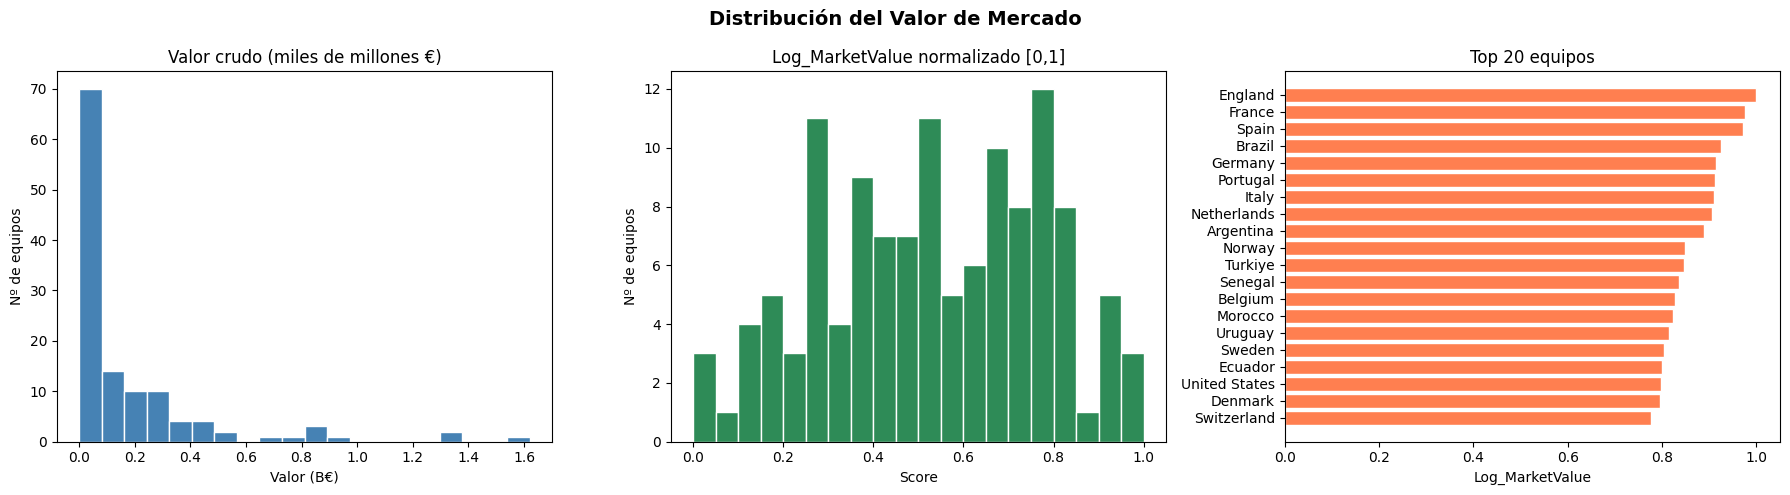

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución del Valor de Mercado', fontsize=14, fontweight='bold')

axes[0].hist(df_rankings['total_market_value'] / 1e9, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Valor crudo (miles de millones €)')
axes[0].set_xlabel('Valor (B€)'); axes[0].set_ylabel('Nº de equipos')

axes[1].hist(df_rankings['Log_MarketValue'], bins=20, color='seagreen', edgecolor='white')
axes[1].set_title('Log_MarketValue normalizado [0,1]')
axes[1].set_xlabel('Score'); axes[1].set_ylabel('Nº de equipos')

top20 = df_rankings.nlargest(20, 'Log_MarketValue')
axes[2].barh(top20['name'], top20['Log_MarketValue'], color='coral', edgecolor='white')
axes[2].invert_yaxis(); axes[2].set_title('Top 20 equipos'); axes[2].set_xlabel('Log_MarketValue')

plt.tight_layout(); plt.show()

In [ ]:
scaler_elo48 = MinMaxScaler()
df_mundial['ELO_norm'] = scaler_elo48.fit_transform(df_mundial[['ELO']])

print(df_mundial[['name','ELO','ELO_norm']].sort_values('ELO_norm', ascending=False).head(20))

           name          ELO  ELO_norm
5         Spain  1980.443257  1.000000
15    Argentina  1951.173485  0.932001
6        France  1907.282364  0.830034
29      Morocco  1873.128810  0.750689
14        Japan  1853.060701  0.704067
3       England  1851.625990  0.700733
4      Portugal  1840.232959  0.674265
16       Brazil  1827.695576  0.645139
2       Germany  1824.344654  0.637354
7   Netherlands  1823.811937  0.636116
39     Colombia  1820.839662  0.629211
22      Senegal  1805.514178  0.593607
25      Croatia  1788.784696  0.554741
13    Australia  1786.962439  0.550508
40      Ecuador  1786.603545  0.549674
41       Mexico  1783.226939  0.541830
32         Iran  1781.237496  0.537208
33  South Korea  1774.135761  0.520709
34      Algeria  1773.875031  0.520103
21      Uruguay  1770.086462  0.511302


## 4. Gráficas — ELO

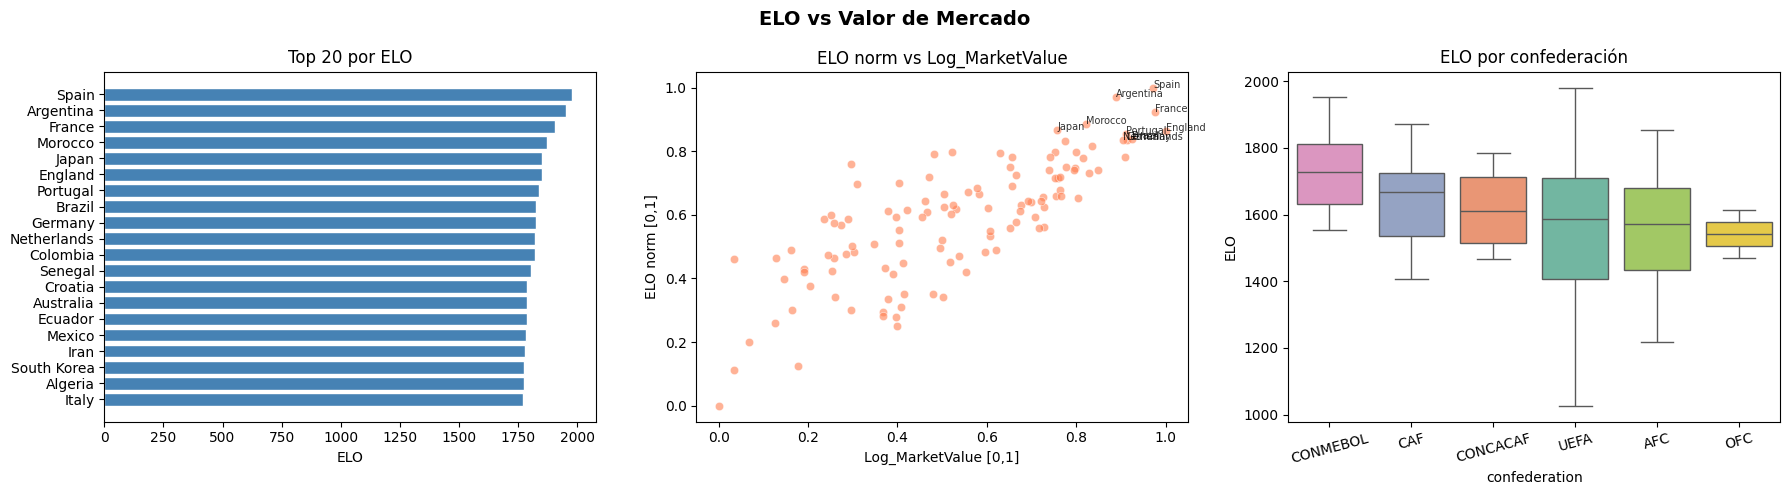

In [ ]:
# Gráfica ELO con todos los equipos desde elo_dict
df_elo_plot = pd.DataFrame(list(elo_dict.items()), columns=['name','ELO'])
df_elo_plot = df_elo_plot.merge(df_rankings[['name','confederation','Log_MarketValue']], on='name', how='inner')
df_elo_plot['ELO_norm'] = MinMaxScaler().fit_transform(df_elo_plot[['ELO']])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ELO vs Valor de Mercado', fontsize=14, fontweight='bold')

top20_elo = df_elo_plot.nlargest(20, 'ELO')
axes[0].barh(top20_elo['name'], top20_elo['ELO'], color='steelblue', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Top 20 por ELO')
axes[0].set_xlabel('ELO')

axes[1].scatter(df_elo_plot['Log_MarketValue'], df_elo_plot['ELO_norm'],
                alpha=0.6, color='coral', edgecolors='white', linewidth=0.5)
for _, row in df_elo_plot.nlargest(10, 'ELO').iterrows():
    axes[1].annotate(row['name'], (row['Log_MarketValue'], row['ELO_norm']), fontsize=7, alpha=0.8)
axes[1].set_title('ELO norm vs Log_MarketValue')
axes[1].set_xlabel('Log_MarketValue [0,1]')
axes[1].set_ylabel('ELO norm [0,1]')

orden = df_elo_plot.groupby('confederation')['ELO'].median().sort_values(ascending=False).index
sns.boxplot(data=df_elo_plot, x='confederation', y='ELO',
            order=orden, ax=axes[2], hue='confederation', palette='Set2', legend=False)
axes[2].set_title('ELO por confederación')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 5. Gráficas — Momentum_15

/tmp/ipykernel_1676/1753801676.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mundial, x='confederation', y='Momentum_15', order=orden, ax=axes[2], palette='Set2')


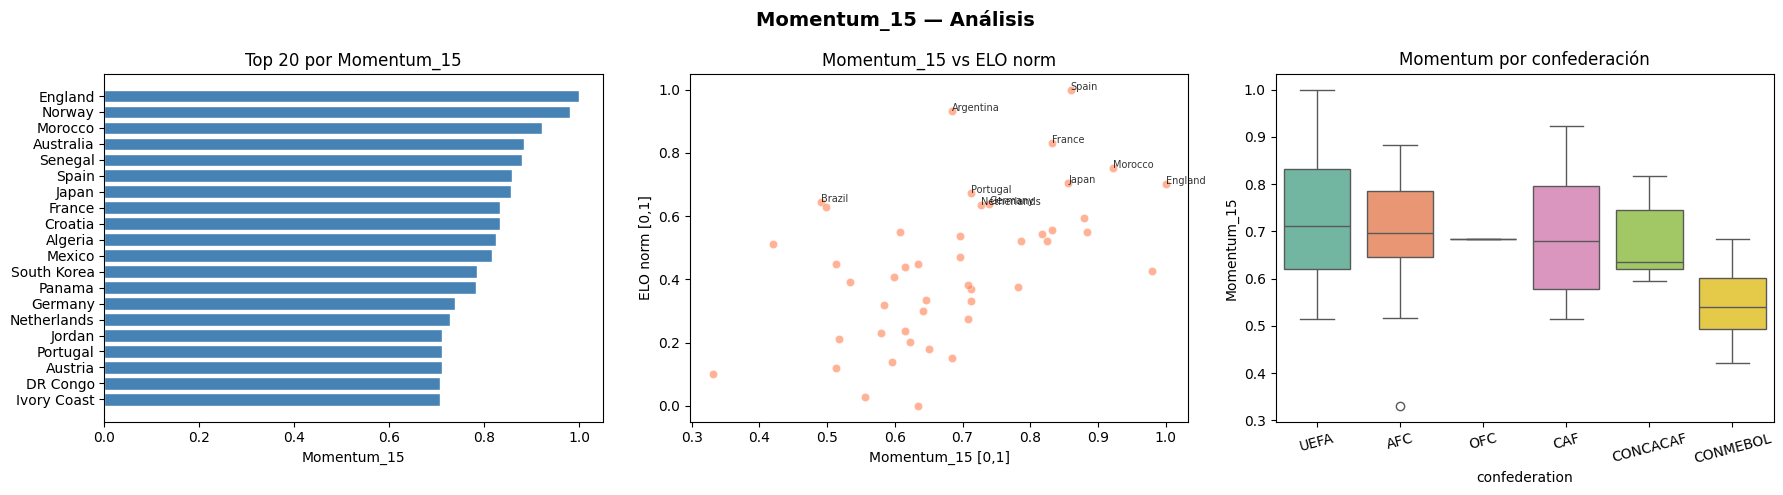

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Momentum_15 — Análisis', fontsize=14, fontweight='bold')

top20_mom = df_mundial.nlargest(20, 'Momentum_15')
axes[0].barh(top20_mom['name'], top20_mom['Momentum_15'], color='steelblue', edgecolor='white')
axes[0].invert_yaxis(); axes[0].set_title('Top 20 por Momentum_15'); axes[0].set_xlabel('Momentum_15')

axes[1].scatter(df_mundial['Momentum_15'], df_mundial['ELO_norm'], alpha=0.6, color='coral', edgecolors='white', linewidth=0.5)
for _, row in df_mundial.nlargest(10, 'ELO_norm').iterrows():
    axes[1].annotate(row['name'], (row['Momentum_15'], row['ELO_norm']), fontsize=7, alpha=0.8)
axes[1].set_title('Momentum_15 vs ELO norm'); axes[1].set_xlabel('Momentum_15 [0,1]'); axes[1].set_ylabel('ELO norm [0,1]')

orden = df_mundial.groupby('confederation')['Momentum_15'].median().sort_values(ascending=False).index
sns.boxplot(data=df_mundial, x='confederation', y='Momentum_15', order=orden, ax=axes[2], palette='Set2')
axes[2].set_title('Momentum por confederación'); axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

In [ ]:
print(df_mundial['Momentum_15'].min(), df_mundial['Momentum_15'].max())
print(df_mundial[['name','Momentum_15']].sort_values('Momentum_15', ascending=False).head(10))

0.33073929961089493 1.0
         name  Momentum_15
3     England     1.000000
17     Norway     0.980545
29    Morocco     0.922179
13  Australia     0.883268
22    Senegal     0.879377
5       Spain     0.859922
14      Japan     0.856031
6      France     0.832685
25    Croatia     0.832685
34    Algeria     0.824903


## 6. Gráficas — Sede

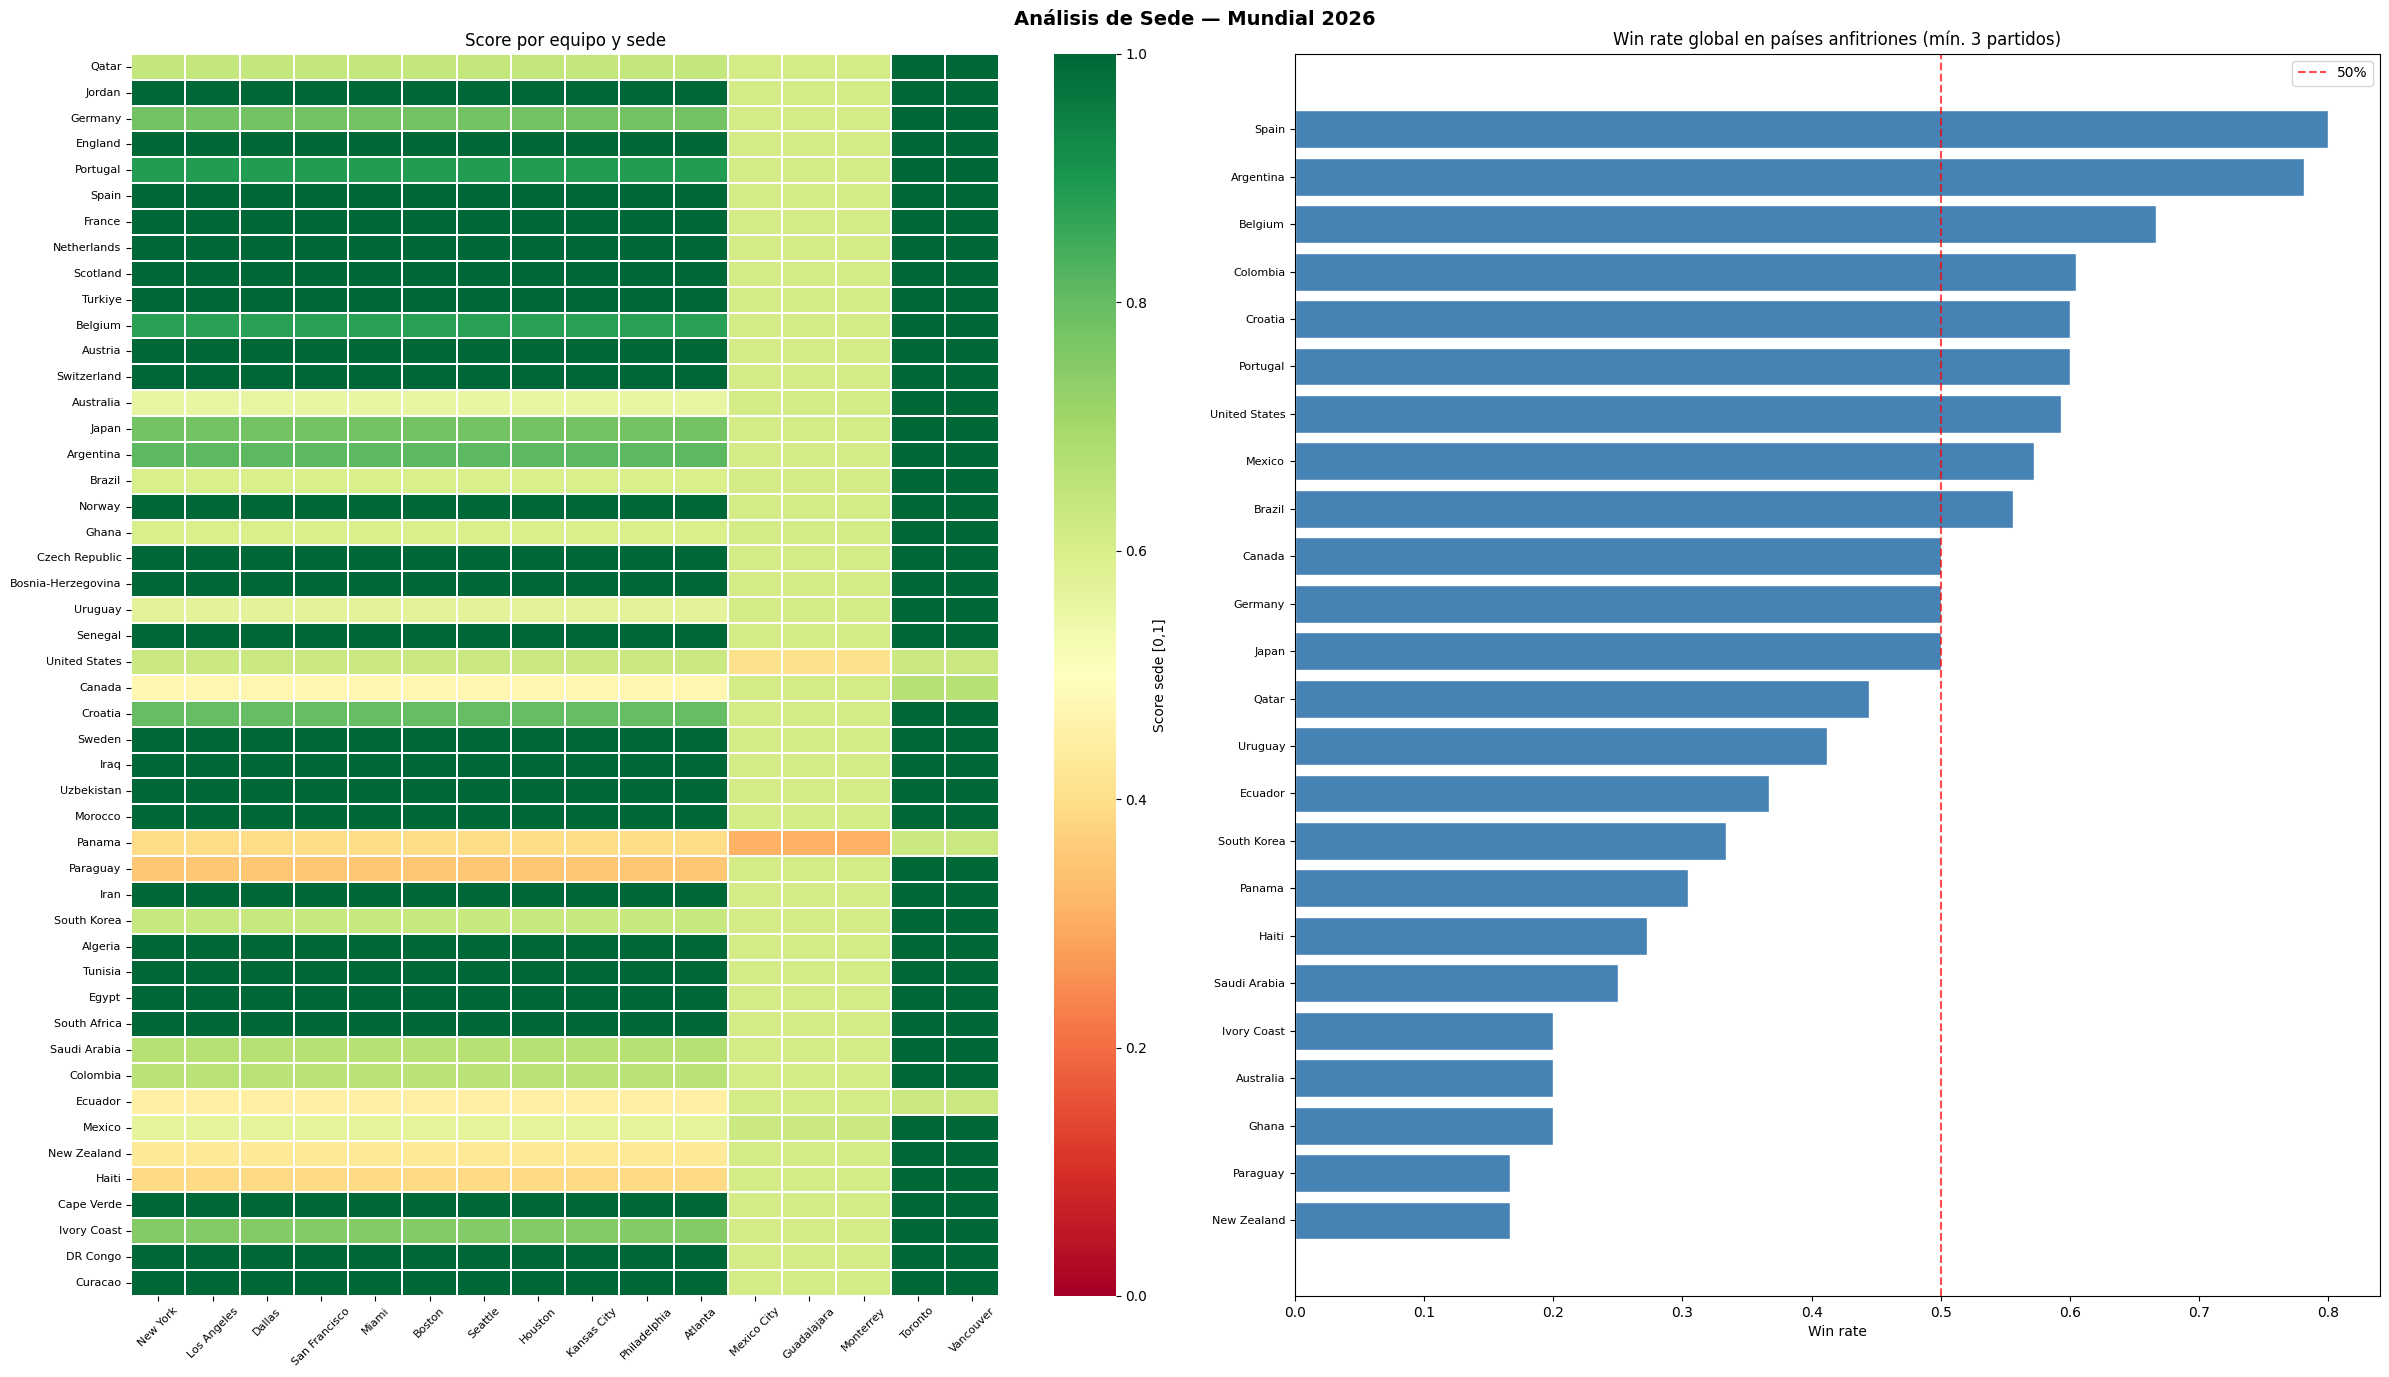

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 14))
fig.suptitle('Análisis de Sede — Mundial 2026', fontsize=14, fontweight='bold')

ciudades = sedes['city'].tolist(); paises = sedes['country'].tolist()
matriz = []
for _, row in df_mundial.iterrows():
    fila = [score_sede(row['name'], paises[i], row['confederation']) for i in range(len(ciudades))]
    matriz.append(fila)
df_matriz = pd.DataFrame(matriz, index=df_mundial['name'].tolist(), columns=ciudades)
sns.heatmap(df_matriz, ax=axes[0], cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.3, linecolor='white', cbar_kws={'label': 'Score sede [0,1]'})
axes[0].set_title('Score por equipo y sede'); axes[0].tick_params(axis='x', rotation=45, labelsize=8); axes[0].tick_params(axis='y', labelsize=8)

equipos_mundial_set = set(df_mundial['name'].tolist())
df_anf_mundial = df_anf_long[df_anf_long['equipo'].isin(equipos_mundial_set)].copy()
df_global = df_anf_mundial.groupby('equipo').apply(
    lambda g: pd.Series({'partidos': len(g), 'win_rate': (g['resultado'] == 'W').mean()}), include_groups=False
).reset_index()
df_global = df_global[df_global['partidos'] >= 3].sort_values('win_rate', ascending=True)
axes[1].barh(df_global['equipo'], df_global['win_rate'], color='steelblue', edgecolor='white')
axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='50%')
axes[1].set_title('Win rate global en países anfitriones (mín. 3 partidos)'); axes[1].set_xlabel('Win rate'); axes[1].tick_params(axis='y', labelsize=8); axes[1].legend()

plt.tight_layout(); plt.show()

## 7. Gráficas — Knockout Performance

/tmp/ipykernel_1676/124396334.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mundial, x='confederation', y='Knockout_Performance', order=orden, ax=axes[2], palette='Set2')


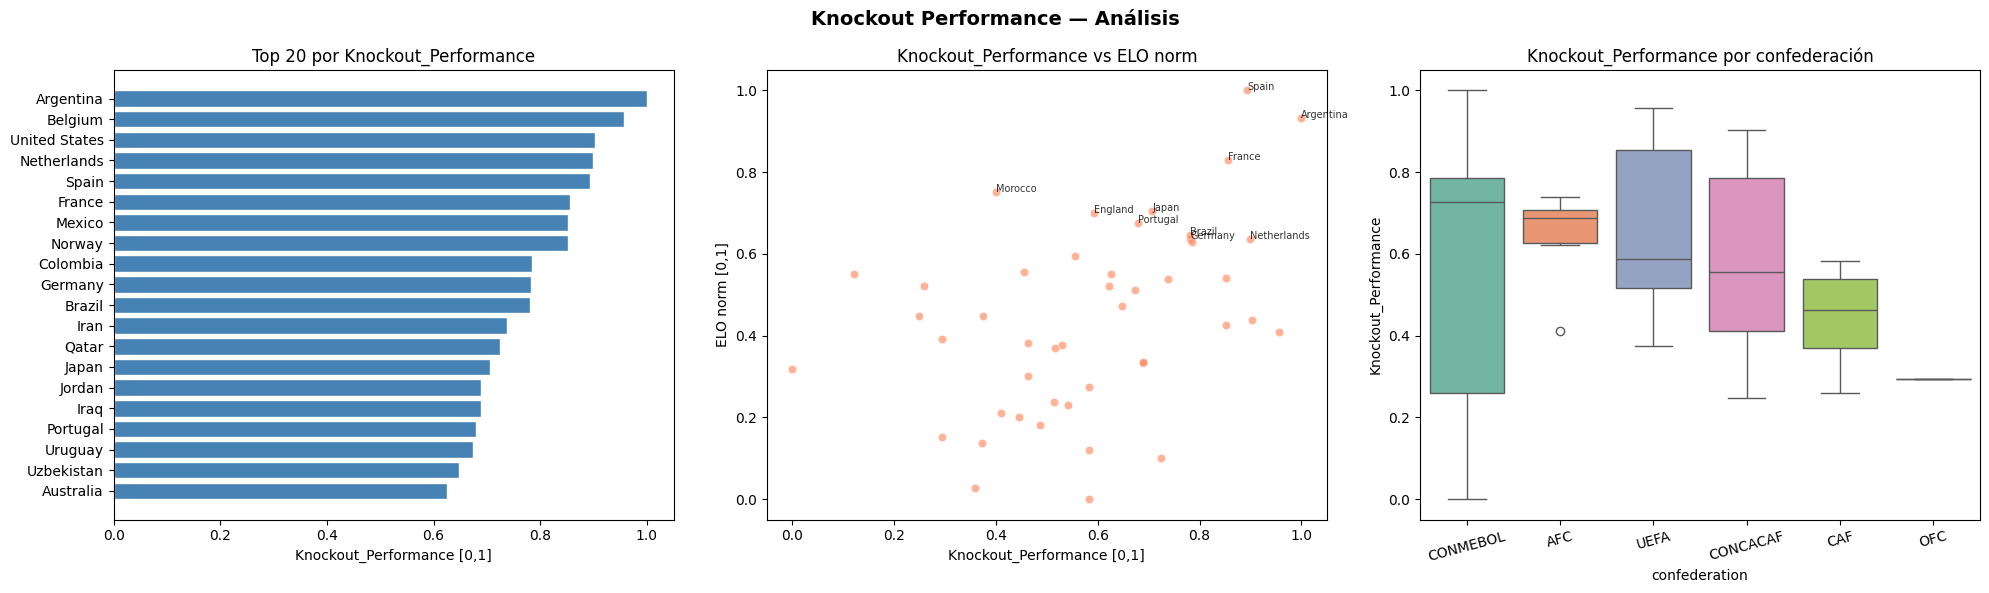

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Knockout Performance — Análisis', fontsize=14, fontweight='bold')

top20_ko = df_mundial.nlargest(20, 'Knockout_Performance')
axes[0].barh(top20_ko['name'], top20_ko['Knockout_Performance'], color='steelblue', edgecolor='white')
axes[0].invert_yaxis(); axes[0].set_title('Top 20 por Knockout_Performance'); axes[0].set_xlabel('Knockout_Performance [0,1]')

axes[1].scatter(df_mundial['Knockout_Performance'], df_mundial['ELO_norm'], alpha=0.6, color='coral', edgecolors='white', linewidth=0.5)
for _, row in df_mundial.nlargest(10, 'ELO_norm').iterrows():
    axes[1].annotate(row['name'], (row['Knockout_Performance'], row['ELO_norm']), fontsize=7, alpha=0.8)
axes[1].set_title('Knockout_Performance vs ELO norm'); axes[1].set_xlabel('Knockout_Performance [0,1]'); axes[1].set_ylabel('ELO norm [0,1]')

orden = df_mundial.groupby('confederation')['Knockout_Performance'].median().sort_values(ascending=False).index
sns.boxplot(data=df_mundial, x='confederation', y='Knockout_Performance', order=orden, ax=axes[2], palette='Set2')
axes[2].set_title('Knockout_Performance por confederación'); axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

## 8. Gráficas — Pressure Index

/tmp/ipykernel_1676/4284491308.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mundial, x='confederation', y='Pressure_Index', order=orden, ax=axes[2], palette='Set2')


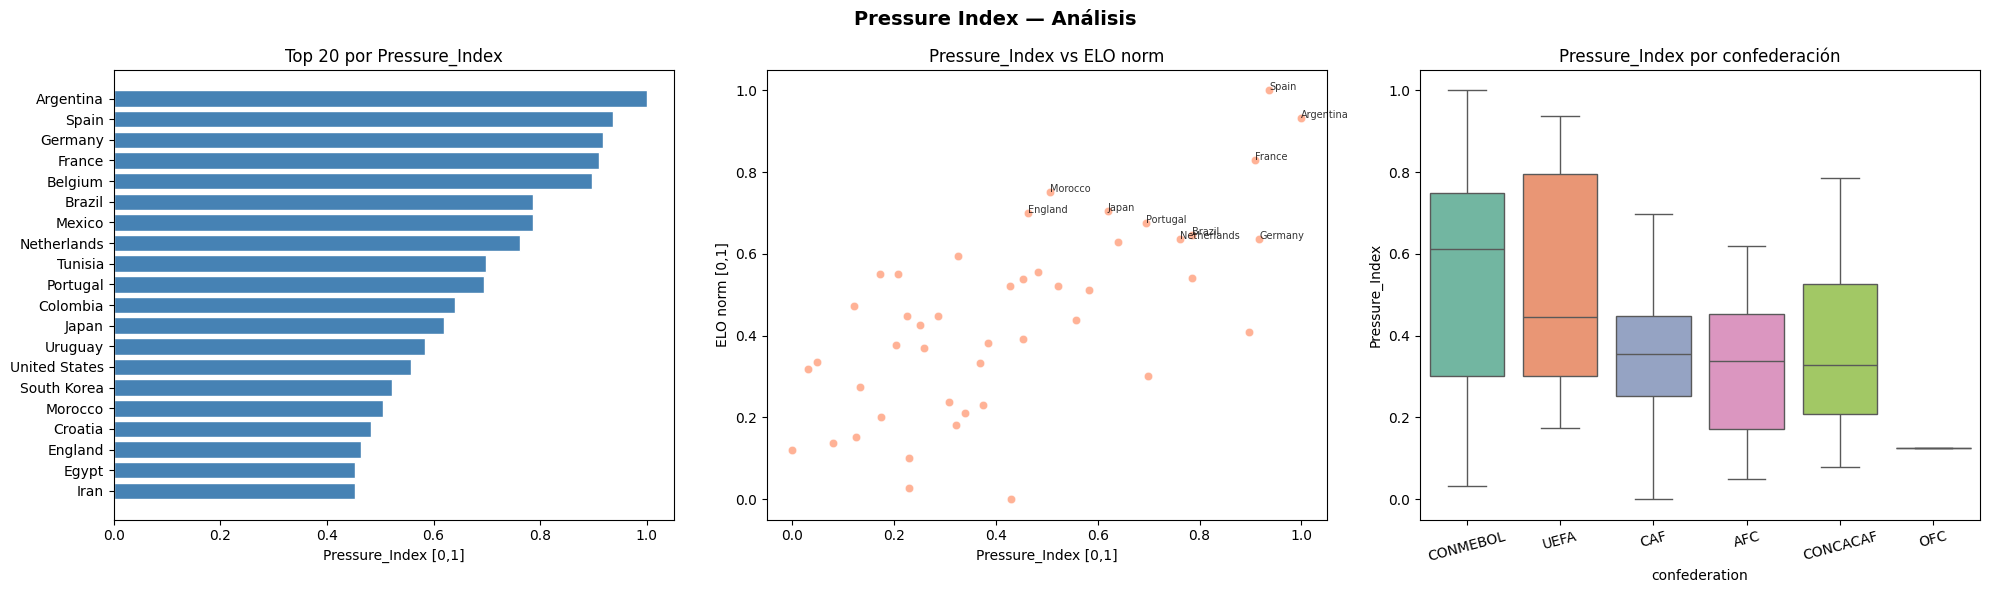

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Pressure Index — Análisis', fontsize=14, fontweight='bold')

top20_press = df_mundial.nlargest(20, 'Pressure_Index')
axes[0].barh(top20_press['name'], top20_press['Pressure_Index'], color='steelblue', edgecolor='white')
axes[0].invert_yaxis(); axes[0].set_title('Top 20 por Pressure_Index'); axes[0].set_xlabel('Pressure_Index [0,1]')

axes[1].scatter(df_mundial['Pressure_Index'], df_mundial['ELO_norm'], alpha=0.6, color='coral', edgecolors='white', linewidth=0.5)
for _, row in df_mundial.nlargest(10, 'ELO_norm').iterrows():
    axes[1].annotate(row['name'], (row['Pressure_Index'], row['ELO_norm']), fontsize=7, alpha=0.8)
axes[1].set_title('Pressure_Index vs ELO norm'); axes[1].set_xlabel('Pressure_Index [0,1]'); axes[1].set_ylabel('ELO norm [0,1]')

orden = df_mundial.groupby('confederation')['Pressure_Index'].median().sort_values(ascending=False).index
sns.boxplot(data=df_mundial, x='confederation', y='Pressure_Index', order=orden, ax=axes[2], palette='Set2')
axes[2].set_title('Pressure_Index por confederación'); axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

## 9. Correlación entre Features

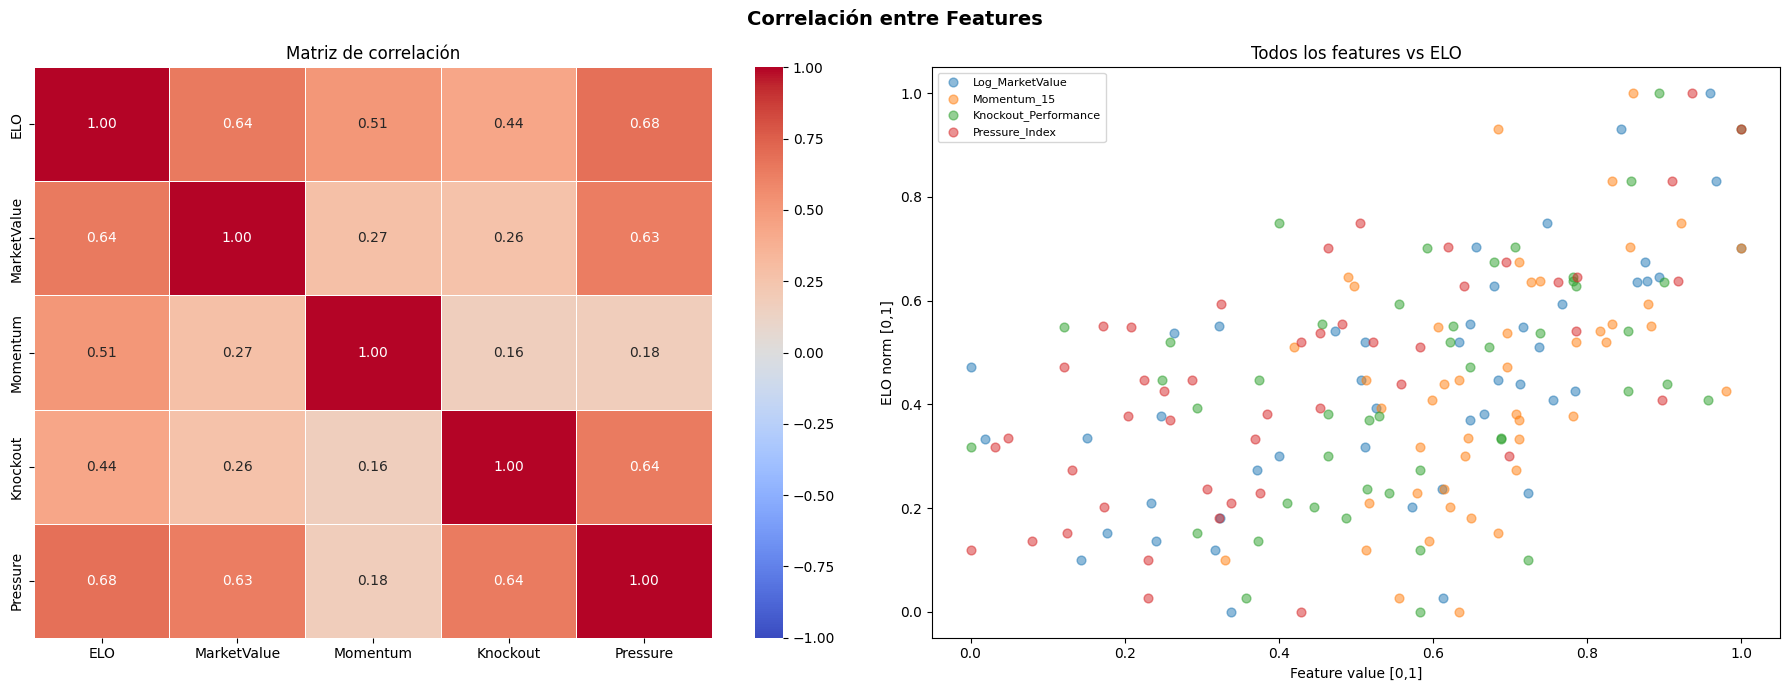

In [ ]:
features_cols = ['ELO_norm','Log_MarketValue','Momentum_15','Knockout_Performance','Pressure_Index']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Correlación entre Features', fontsize=14, fontweight='bold')

corr = df_mundial[features_cols].corr()
sns.heatmap(corr, ax=axes[0], annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5,
            xticklabels=['ELO','MarketValue','Momentum','Knockout','Pressure'],
            yticklabels=['ELO','MarketValue','Momentum','Knockout','Pressure'])
axes[0].set_title('Matriz de correlación')

for feat in ['Log_MarketValue','Momentum_15','Knockout_Performance','Pressure_Index']:
    axes[1].scatter(df_mundial[feat], df_mundial['ELO_norm'], alpha=0.5, label=feat, s=40)
axes[1].set_title('Todos los features vs ELO'); axes[1].set_xlabel('Feature value [0,1]'); axes[1].set_ylabel('ELO norm [0,1]'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 10. Históricos

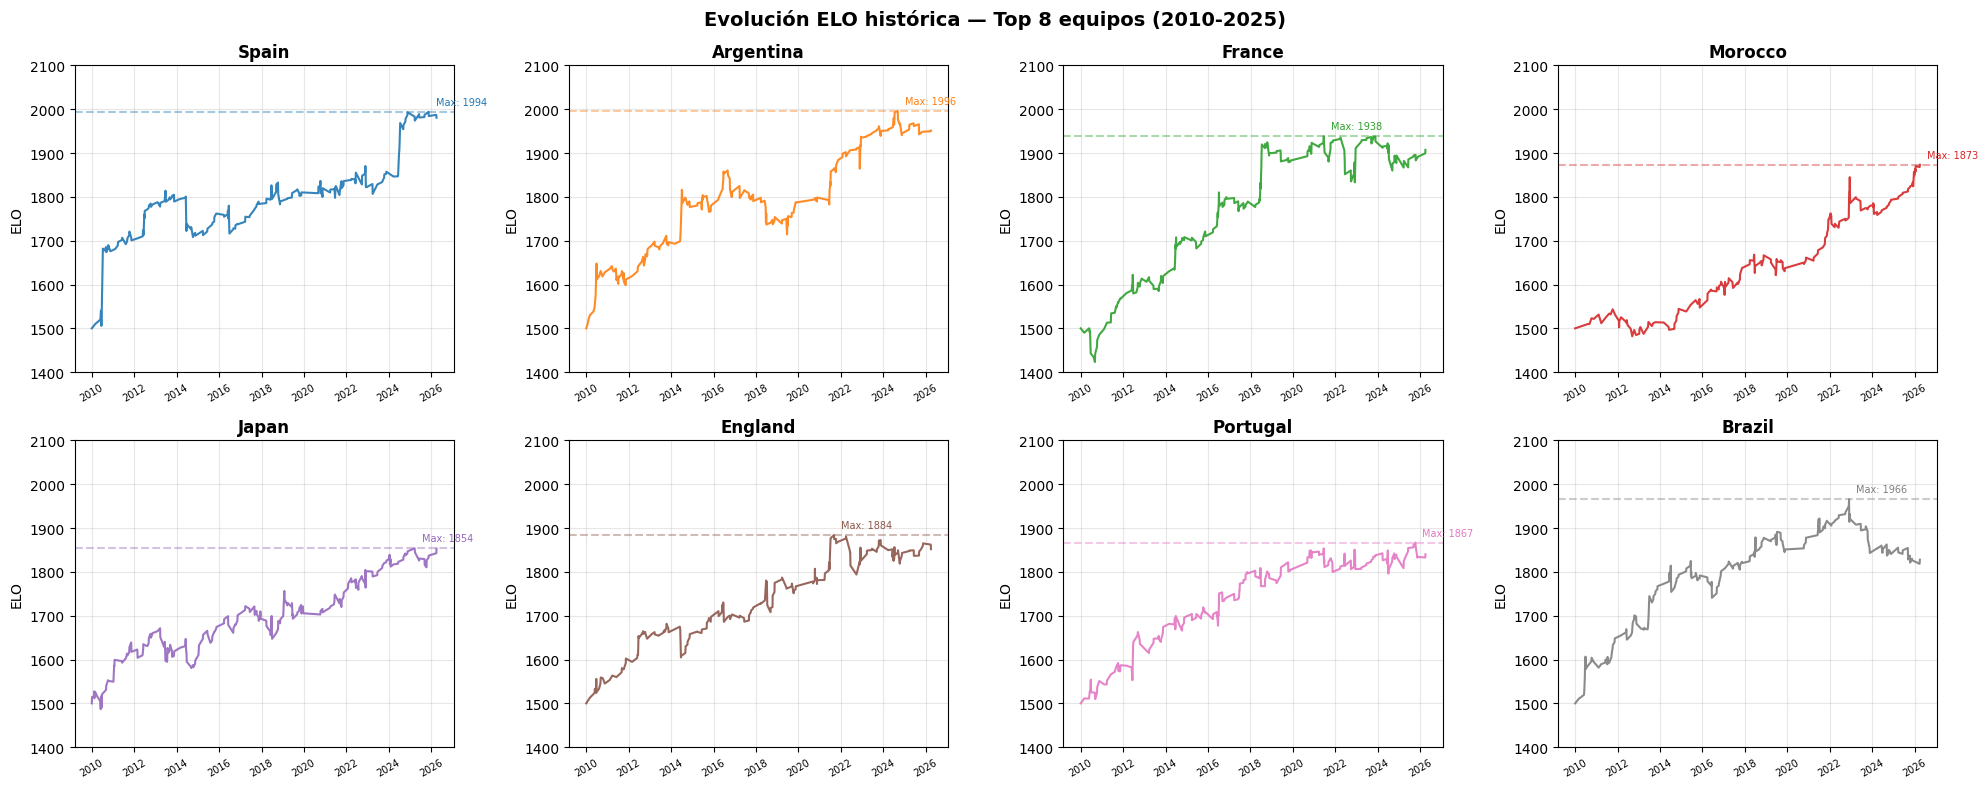

In [ ]:
# ELO histórico — reconstrucción
top8 = df_mundial.nlargest(8, 'ELO')['name'].tolist()
elo_historico = {eq: [1500] for eq in top8}
fechas_historico = {eq: [pd.Timestamp('2010-01-01')] for eq in top8}
elo_running = {eq: 1500 for eq in equipos}

for _, row in df_recent_matches.sort_values('date').iterrows():
    home, away = row['home_team'], row['away_team']
    if home not in elo_running or away not in elo_running: continue
    elo_h, elo_a = elo_running[home], elo_running[away]
    k = get_k(row['tournament'])
    exp_h, exp_a = expected(elo_h, elo_a), expected(elo_a, elo_h)
    if row['home_score'] > row['away_score']:   res_h, res_a = 1, 0
    elif row['home_score'] < row['away_score']: res_h, res_a = 0, 1
    else:                                        res_h, res_a = 0.5, 0.5
    elo_running[home] = elo_h + k * (res_h - exp_h)
    elo_running[away] = elo_a + k * (res_a - exp_a)
    if home in top8:
        elo_historico[home].append(elo_running[home])
        fechas_historico[home].append(row['date'])
    if away in top8:
        elo_historico[away].append(elo_running[away])
        fechas_historico[away].append(row['date'])

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Evolución ELO histórica — Top 8 equipos (2010-2025)', fontsize=14, fontweight='bold')
axes = axes.flatten()
colores_line = plt.cm.tab10.colors

for i, eq in enumerate(top8):
    axes[i].plot(fechas_historico[eq], elo_historico[eq], linewidth=1.5, color=colores_line[i], alpha=0.9)
    axes[i].set_title(eq, fontweight='bold'); axes[i].set_ylabel('ELO'); axes[i].set_ylim(1400, 2100)
    axes[i].grid(alpha=0.3); axes[i].tick_params(axis='x', rotation=30, labelsize=7)
    max_elo = max(elo_historico[eq])
    max_fecha = fechas_historico[eq][elo_historico[eq].index(max_elo)]
    axes[i].axhline(y=max_elo, color=colores_line[i], linestyle='--', alpha=0.4)
    axes[i].annotate(f'Max: {max_elo:.0f}', xy=(max_fecha, max_elo), fontsize=7, color=colores_line[i], xytext=(5,5), textcoords='offset points')

plt.tight_layout(); plt.show()

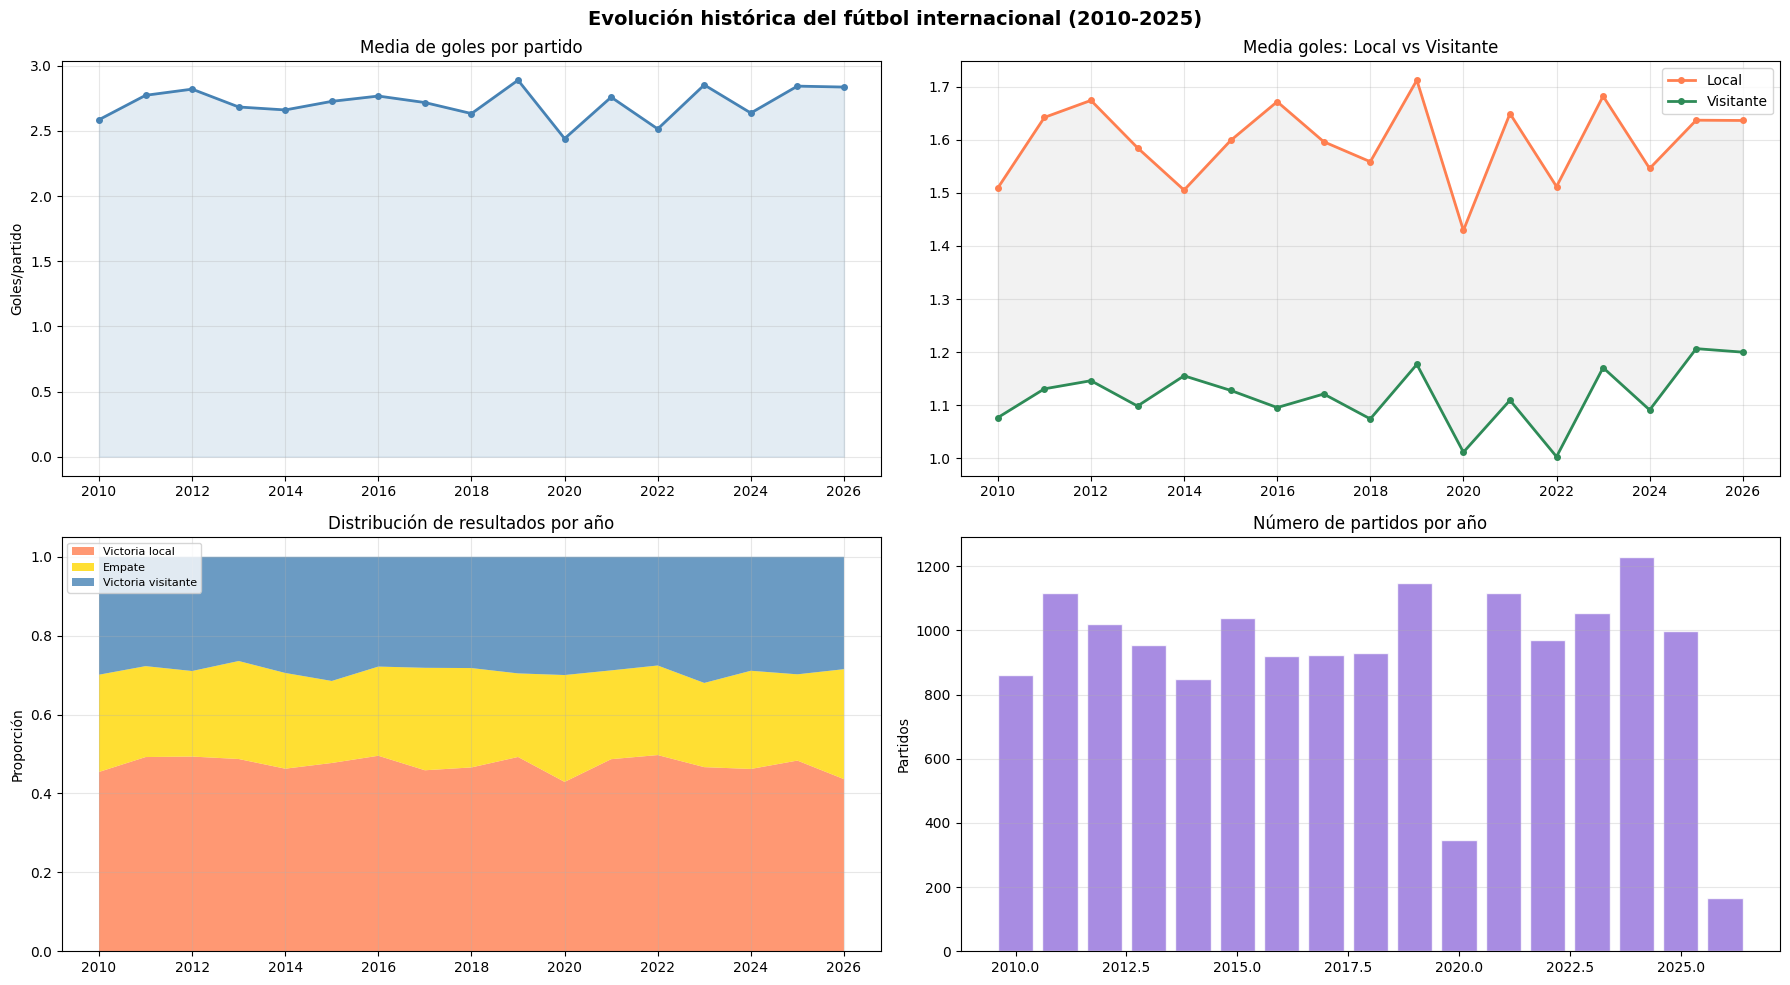

In [ ]:
# Histórico de goles general
df_goles = df_recent_matches.copy()
df_goles['year'] = df_goles['date'].dt.year
df_goles['total_goles'] = df_goles['home_score'] + df_goles['away_score']
df_goles['empate'] = (df_goles['home_score'] == df_goles['away_score']).astype(int)
df_goles['victoria_local'] = (df_goles['home_score'] > df_goles['away_score']).astype(int)
df_goles['victoria_visitante'] = (df_goles['away_score'] > df_goles['home_score']).astype(int)

df_anual = df_goles.groupby('year').agg(
    partidos=('total_goles','count'), goles_totales=('total_goles','sum'),
    media_goles=('total_goles','mean'), media_goles_local=('home_score','mean'),
    media_goles_visitante=('away_score','mean'), pct_empates=('empate','mean'),
    pct_victoria_local=('victoria_local','mean'), pct_victoria_visitante=('victoria_visitante','mean'),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Evolución histórica del fútbol internacional (2010-2025)', fontsize=14, fontweight='bold')

axes[0,0].plot(df_anual['year'], df_anual['media_goles'], color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0,0].fill_between(df_anual['year'], df_anual['media_goles'], alpha=0.15, color='steelblue')
axes[0,0].set_title('Media de goles por partido'); axes[0,0].set_ylabel('Goles/partido'); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(df_anual['year'], df_anual['media_goles_local'], color='coral', linewidth=2, marker='o', markersize=4, label='Local')
axes[0,1].plot(df_anual['year'], df_anual['media_goles_visitante'], color='seagreen', linewidth=2, marker='o', markersize=4, label='Visitante')
axes[0,1].fill_between(df_anual['year'], df_anual['media_goles_local'], df_anual['media_goles_visitante'], alpha=0.1, color='gray')
axes[0,1].set_title('Media goles: Local vs Visitante'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].stackplot(df_anual['year'], df_anual['pct_victoria_local'], df_anual['pct_empates'], df_anual['pct_victoria_visitante'],
                    labels=['Victoria local','Empate','Victoria visitante'], colors=['coral','gold','steelblue'], alpha=0.8)
axes[1,0].set_title('Distribución de resultados por año'); axes[1,0].set_ylabel('Proporción'); axes[1,0].legend(loc='upper left', fontsize=8); axes[1,0].grid(alpha=0.3)

axes[1,1].bar(df_anual['year'], df_anual['partidos'], color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Número de partidos por año'); axes[1,1].set_ylabel('Partidos'); axes[1,1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

# **Entrenamiento del modelo**

In [ ]:
# --- DATASET DE ENTRENAMIENTO ---

# Partidos donde al menos uno de los dos equipos está entre los 48 clasificados
clasificados_set = set(df_mundial['name'].tolist())

df_train_raw = df_recent_matches[
    (df_recent_matches['home_team'].isin(clasificados_set)) |
    (df_recent_matches['away_team'].isin(clasificados_set))
].copy()

print(f'Partidos totales desde 2010: {len(df_recent_matches)}')
print(f'Partidos con al menos un clasificado: {len(df_train_raw)}')
print(df_train_raw['tournament'].value_counts().head(10))

Partidos totales desde 2010: 15632
Partidos con al menos un clasificado: 6967
tournament
Friendly                                2405
FIFA World Cup qualification            1767
UEFA Euro qualification                  447
African Cup of Nations qualification     404
UEFA Nations League                      264
African Cup of Nations                   251
FIFA World Cup                           245
Gold Cup                                 155
UEFA Euro                                153
Copa América                             152
Name: count, dtype: int64


In [ ]:
# Creamos un diccionario de features por equipo para lookup rápido
features_cols = ['ELO', 'ELO_norm', 'Log_MarketValue', 'Momentum_15',
                 'Knockout_Performance', 'Pressure_Index']

# Incluimos todos los equipos — los 48 clasificados + el resto desde df_rankings
df_features_all = df_rankings[['name','confederation']].copy()
df_features_all['ELO'] = df_features_all['name'].apply(lambda n: elo_dict.get(n, np.nan))

# Normalizamos ELO para todos
df_features_all['ELO_norm'] = MinMaxScaler().fit_transform(df_features_all[['ELO']])

# Log_MarketValue para todos
df_features_all = df_features_all.merge(
    df_rankings[['name','total_market_value']], on='name', how='left'
)
df_features_all['log_mv'] = np.log1p(df_features_all['total_market_value'])
df_features_all['Log_MarketValue'] = MinMaxScaler().fit_transform(df_features_all[['log_mv']])

# Momentum, Knockout, Pressure — mergeamos desde df_mundial para los 48
# Para el resto usamos la media global
df_features_all = df_features_all.merge(
    df_mundial[['name','Momentum_15','Knockout_Performance','Pressure_Index']],
    on='name', how='left'
)
df_features_all['Momentum_15'] = df_features_all['Momentum_15'].fillna(df_features_all['Momentum_15'].mean())
df_features_all['Knockout_Performance'] = df_features_all['Knockout_Performance'].fillna(df_features_all['Knockout_Performance'].mean())
df_features_all['Pressure_Index'] = df_features_all['Pressure_Index'].fillna(df_features_all['Pressure_Index'].mean())

# Diccionario para lookup rápido
features_dict = df_features_all.set_index('name')[
    ['ELO_norm','Log_MarketValue','Momentum_15','Knockout_Performance','Pressure_Index']
].to_dict('index')

print(f'Equipos en features_dict: {len(features_dict)}')
print('Ejemplo España:', features_dict.get('Spain'))

Equipos en features_dict: 123
Ejemplo España: {'ELO_norm': 0.9999999999999998, 'Log_MarketValue': 0.9715183144153923, 'Momentum_15': 0.8599221789883266, 'Knockout_Performance': 0.8935875659933278, 'Pressure_Index': 0.936413912819168}


In [ ]:
# --- CONSTRUCCIÓN DEL DATASET ---

def get_features(equipo):
    if equipo in features_dict:
        return features_dict[equipo]
    return {k: np.nan for k in ['ELO_norm','Log_MarketValue','Momentum_15','Knockout_Performance','Pressure_Index']}

filas = []
for _, row in df_train_raw.iterrows():
    home, away = row['home_team'], row['away_team']
    fh = get_features(home)
    fa = get_features(away)

    # Resultado: 1=victoria local, 0=empate, -1=derrota local
    if row['home_score'] > row['away_score']:   resultado = 1
    elif row['home_score'] == row['away_score']: resultado = 0
    else:                                        resultado = -1

    fila = {
        'home_team': home,
        'away_team': away,
        'tournament': row['tournament'],
        'date': row['date'],
        # Diferencias de features (home - away)
        'diff_ELO':      fh['ELO_norm']            - fa['ELO_norm'],
        'diff_MV':       fh['Log_MarketValue']      - fa['Log_MarketValue'],
        'diff_Momentum': fh['Momentum_15']          - fa['Momentum_15'],
        'diff_Knockout': fh['Knockout_Performance'] - fa['Knockout_Performance'],
        'diff_Pressure': fh['Pressure_Index']       - fa['Pressure_Index'],
        # Target
        'resultado': resultado
    }
    filas.append(fila)

df_train = pd.DataFrame(filas).dropna()

print(f'Shape: {df_train.shape}')
print(f'Distribución resultados:\n{df_train["resultado"].value_counts()}')

Shape: (5011, 10)
Distribución resultados:
resultado
 1    2366
-1    1470
 0    1175
Name: count, dtype: int64


In [ ]:
# Filtramos amistosos del dataset de entrenamiento
df_train_oficial = df_train[df_train['tournament'] != 'Friendly'].copy()

print(f'Partidos totales: {len(df_train)}')
print(f'Partidos sin amistosos: {len(df_train_oficial)}')
print(f'Distribución resultados:\n{df_train_oficial["resultado"].value_counts()}')

Partidos totales: 5011
Partidos sin amistosos: 3149
Distribución resultados:
resultado
 1    1466
-1     972
 0     711
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# --- PREPARACIÓN X e y ---

feature_cols = ['diff_ELO','diff_MV','diff_Momentum','diff_Knockout','diff_Pressure']

X = df_train[feature_cols].values
y = df_train['resultado'].map({1: 2, 0: 1, -1: 0}).values  # XGBoost necesita clases 0,1,2

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Distribución train: {pd.Series(y_train).value_counts().to_dict()}')

Train: (3507, 5), Test: (1504, 5)
Distribución train: {2: 1656, 0: 1029, 1: 822}


[0]	validation_0-mlogloss:1.08757
[50]	validation_0-mlogloss:0.94626
[100]	validation_0-mlogloss:0.94722
[150]	validation_0-mlogloss:0.95114
[200]	validation_0-mlogloss:0.95645
[250]	validation_0-mlogloss:0.96109
[299]	validation_0-mlogloss:0.96475


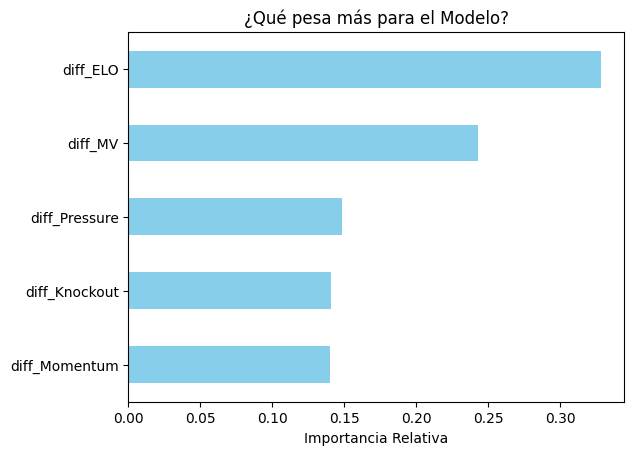

              precision    recall  f1-score   support

     Derrota       0.52      0.61      0.56       441
      Empate       0.29      0.35      0.32       353
    Victoria       0.70      0.55      0.61       710

    accuracy                           0.52      1504
   macro avg       0.50      0.50      0.50      1504
weighted avg       0.55      0.52      0.53      1504



In [ ]:
# --- ENTRENAMIENTO XGBoost ---

from sklearn.utils.class_weight import compute_sample_weight

# Calculamos pesos para balancear las 3 clases
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Reentrenamos con pesos
modelo_bal = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

modelo_bal.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=50
)
# Visualización de la Importancia de las Variables
import matplotlib.pyplot as plt

importancia = pd.Series(modelo_bal.feature_importances_, index=feature_cols)
importancia.sort_values().plot(kind='barh', color='skyblue')
plt.title('¿Qué pesa más para el Modelo?')
plt.xlabel('Importancia Relativa')
plt.show()
# Evaluación
y_pred = modelo_bal.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Derrota','Empate','Victoria']))

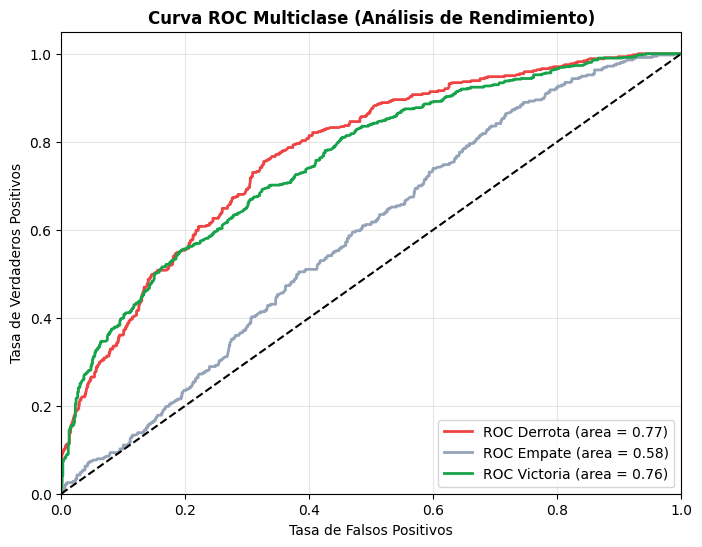

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Binarizamos las etiquetas para el cálculo multiclase
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# 2. Obtenemos las probabilidades (no las predicciones directas)
y_score = modelo_bal.predict_proba(X_test)

# 3. Calculamos ROC y AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
target_names = ['Derrota', 'Empate', 'Victoria']
colors = ['#ef4444', '#94a3b8', '#16a34a'] # Rojo, Gris, Verde

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC {target_names[i]} (area = {roc_auc[i]:.2f})')

# 4. Estética de la gráfica
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC Multiclase (Análisis de Rendimiento)', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('curva_roc_multiclase.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Espacio de búsqueda
param_grid = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3],
}

modelo_search = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42
)

search = RandomizedSearchCV(
    modelo_search,
    param_distributions=param_grid,
    n_iter=30,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train, sample_weight=sample_weights)

print('Mejores parámetros:', search.best_params_)
print('Mejor f1_macro CV:', round(search.best_score_, 4))

# Evaluamos en test
y_pred_tuned = search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_tuned, target_names=['Derrota','Empate','Victoria']))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Mejores parámetros: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.9}
Mejor f1_macro CV: 0.508
              precision    recall  f1-score   support

     Derrota       0.52      0.65      0.58       441
      Empate       0.26      0.31      0.29       353
    Victoria       0.72      0.55      0.62       710

    accuracy                           0.52      1504
   macro avg       0.50      0.50      0.49      1504
weighted avg       0.55      0.52      0.53      1504



In [ ]:
import pickle

# Guardamos el modelo ganador
with open('/content/modelo_bal.pkl', 'wb') as f:
    pickle.dump(modelo_bal, f)

df_train.to_csv('/content/df_train.csv', index=False)
df_mundial.to_csv('/content/df_mundial.csv', index=False)

with open('/content/features_dict.pkl', 'wb') as f:
    pickle.dump(features_dict, f)

with open('/content/elo_dict.pkl', 'wb') as f:
    pickle.dump(elo_dict, f)

print('Todo guardado OK')

Todo guardado OK


In [ ]:
grupos = {
    'A': ['Mexico', 'South Africa', 'South Korea', 'Czech Republic'],
    'B': ['Canada', 'Bosnia-Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['United States', 'Paraguay', 'Australia', 'Turkiye'],
    'E': ['Germany', 'Curacao', 'Ivory Coast', 'Ecuador'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Senegal', 'Iraq', 'Norway'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama'],
}

# Verificamos que todos los equipos están en df_mundial
for grupo, equipos in grupos.items():
    faltantes = [e for e in equipos if e not in df_mundial['name'].values]
    if faltantes:
        print(f'Grupo {grupo} — FALTANTES: {faltantes}')

print('Verificación completada')

Verificación completada


In [ ]:
import random

# --- SIMULADOR DE PARTIDO ---
def simular_partido(equipo_a, equipo_b, modelo, features_dict):
    fa = features_dict.get(equipo_a, {k: 0.5 for k in feature_cols})
    fb = features_dict.get(equipo_b, {k: 0.5 for k in feature_cols})

    X = np.array([[
        fa['ELO_norm']            - fb['ELO_norm'],
        fa['Log_MarketValue']     - fb['Log_MarketValue'],
        fa['Momentum_15']         - fb['Momentum_15'],
        fa['Knockout_Performance']- fb['Knockout_Performance'],
        fa['Pressure_Index']      - fb['Pressure_Index'],
    ]])

    # Probabilidades: [P(derrota A), P(empate), P(victoria A)]
    probs = modelo.predict_proba(X)[0]
    p_derrota, p_empate, p_victoria = probs[0], probs[1], probs[2]

    # Sorteamos resultado
    r = random.random()
    if r < p_victoria:
        return equipo_a, equipo_b, 3, 0  # victoria A
    elif r < p_victoria + p_empate:
        return equipo_a, equipo_b, 1, 1  # empate
    else:
        return equipo_a, equipo_b, 0, 3  # derrota A

# --- SIMULADOR DE GRUPO ---
def simular_grupo(equipos, modelo, features_dict):
    puntos = {e: 0 for e in equipos}
    partidos = [(equipos[i], equipos[j])
                for i in range(len(equipos))
                for j in range(i+1, len(equipos))]

    for home, away in partidos:
        _, _, pts_h, pts_a = simular_partido(home, away, modelo, features_dict)
        puntos[home] += pts_h
        puntos[away] += pts_a

    # Ordenamos por puntos
    clasificacion = sorted(puntos.items(), key=lambda x: x[1], reverse=True)
    return clasificacion

# --- MCTS: simulamos N veces cada grupo ---
def mcts_grupo(equipos, modelo, features_dict, n_simulaciones=10000):
    conteo_clasificacion = {e: 0 for e in equipos}

    for _ in range(n_simulaciones):
        clasificacion = simular_grupo(equipos, modelo, features_dict)
        # Los 2 primeros clasifican
        conteo_clasificacion[clasificacion[0][0]] += 1
        conteo_clasificacion[clasificacion[1][0]] += 1

    # Convertimos a porcentajes
    probabilidades = {e: round(conteo_clasificacion[e] / n_simulaciones * 100, 1)
                      for e in equipos}
    return dict(sorted(probabilidades.items(), key=lambda x: x[1], reverse=True))

# Test con Grupo A
print('Simulando Grupo A...')
resultado_A = mcts_grupo(grupos['A'], modelo_bal, features_dict)
print('Grupo A — % clasificación:')
for equipo, pct in resultado_A.items():
    print(f'  {equipo}: {pct}%')

Simulando Grupo A...
Grupo A — % clasificación:
  Mexico: 73.8%
  South Korea: 60.3%
  Czech Republic: 34.1%
  South Africa: 31.8%


In [ ]:
# --- PROBABILIDADES DE CADA PARTIDO ---
def prob_partido(equipo_a, equipo_b, modelo, features_dict):
    fa = features_dict.get(equipo_a, {k: 0.5 for k in feature_cols})
    fb = features_dict.get(equipo_b, {k: 0.5 for k in feature_cols})

    X = np.array([[
        fa['ELO_norm']             - fb['ELO_norm'],
        fa['Log_MarketValue']      - fb['Log_MarketValue'],
        fa['Momentum_15']          - fb['Momentum_15'],
        fa['Knockout_Performance'] - fb['Knockout_Performance'],
        fa['Pressure_Index']       - fb['Pressure_Index'],
    ]])

    probs = modelo.predict_proba(X)[0]
    return {
        'victoria_A': round(probs[2] * 100, 1),
        'empate':     round(probs[1] * 100, 1),
        'victoria_B': round(probs[0] * 100, 1),
    }

# Partidos del Grupo A
equipos_A = grupos['A']
partidos_A = [(equipos_A[i], equipos_A[j])
              for i in range(len(equipos_A))
              for j in range(i+1, len(equipos_A))]

print('=== GRUPO A — Probabilidades por partido ===\n')
df_partidos_A = []
for home, away in partidos_A:
    probs = prob_partido(home, away, modelo_bal, features_dict)
    print(f'{home} vs {away}')
    print(f'  {home}: {probs["victoria_A"]}% | Empate: {probs["empate"]}% | {away}: {probs["victoria_B"]}%\n')
    df_partidos_A.append({'home': home, 'away': away, **probs})

df_partidos_A = pd.DataFrame(df_partidos_A)

=== GRUPO A — Probabilidades por partido ===

Mexico vs South Africa
  Mexico: 48.599998474121094% | Empate: 39.099998474121094% | South Africa: 12.300000190734863%

Mexico vs South Korea
  Mexico: 30.799999237060547% | Empate: 41.70000076293945% | South Korea: 27.5%

Mexico vs Czech Republic
  Mexico: 41.599998474121094% | Empate: 36.29999923706055% | Czech Republic: 22.100000381469727%

South Africa vs South Korea
  South Africa: 16.899999618530273% | Empate: 41.900001525878906% | South Korea: 41.29999923706055%

South Africa vs Czech Republic
  South Africa: 25.399999618530273% | Empate: 35.5% | Czech Republic: 39.099998474121094%

South Korea vs Czech Republic
  South Korea: 42.099998474121094% | Empate: 40.900001525878906% | Czech Republic: 17.100000381469727%



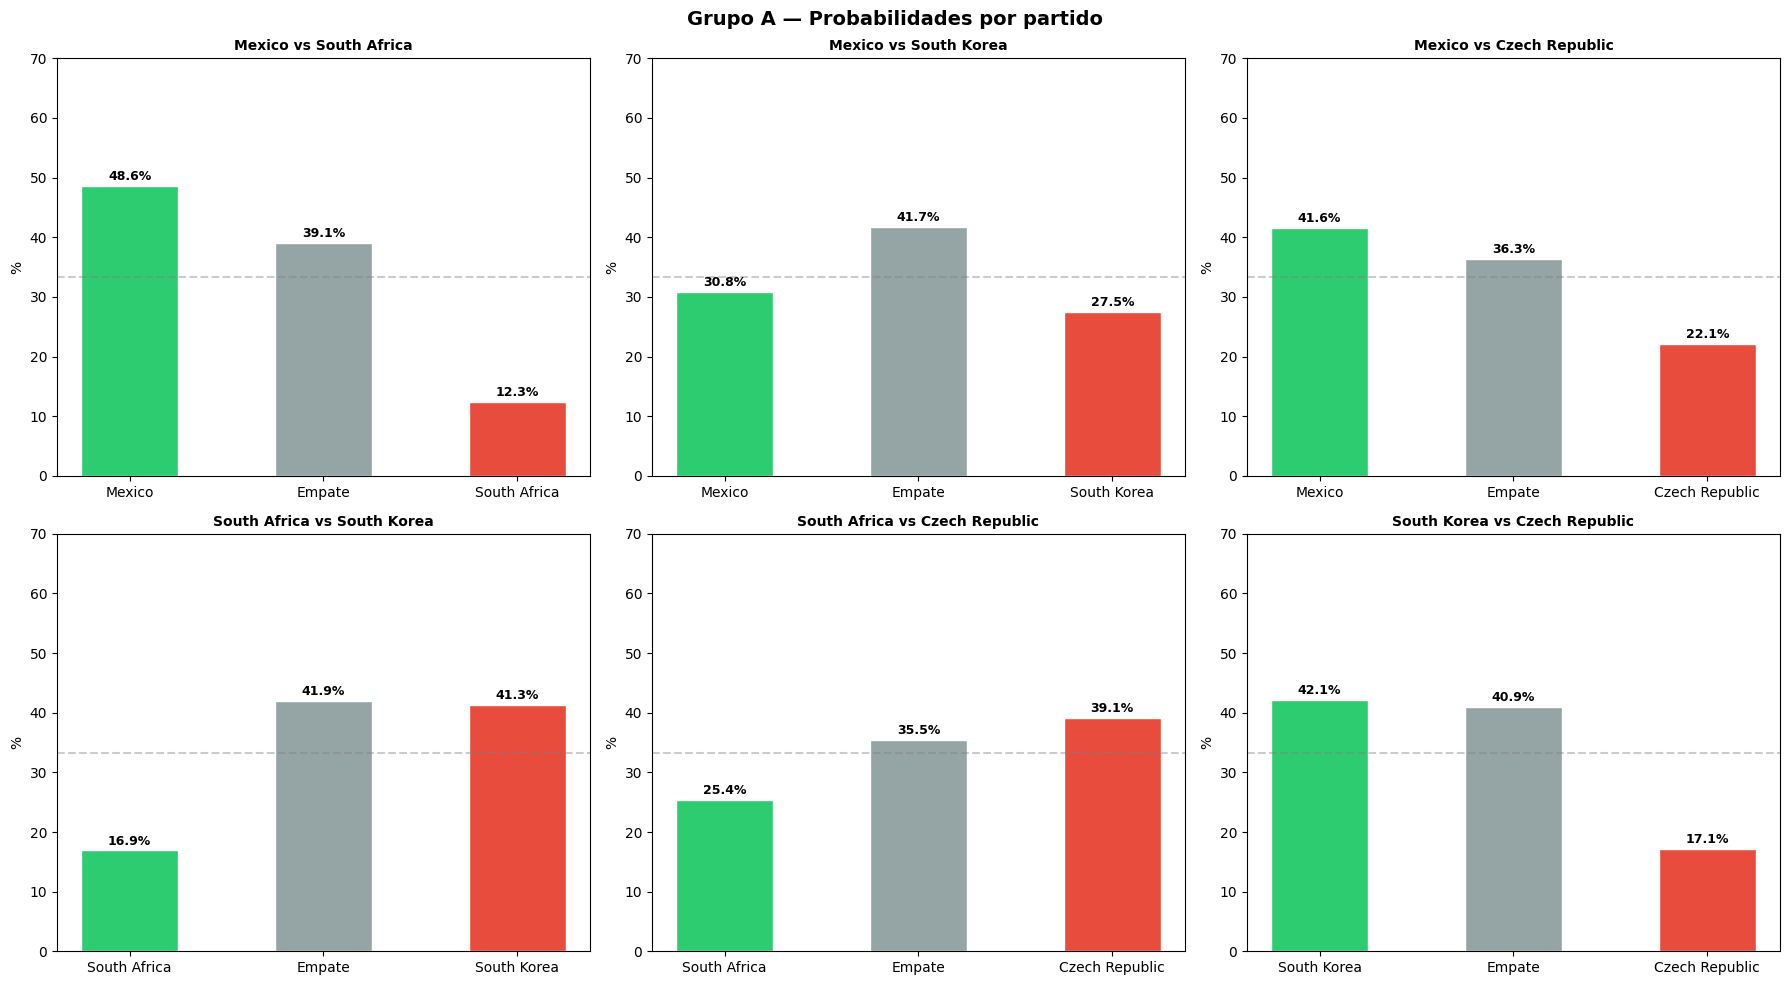

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Grupo A — Probabilidades por partido', fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, row in df_partidos_A.iterrows():
    probs = [round(row['victoria_A'], 1), round(row['empate'], 1), round(row['victoria_B'], 1)]
    labels = [row['home'], 'Empate', row['away']]
    colores = ['#2ecc71', '#95a5a6', '#e74c3c']

    bars = axes[idx].bar(labels, probs, color=colores, edgecolor='white', width=0.5)
    axes[idx].set_title(f"{row['home']} vs {row['away']}", fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('%')
    axes[idx].set_ylim(0, 70)
    axes[idx].axhline(y=33.3, color='gray', linestyle='--', alpha=0.4)

    for bar, pct in zip(bars, probs):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                      f'{pct}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# --- PROBABILIDADES DE TODOS LOS GRUPOS ---
resultados_grupos = {}
dfs_partidos = {}

for grupo, equipos in grupos.items():
    print(f'Simulando Grupo {grupo}...')

    # Probabilidades por partido
    partidos = [(equipos[i], equipos[j])
                for i in range(len(equipos))
                for j in range(i+1, len(equipos))]

    filas_partidos = []
    for home, away in partidos:
        probs = prob_partido(home, away, modelo_bal, features_dict)
        filas_partidos.append({'home': home, 'away': away, **probs})
    dfs_partidos[grupo] = pd.DataFrame(filas_partidos)

    # MCTS clasificación
    resultados_grupos[grupo] = mcts_grupo(equipos, modelo_bal, features_dict)

print('Completado')

Simulando Grupo A...
Simulando Grupo B...
Simulando Grupo C...
Simulando Grupo D...
Simulando Grupo E...
Simulando Grupo F...
Simulando Grupo G...
Simulando Grupo H...
Simulando Grupo I...
Simulando Grupo J...
Simulando Grupo K...
Simulando Grupo L...
Completado


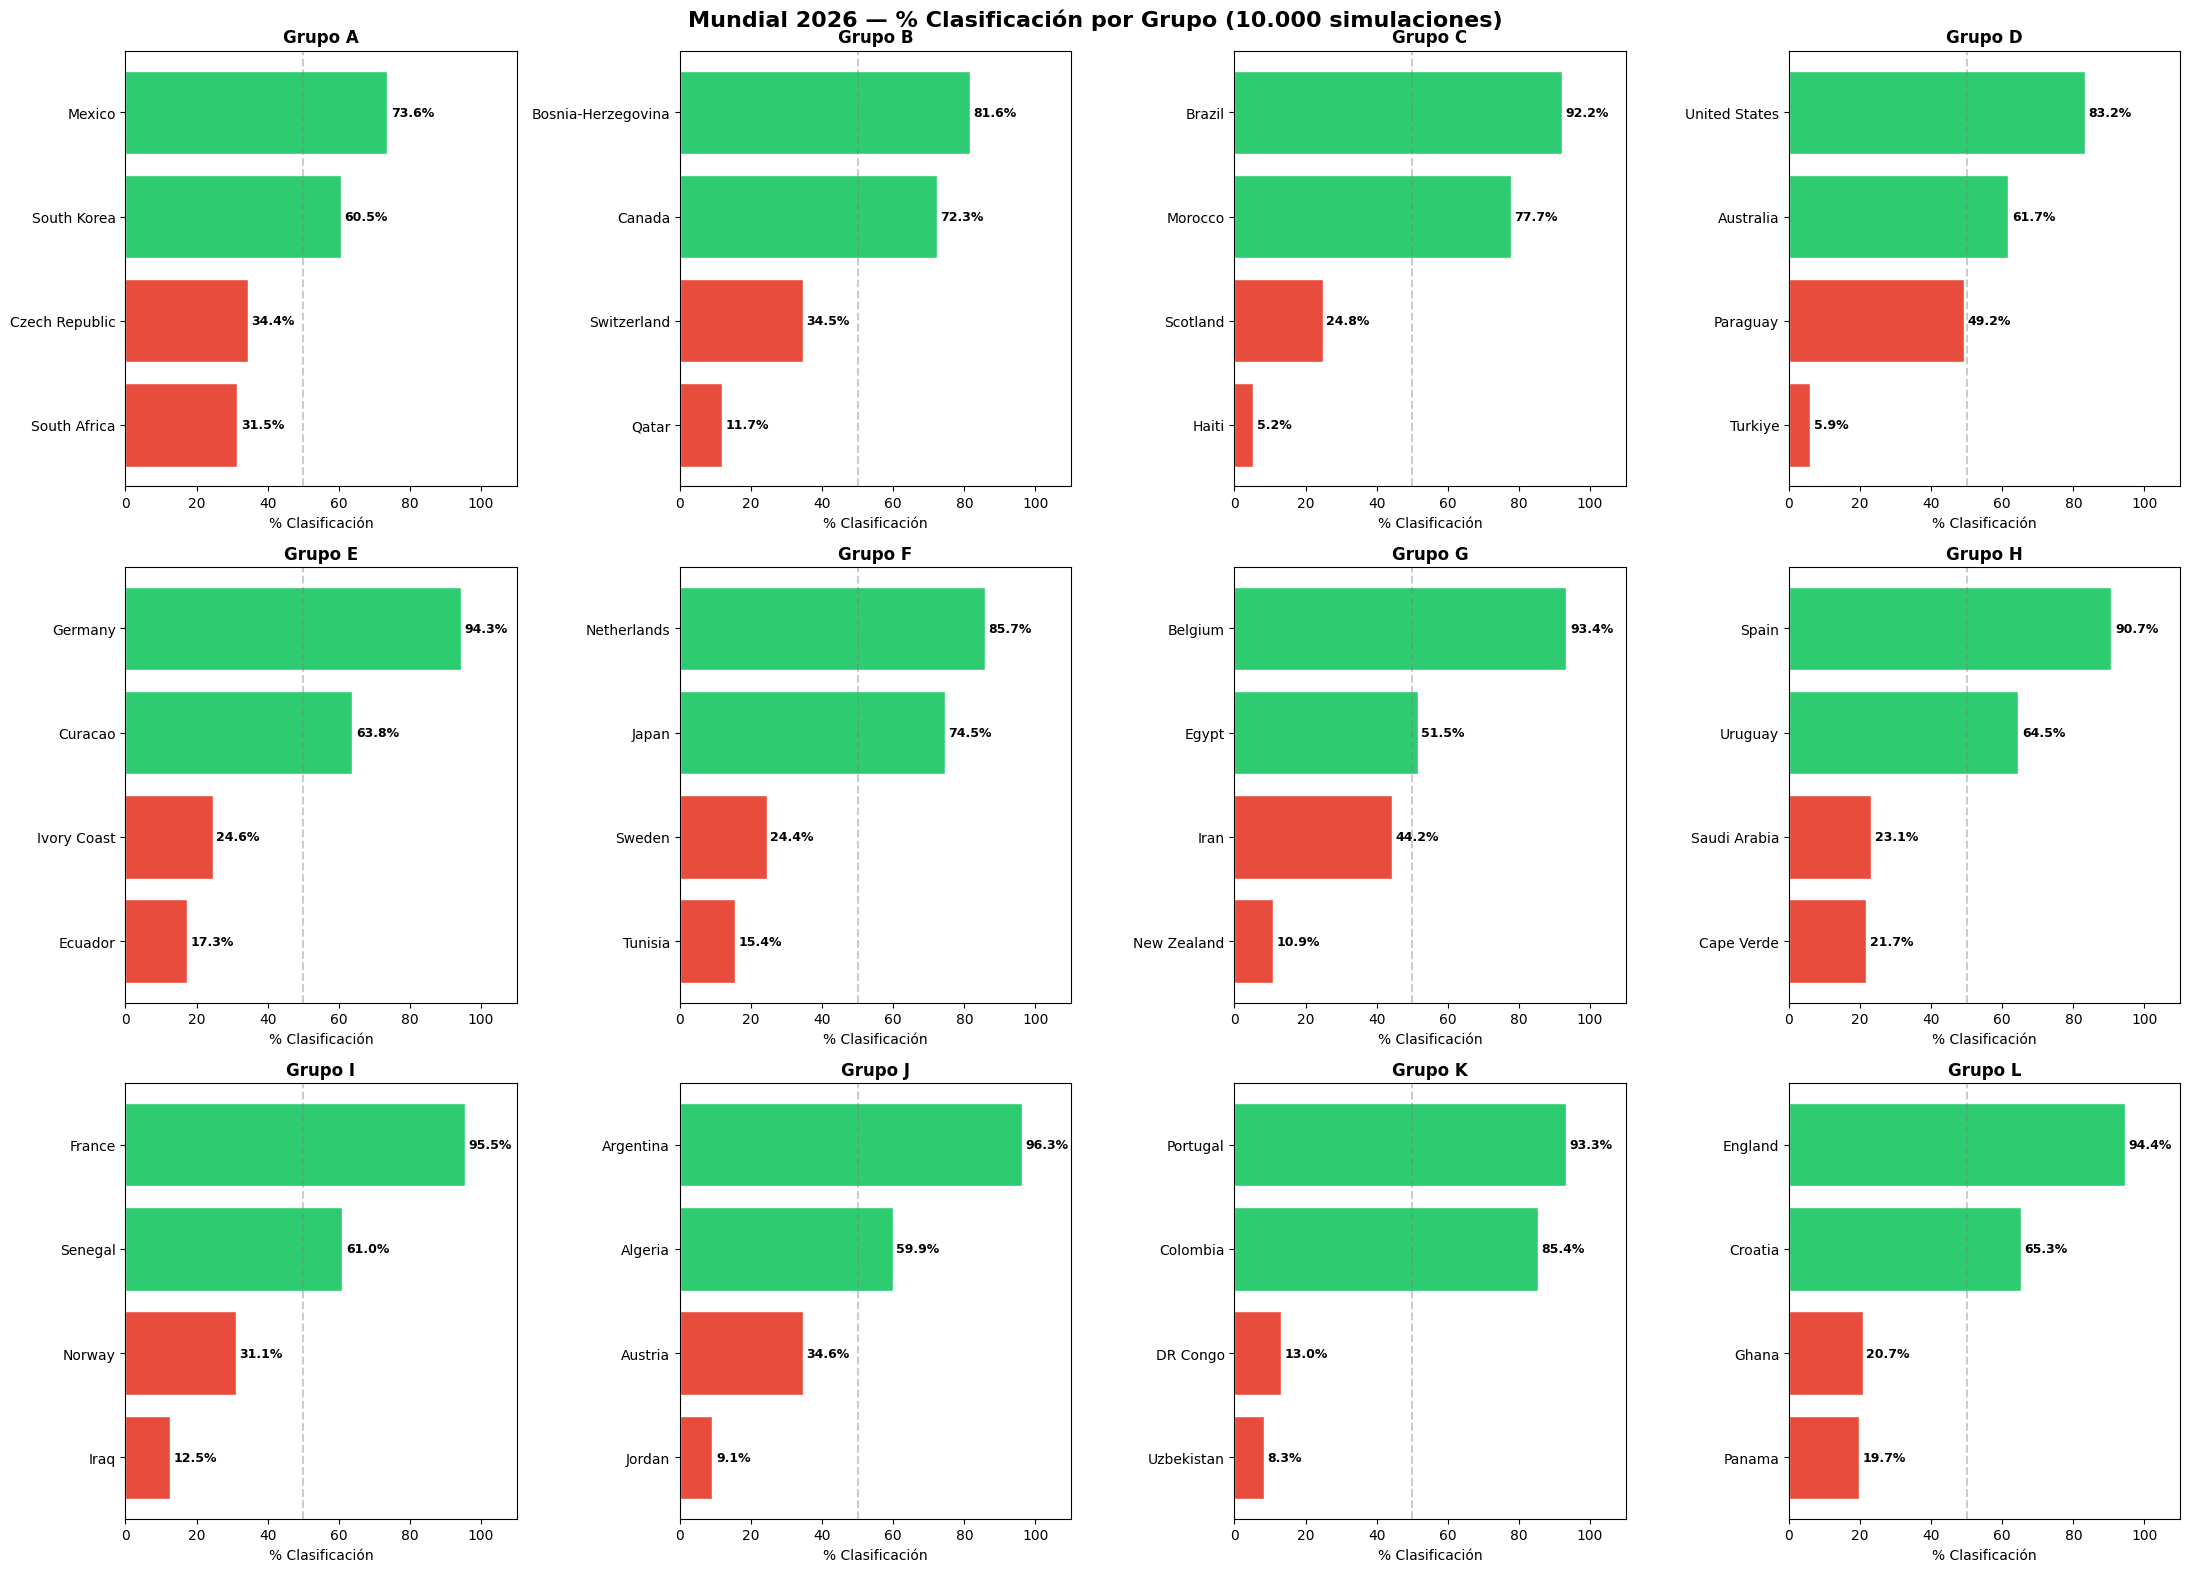

In [ ]:
# --- GRÁFICA GLOBAL: % clasificación por grupo ---
fig, axes = plt.subplots(3, 4, figsize=(22, 16))
fig.suptitle('Mundial 2026 — % Clasificación por Grupo (10.000 simulaciones)',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, (grupo, probs) in enumerate(resultados_grupos.items()):
    equipos = list(probs.keys())
    pcts = list(probs.values())
    colores_barras = ['#2ecc71' if i < 2 else '#e74c3c' for i in range(len(equipos))]

    bars = axes[idx].barh(equipos, pcts, color=colores_barras, edgecolor='white')
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'Grupo {grupo}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('% Clasificación')
    axes[idx].set_xlim(0, 110)
    axes[idx].axvline(x=50, color='gray', linestyle='--', alpha=0.4)

    for bar, pct in zip(bars, pcts):
        axes[idx].text(pct + 1, bar.get_y() + bar.get_height()/2,
                      f'{pct}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Comprobamos Turquía y Curazao en features_dict
print('Turkiye:', features_dict.get('Turkiye'))
print('Curacao:', features_dict.get('Curacao'))

# Comprobamos grupo D
print('\nGrupo D:', grupos['D'])

Turkiye: {'ELO_norm': nan, 'Log_MarketValue': 0.8457247559596042, 'Momentum_15': 0.6342412451361867, 'Knockout_Performance': 0.5826824832453712, 'Pressure_Index': 0.42875151483708734}
Curacao: {'ELO_norm': nan, 'Log_MarketValue': 0.5335956924643963, 'Momentum_15': 0.6342412451361867, 'Knockout_Performance': 0.5826824832453712, 'Pressure_Index': 0.42875151483708734}

Grupo D: ['United States', 'Paraguay', 'Australia', 'Turkiye']


In [ ]:
# Corregimos ELO_norm para Turkiye y Curacao
elo_turkiye = elo_dict.get('Turkiye', elo_dict.get('Turkey', 1500))
elo_curacao = 1550.0  # valor manual que asignamos antes

# Recalculamos ELO_norm con el rango de df_mundial
elo_min = df_mundial['ELO'].min()
elo_max = df_mundial['ELO'].max()

def normalizar_elo(elo):
    return (elo - elo_min) / (elo_max - elo_min)

features_dict['Turkiye']['ELO_norm'] = normalizar_elo(elo_turkiye)
features_dict['Curacao']['ELO_norm'] = normalizar_elo(elo_curacao)

print('Turkiye ELO:', elo_turkiye, '→ norm:', round(normalizar_elo(elo_turkiye), 3))
print('Curacao ELO:', elo_curacao, '→ norm:', round(normalizar_elo(elo_curacao), 3))

Turkiye ELO: 1758.4505798673827 → norm: 0.484
Curacao ELO: 1550.0 → norm: 0.0


In [ ]:
# Revisamos todos los equipos de los grupos
equipos_con_nan = []
for grupo, equipos in grupos.items():
    for eq in equipos:
        f = features_dict.get(eq, {})
        if any(np.isnan(v) for v in f.values()):
            equipos_con_nan.append((grupo, eq, f))

print(f'Equipos con NaN: {len(equipos_con_nan)}')
for grupo, eq, f in equipos_con_nan:
    print(f'Grupo {grupo} — {eq}: {f}')

Equipos con NaN: 1
Grupo B — Bosnia-Herzegovina: {'ELO_norm': nan, 'Log_MarketValue': 0.648510613386087, 'Momentum_15': 0.6342412451361867, 'Knockout_Performance': 0.5826824832453712, 'Pressure_Index': 0.42875151483708734}


In [ ]:
elo_bosnia = elo_dict.get('Bosnia-Herzegovina', elo_dict.get('Bosnia and Herzegovina', 1500))
features_dict['Bosnia-Herzegovina']['ELO_norm'] = normalizar_elo(elo_bosnia)

print('Bosnia ELO:', elo_bosnia, '→ norm:', round(normalizar_elo(elo_bosnia), 3))

Bosnia ELO: 1530.1188644290653 → norm: -0.046


In [ ]:
# Usamos rango global para normalizar
elo_values = [v for v in elo_dict.values() if not np.isnan(v)]
elo_min_global = min(elo_values)
elo_max_global = max(elo_values)

def normalizar_elo_global(elo):
    return (elo - elo_min_global) / (elo_max_global - elo_min_global)

# Corregimos los 3 equipos
features_dict['Turkiye']['ELO_norm']           = normalizar_elo_global(elo_dict.get('Turkiye', 1500))
features_dict['Curacao']['ELO_norm']           = normalizar_elo_global(1550.0)
features_dict['Bosnia-Herzegovina']['ELO_norm'] = normalizar_elo_global(elo_dict.get('Bosnia-Herzegovina', 1500))

print('Turkiye:',          round(features_dict['Turkiye']['ELO_norm'], 3))
print('Curacao:',          round(features_dict['Curacao']['ELO_norm'], 3))
print('Bosnia-Herzegovina:', round(features_dict['Bosnia-Herzegovina']['ELO_norm'], 3))

Turkiye: 0.496
Curacao: 0.549
Bosnia-Herzegovina: 0.496


In [ ]:
# Verificamos cómo está en elo_dict
print(elo_dict.get('Curaçao'), elo_dict.get('Curacao'))

# Corregimos el nombre en grupos
grupos['E'] = ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador']

# Corregimos en features_dict
elo_curacao = elo_dict.get('Curaçao', 1550.0)
features_dict['Curaçao'] = features_dict.pop('Curacao', features_dict.get('Curaçao', {}))
features_dict['Curaçao']['ELO_norm'] = normalizar_elo_global(elo_curacao)

print('Curaçao ELO:', elo_curacao, '→ norm:', round(features_dict['Curaçao']['ELO_norm'], 3))

1542.5455681272656 None
Curaçao ELO: 1542.5455681272656 → norm: 0.541


In [ ]:
# Verificamos que todos los equipos de los grupos tienen ELO en elo_dict
for grupo, equipos in grupos.items():
    for eq in equipos:
        elo = elo_dict.get(eq)
        f = features_dict.get(eq, {})
        elo_norm = f.get('ELO_norm', None)
        if elo is None or elo_norm is None or np.isnan(elo_norm):
            print(f'Grupo {grupo} — {eq}: ELO={elo}, ELO_norm={elo_norm}')

print('Revisión completada')

Grupo B — Bosnia-Herzegovina: ELO=None, ELO_norm=0.49612395417727123
Grupo D — Turkiye: ELO=None, ELO_norm=0.49612395417727123
Revisión completada


In [ ]:
# Buscamos cómo aparecen en elo_dict
for term in ['Bosni', 'Turk', 'Turkey']:
    matches = [k for k in elo_dict.keys() if term.lower() in k.lower()]
    print(f'{term} → {matches}')

Bosni → ['Bosnia and Herzegovina']
Turk → ['Turkmenistan', 'Turkey', 'Turks and Caicos Islands']
Turkey → ['Turkey']


In [ ]:
features_dict['Bosnia-Herzegovina']['ELO_norm'] = normalizar_elo_global(elo_dict['Bosnia and Herzegovina'])
features_dict['Turkiye']['ELO_norm'] = normalizar_elo_global(elo_dict['Turkey'])

print('Bosnia:', round(features_dict['Bosnia-Herzegovina']['ELO_norm'], 3))
print('Turkiye:', round(features_dict['Turkiye']['ELO_norm'], 3))

Bosnia: 0.528
Turkiye: 0.767


In [ ]:
# Verificación final
problemas = []
for grupo, equipos in grupos.items():
    for eq in equipos:
        f = features_dict.get(eq, {})
        if not f or any(v is None or np.isnan(v) for v in f.values()):
            problemas.append((grupo, eq))

if problemas:
    print('Equipos con problemas:', problemas)
else:
    print('Todo limpio, resimulando...')
    resultados_grupos = {}
    for grupo, equipos in grupos.items():
        resultados_grupos[grupo] = mcts_grupo(equipos, modelo_bal, features_dict)
    print('Completado')

Todo limpio, resimulando...
Completado


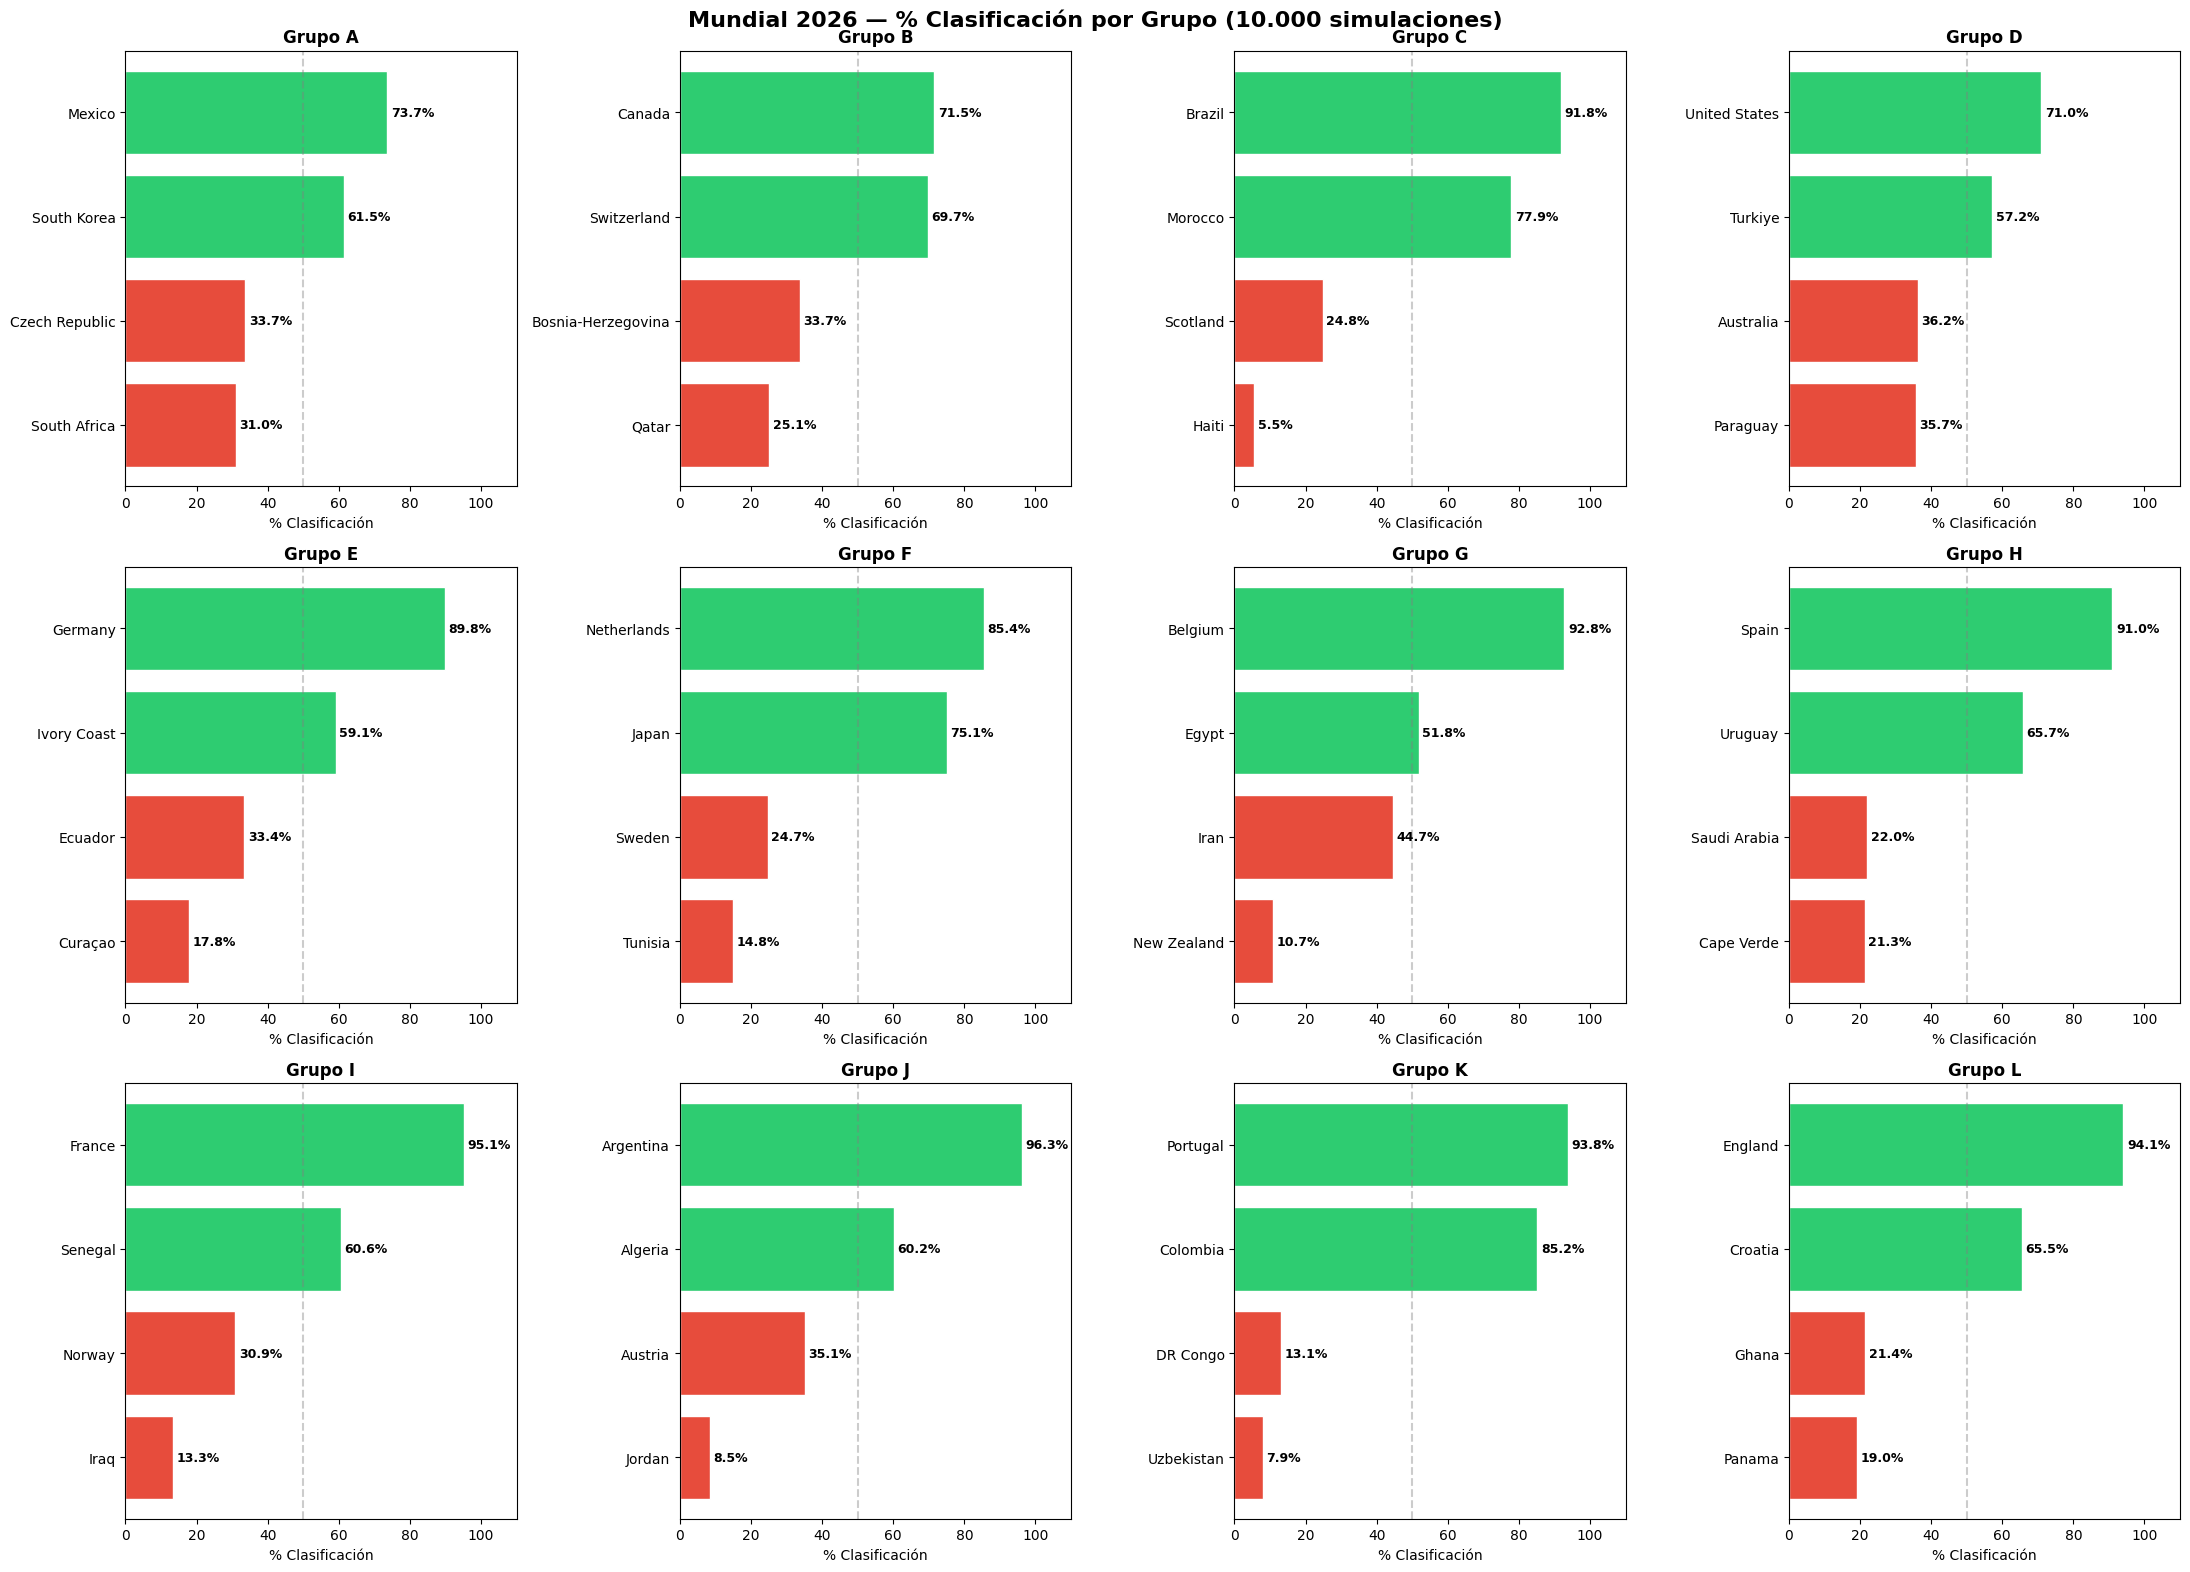

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(22, 16))
fig.suptitle('Mundial 2026 — % Clasificación por Grupo (10.000 simulaciones)',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, (grupo, probs) in enumerate(resultados_grupos.items()):
    equipos = list(probs.keys())
    pcts = list(probs.values())
    colores_barras = ['#2ecc71' if i < 2 else '#e74c3c' for i in range(len(equipos))]

    bars = axes[idx].barh(equipos, pcts, color=colores_barras, edgecolor='white')
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'Grupo {grupo}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('% Clasificación')
    axes[idx].set_xlim(0, 110)
    axes[idx].axvline(x=50, color='gray', linestyle='--', alpha=0.4)

    for bar, pct in zip(bars, pcts):
        axes[idx].text(pct + 1, bar.get_y() + bar.get_height()/2,
                      f'{pct}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

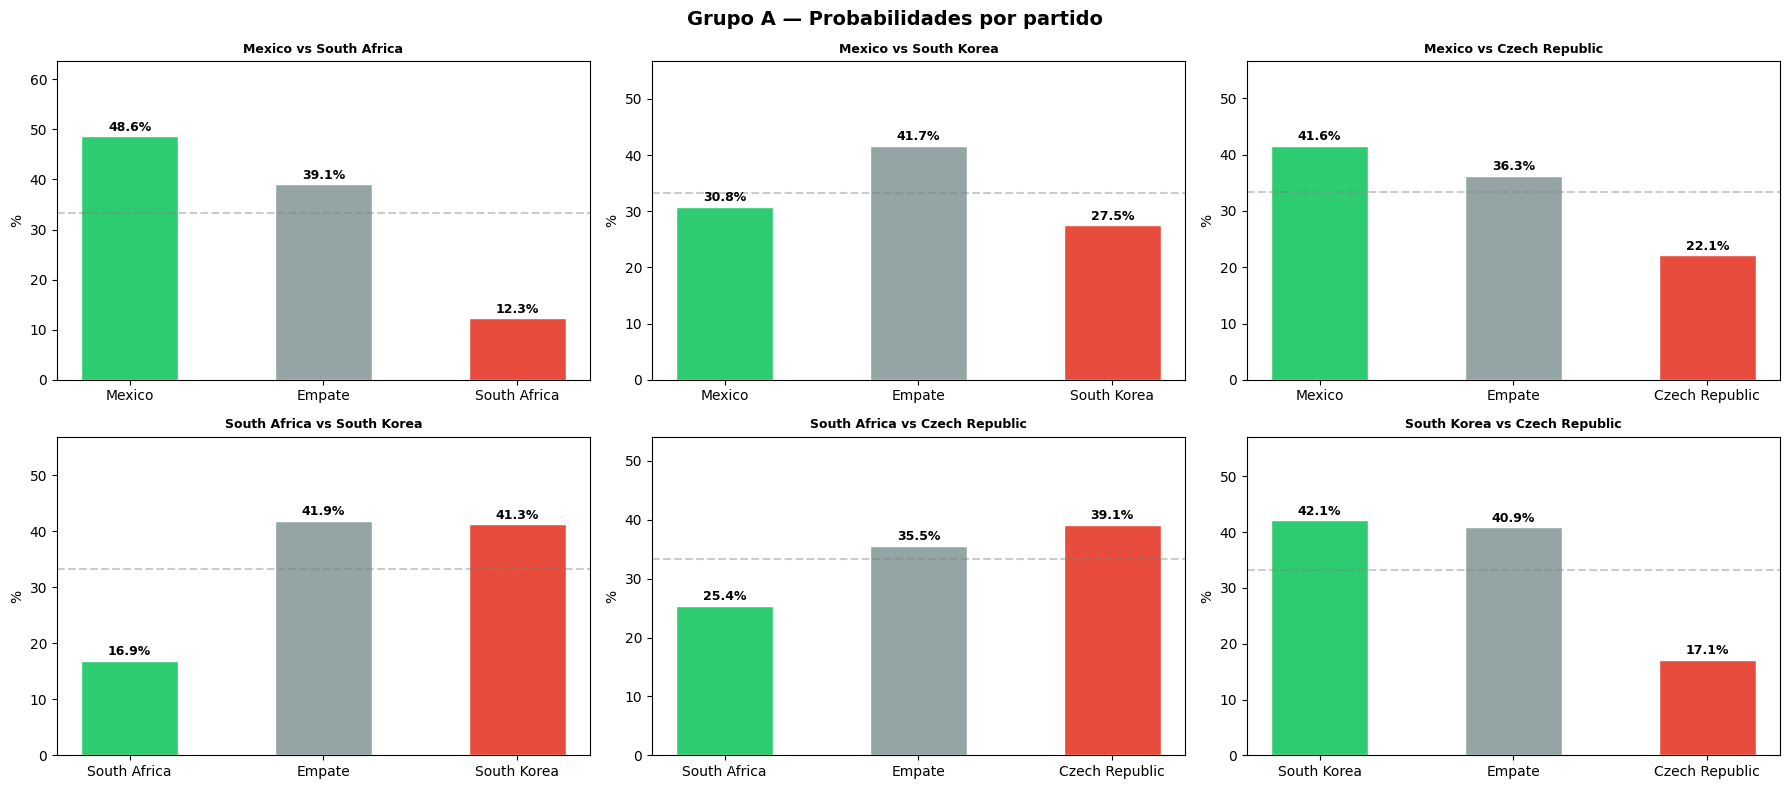

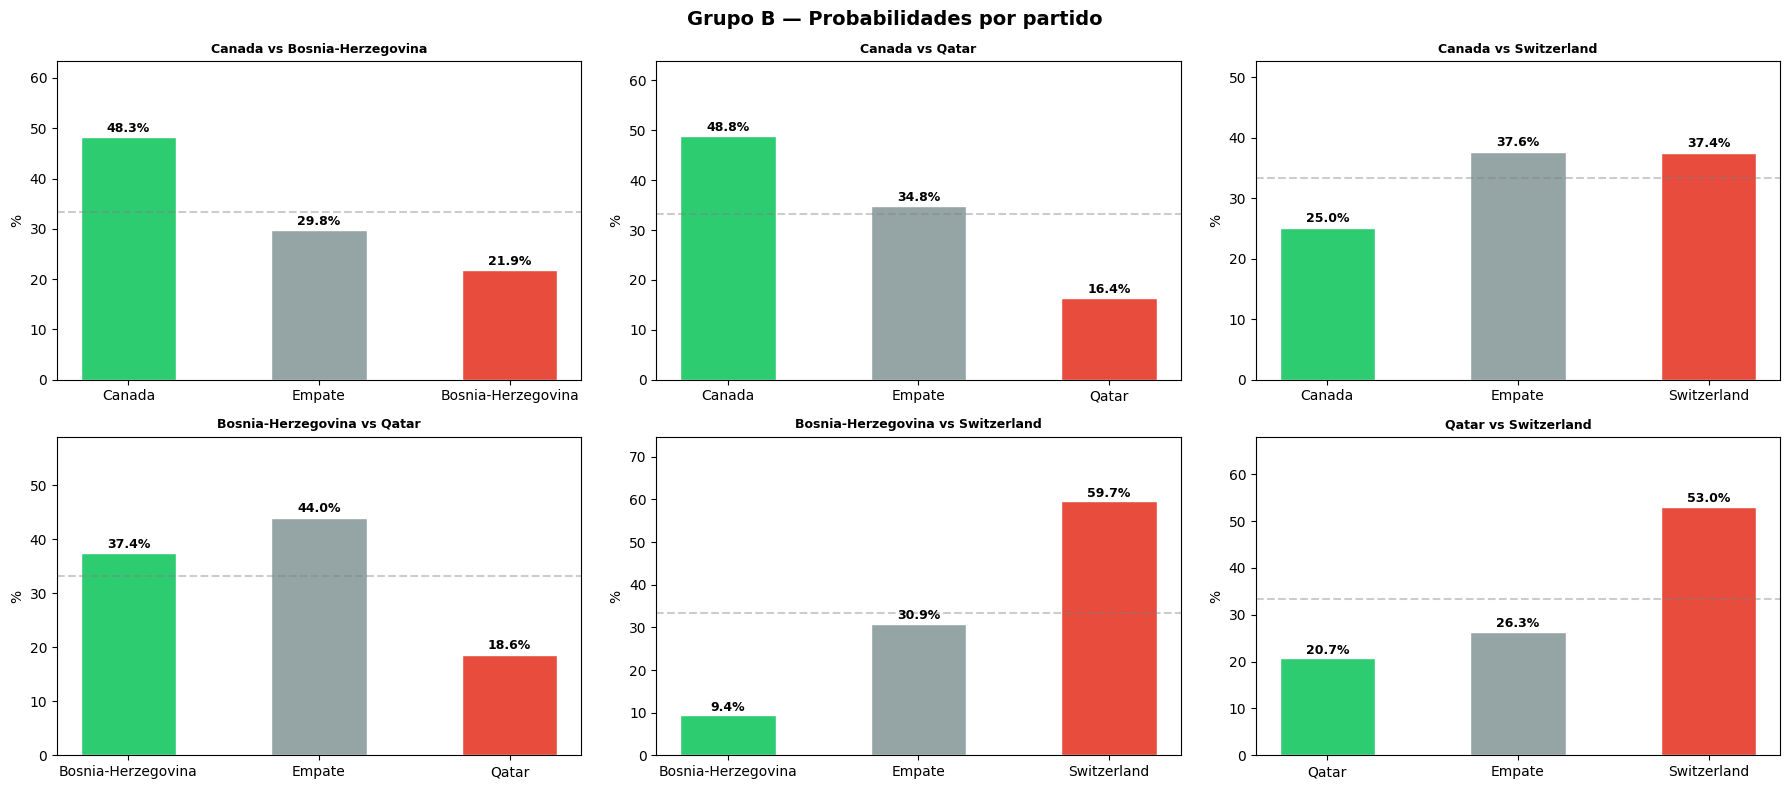

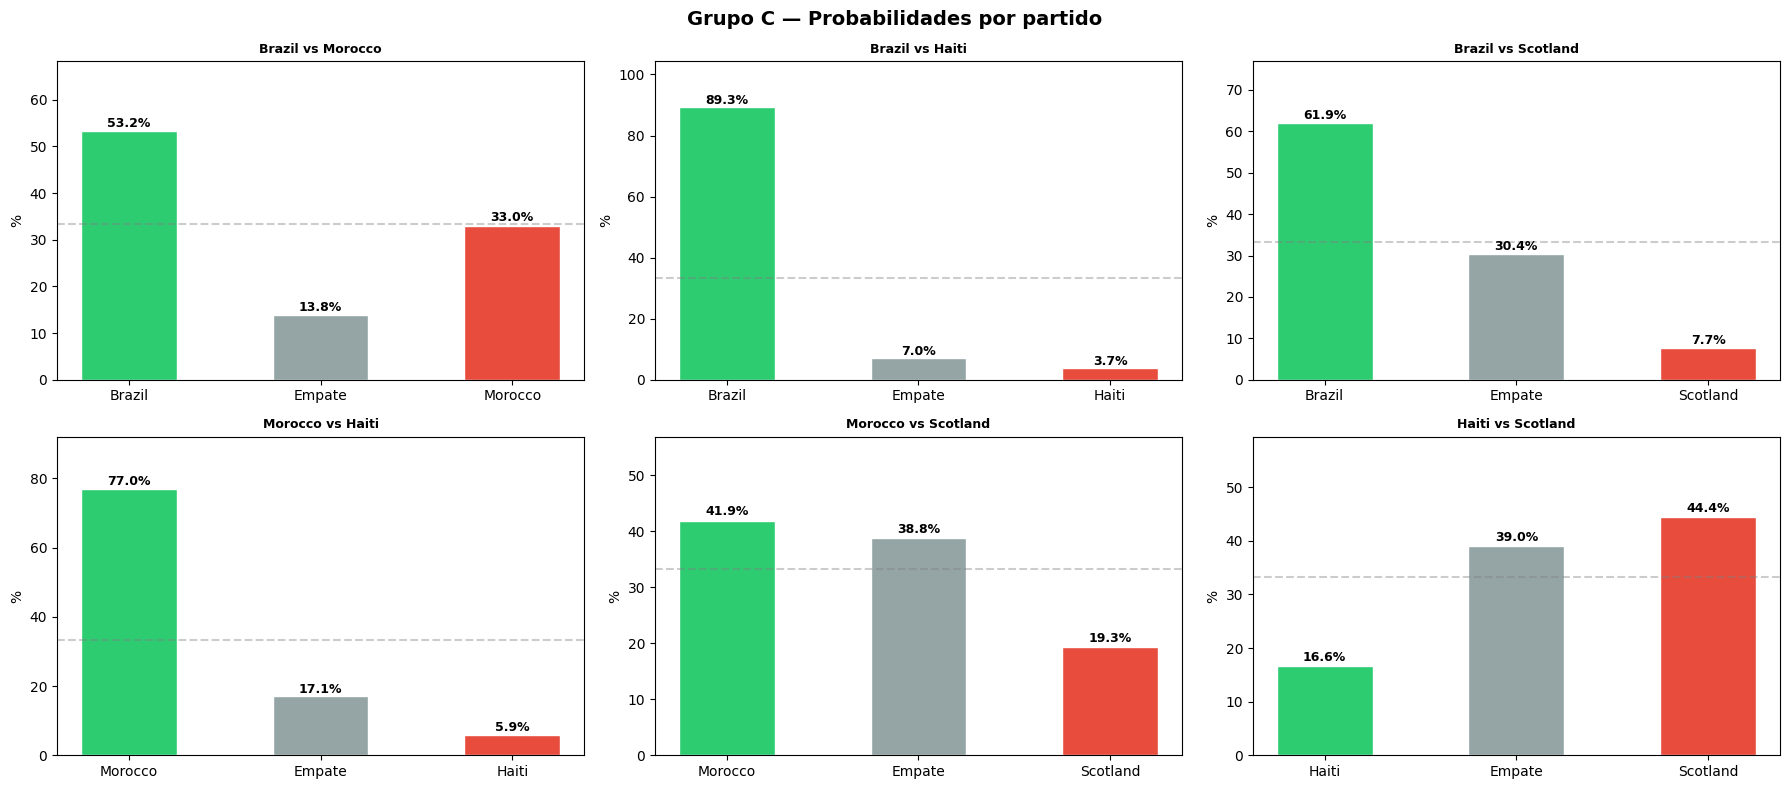

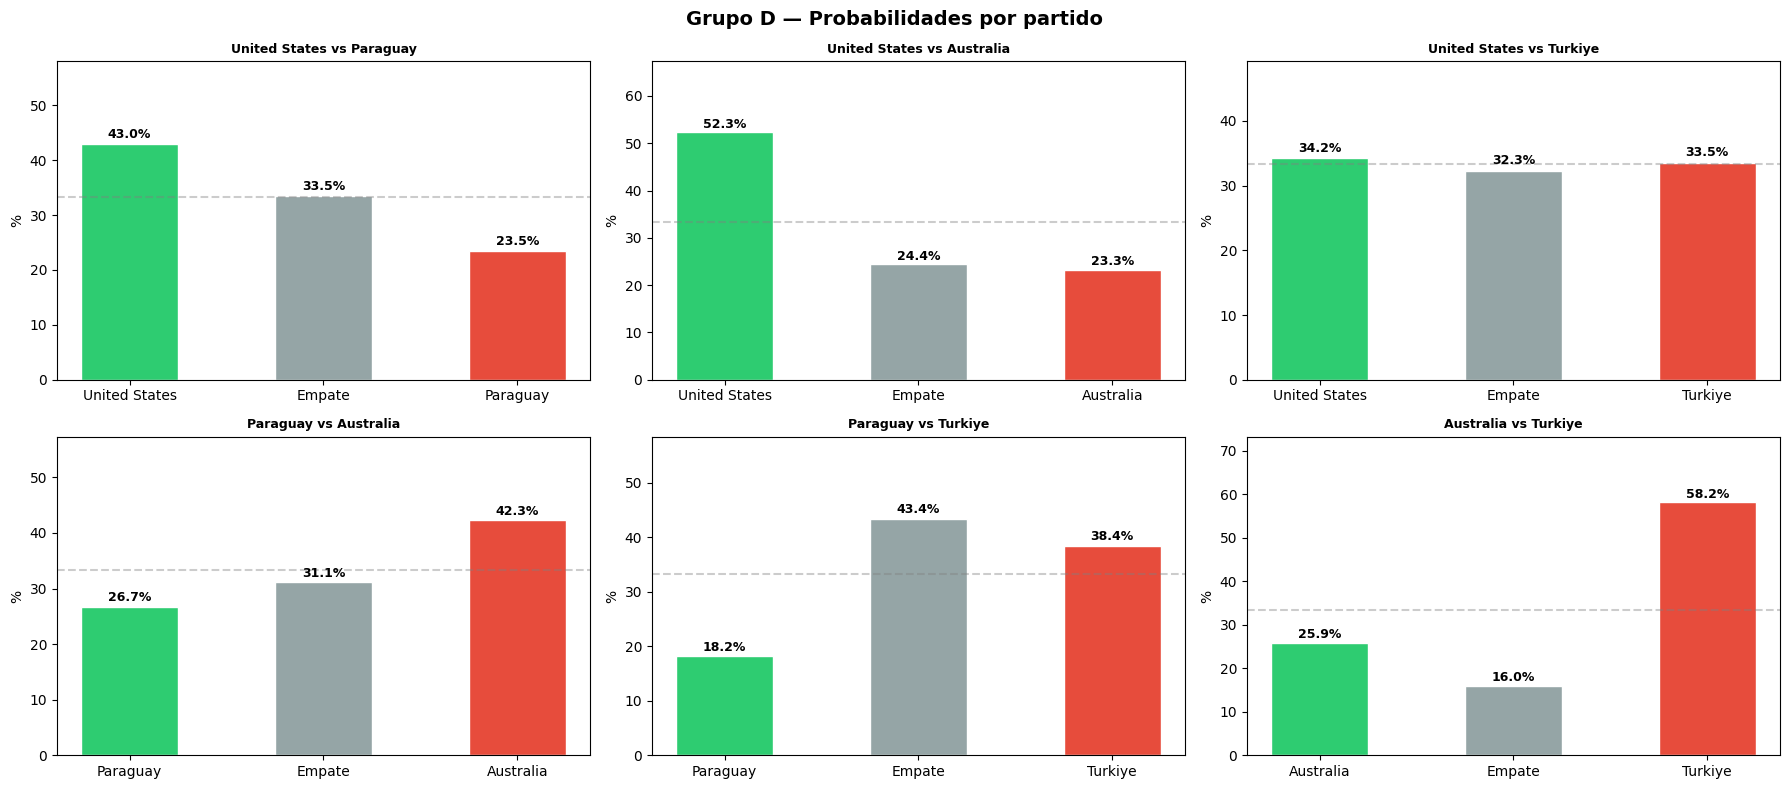

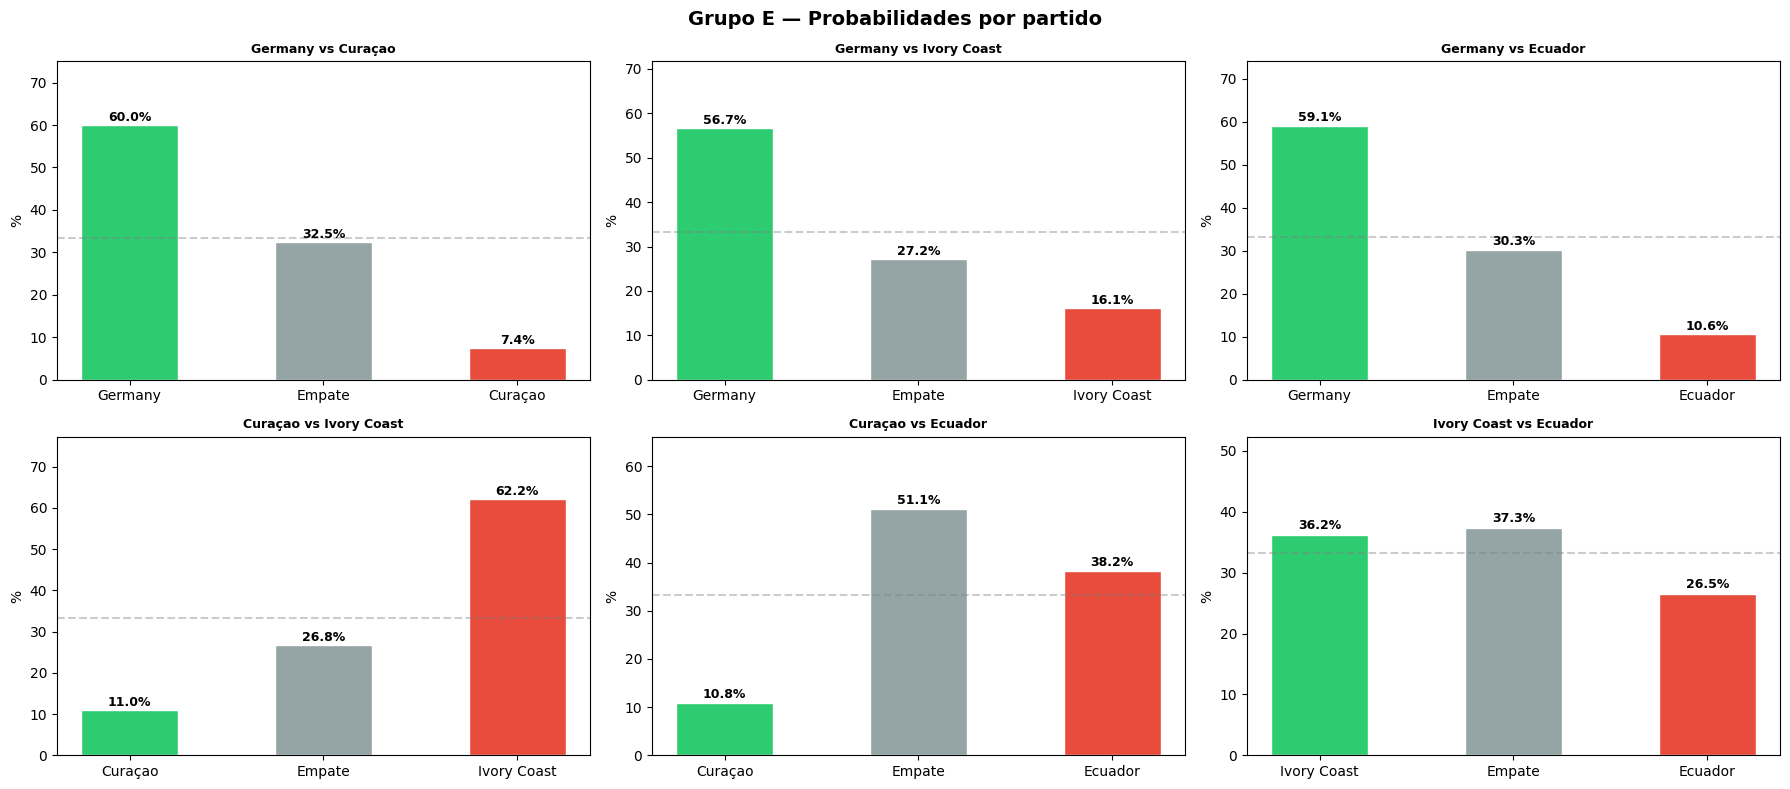

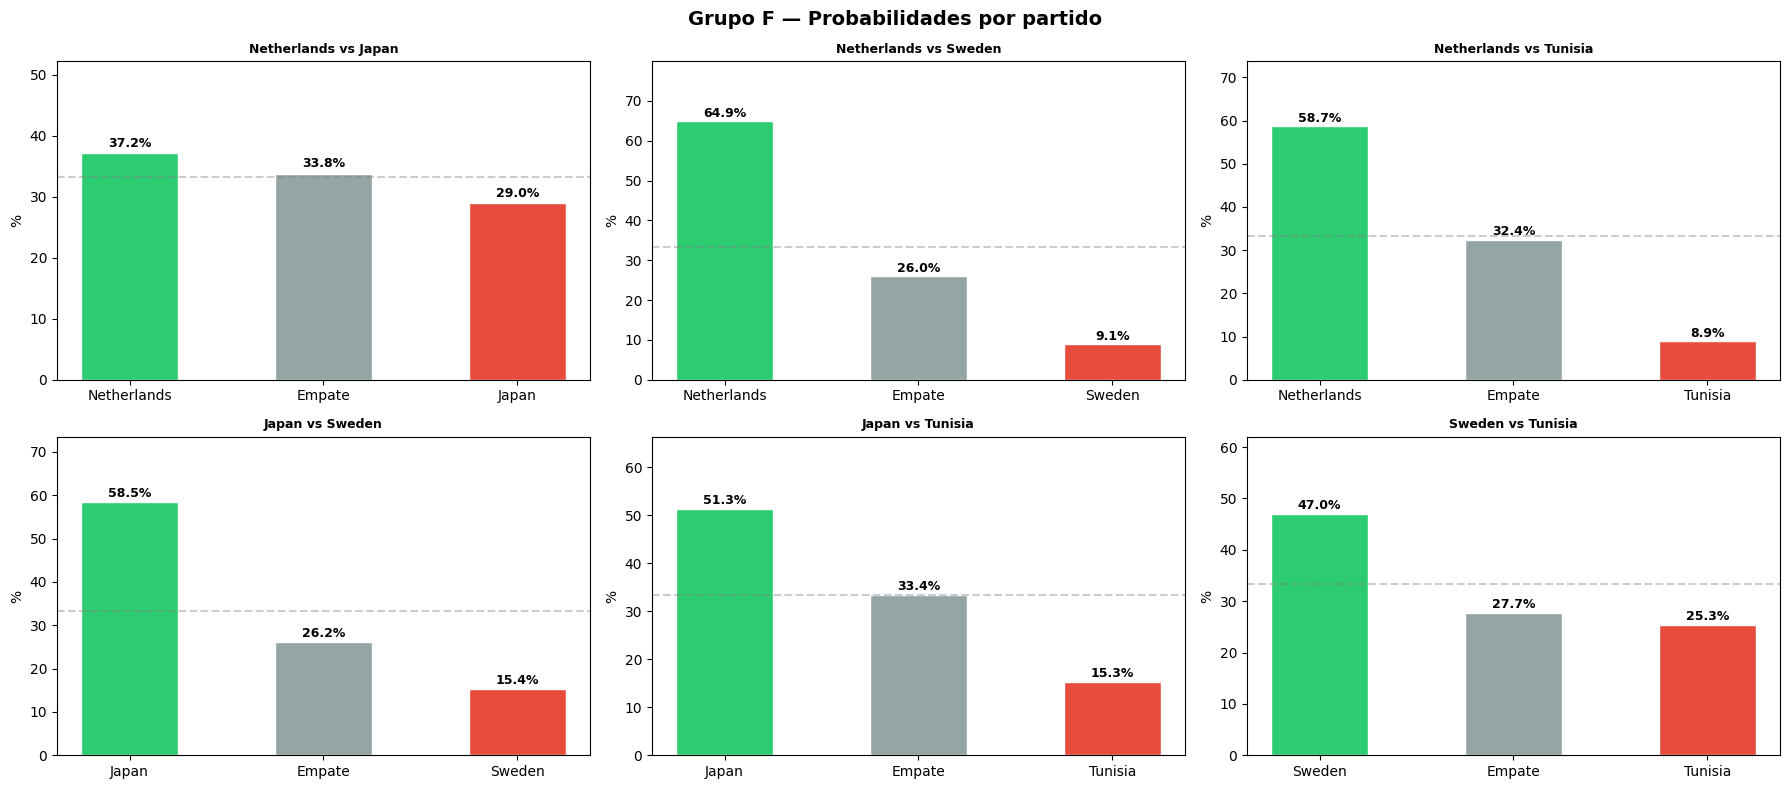

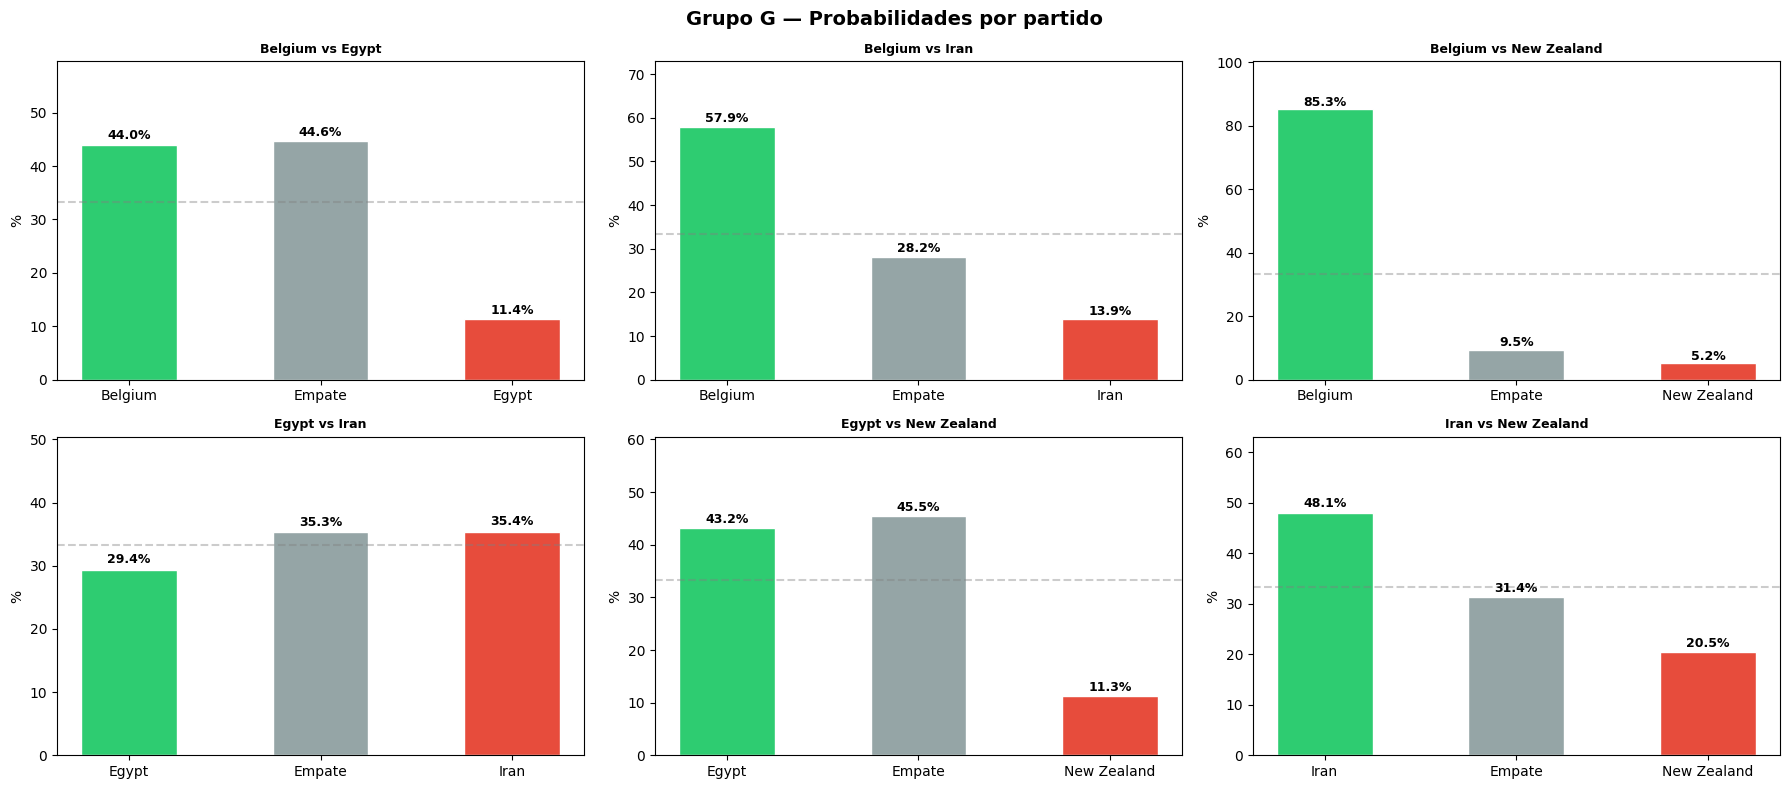

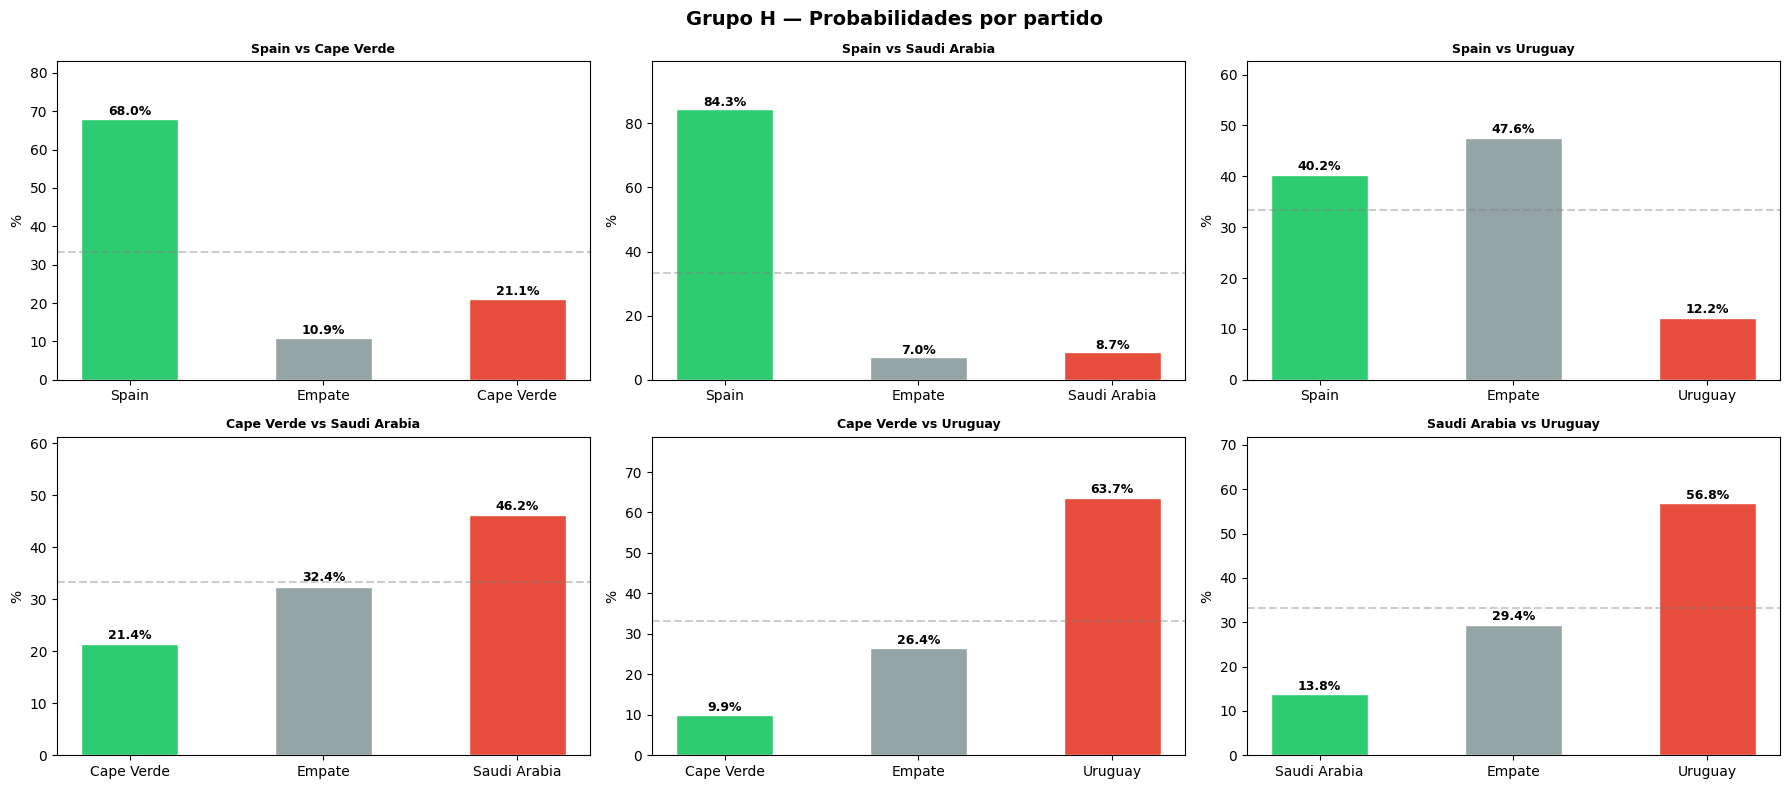

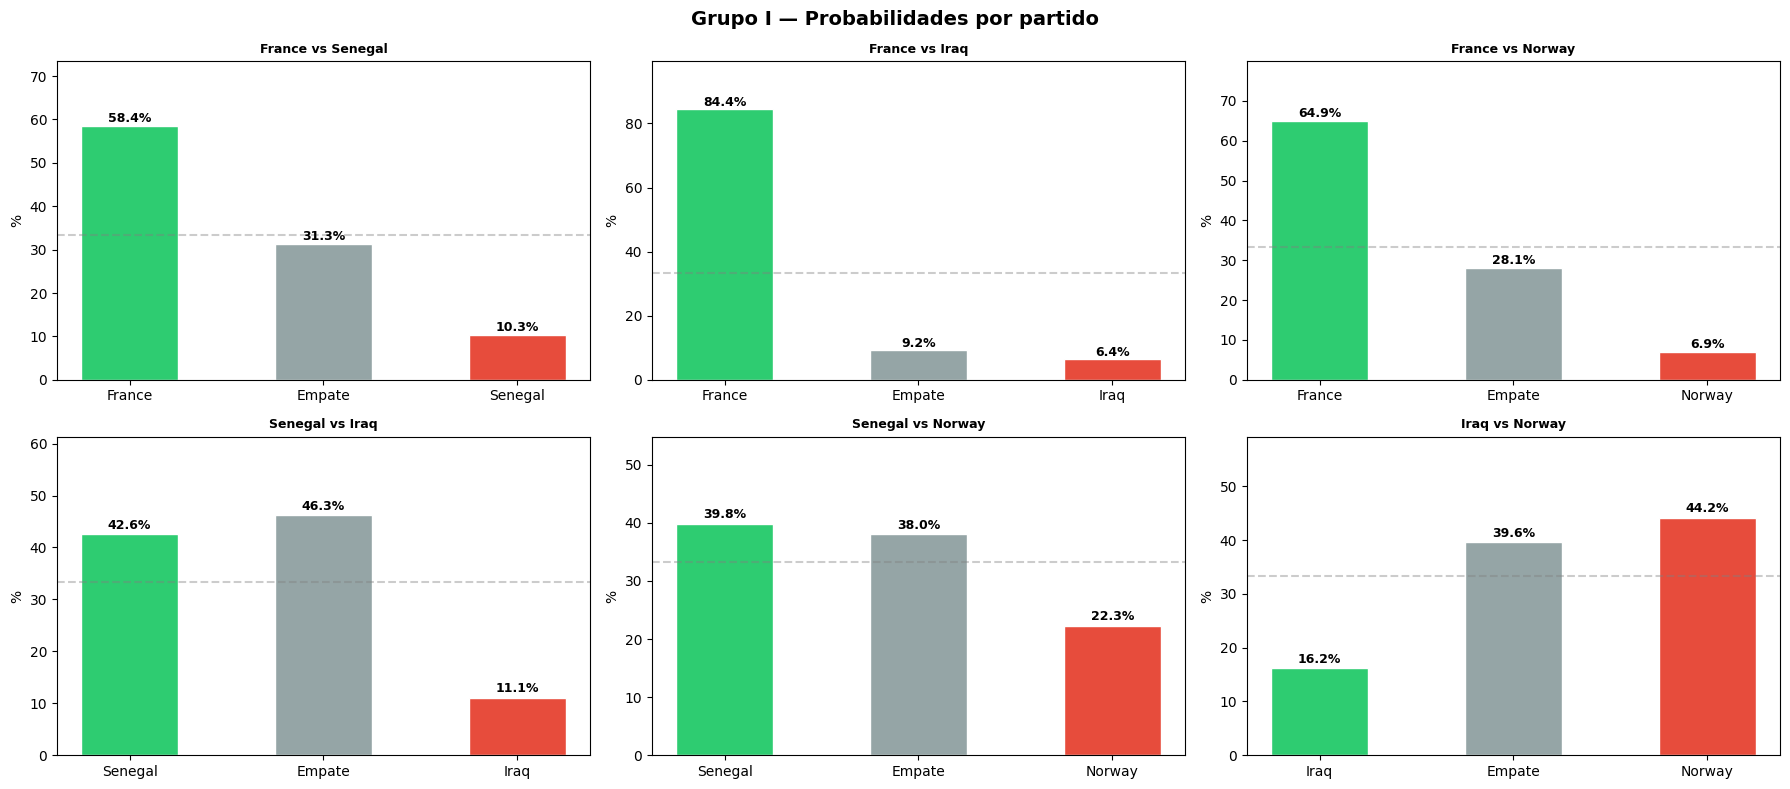

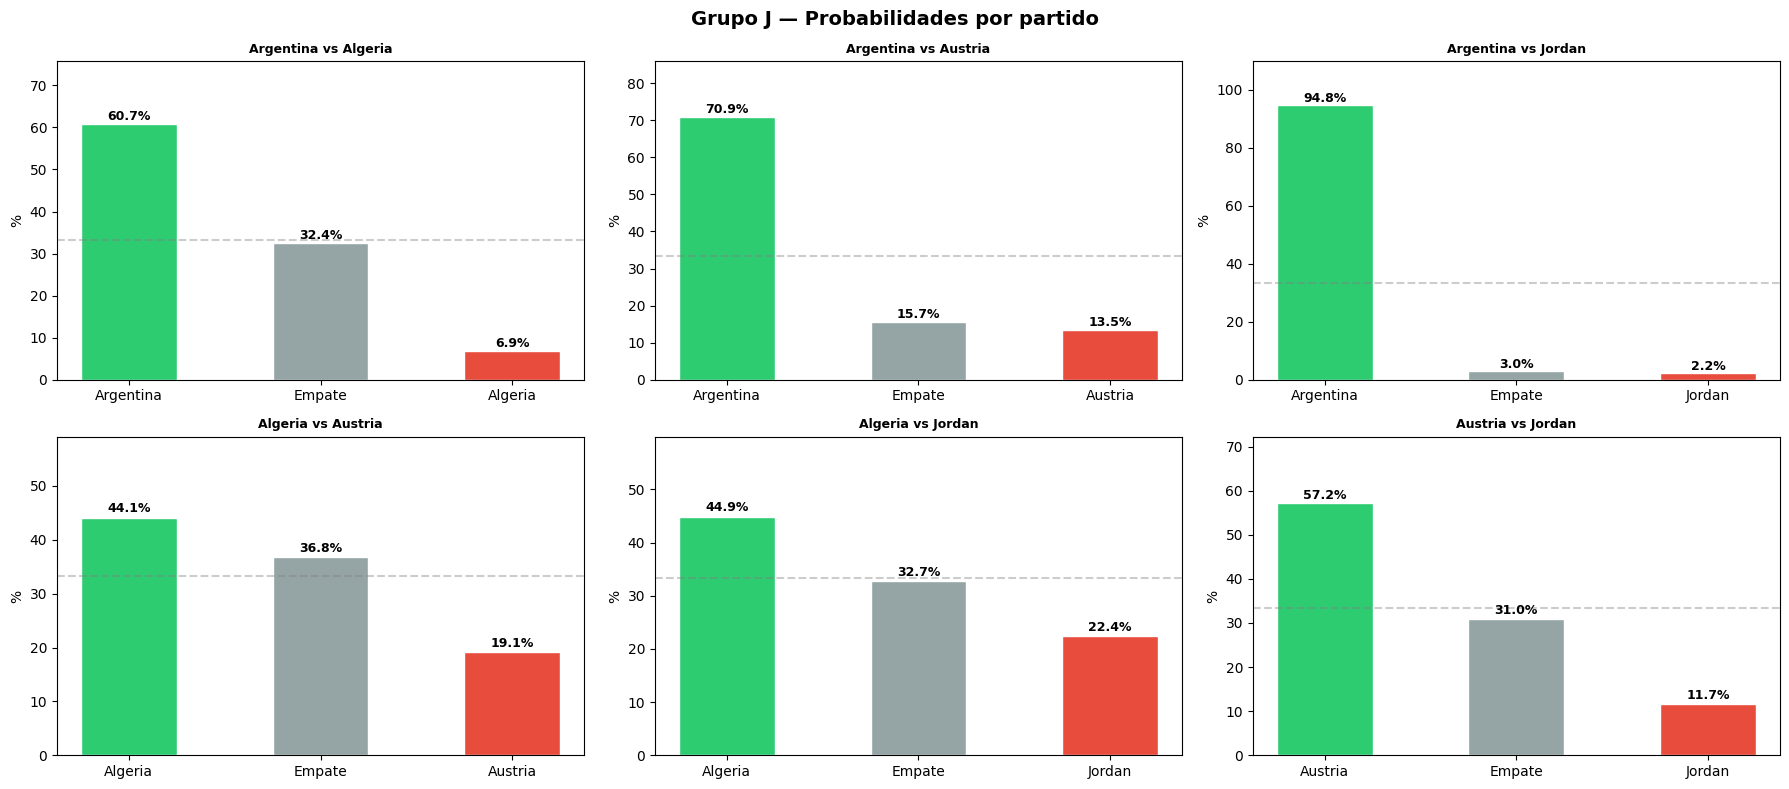

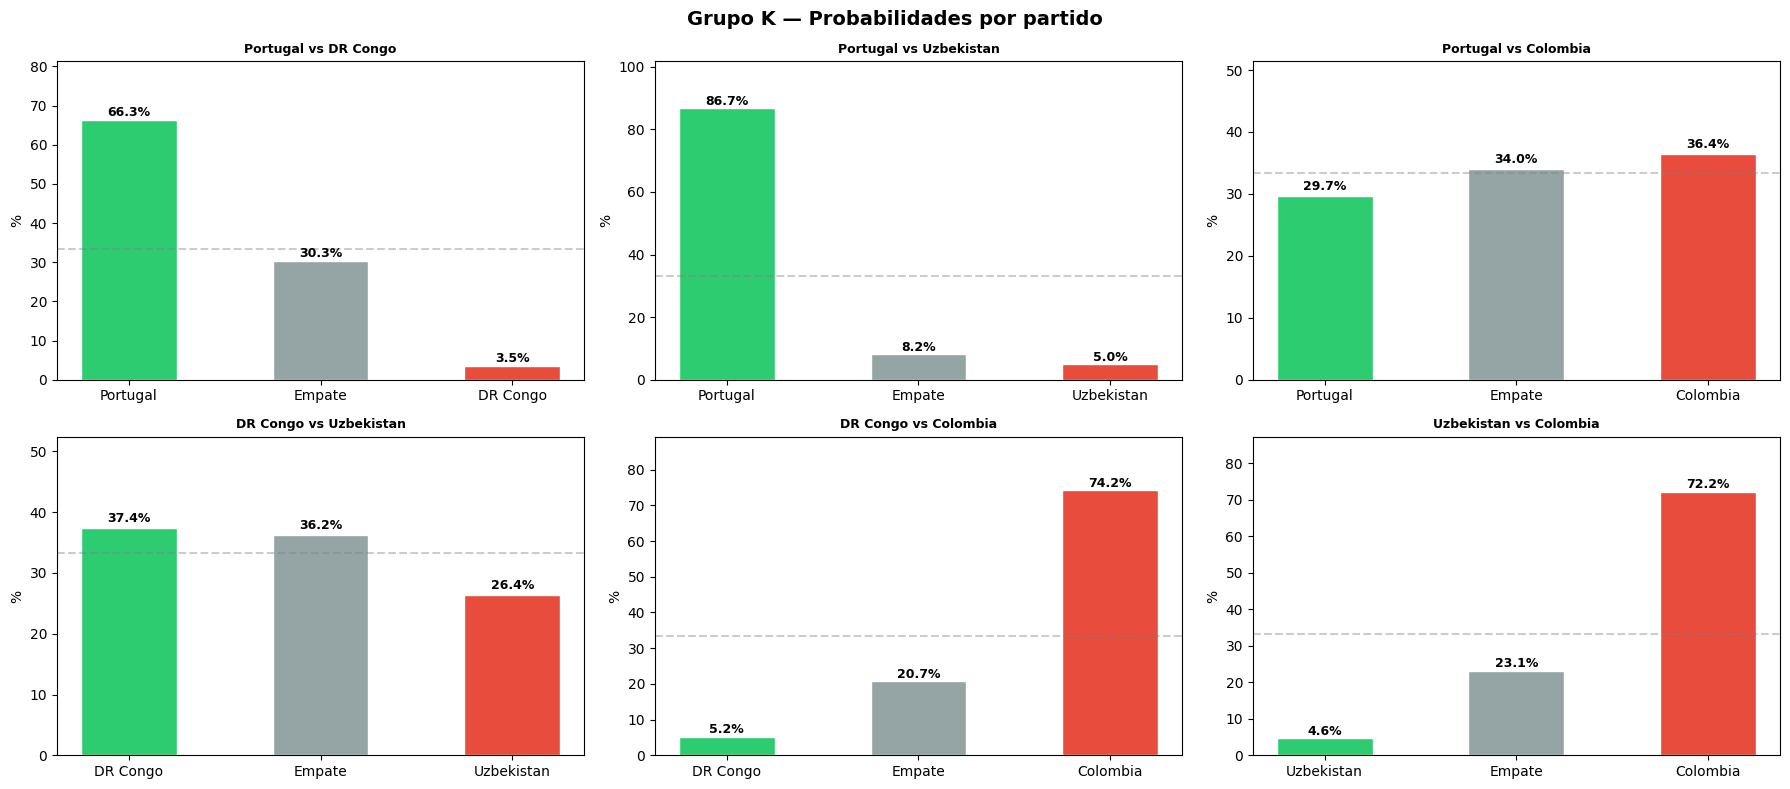

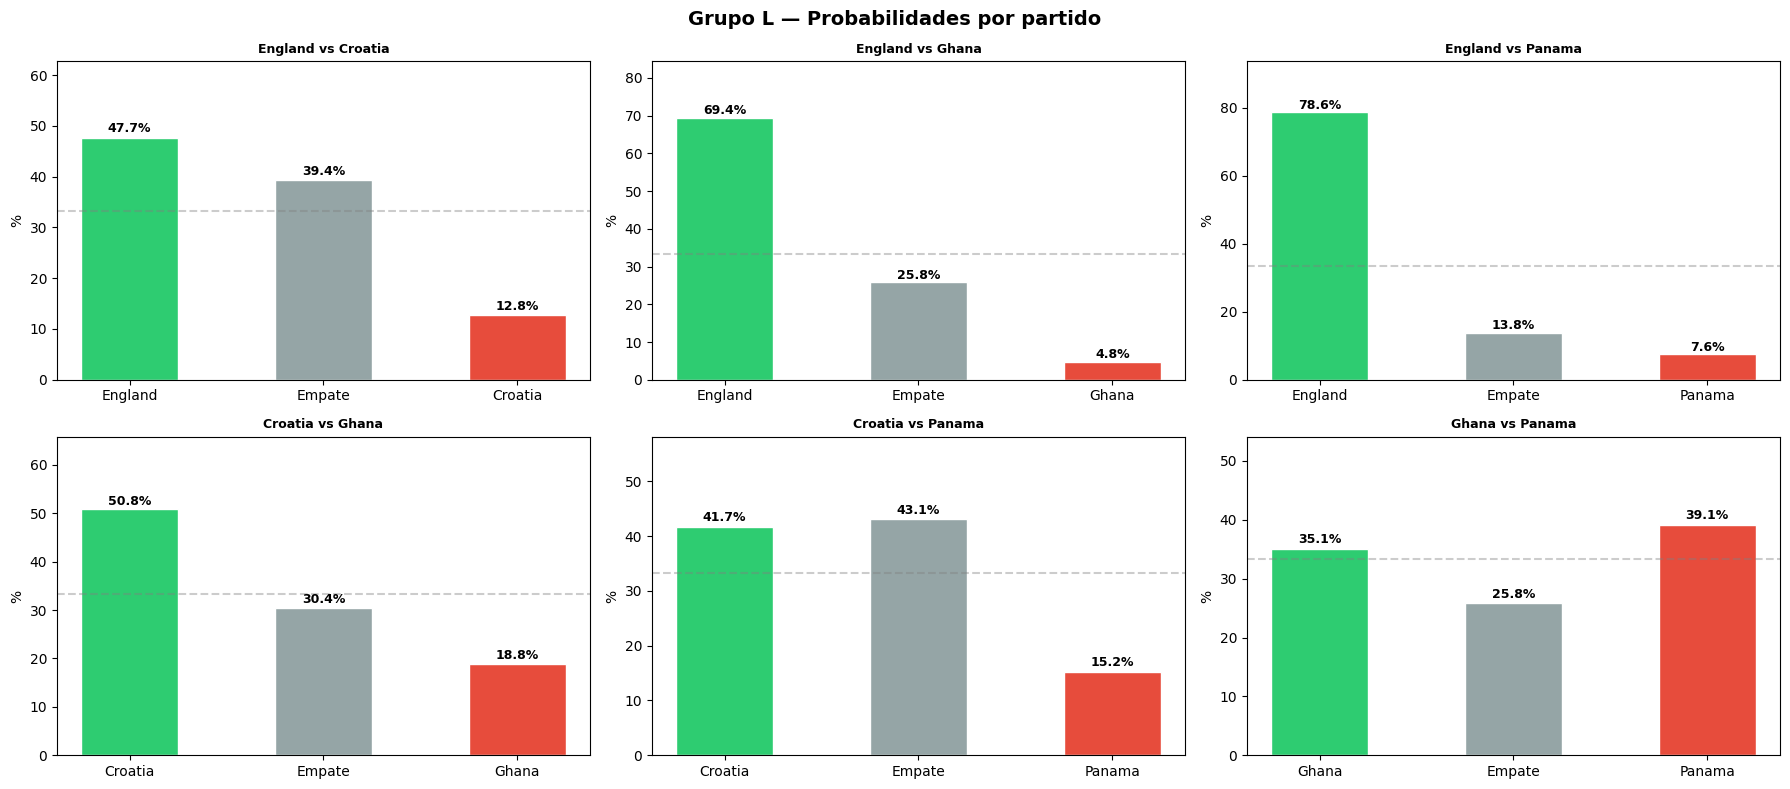

In [ ]:
# --- GRÁFICA DE TODOS LOS PARTIDOS DE TODOS LOS GRUPOS ---

# Calculamos probabilidades para todos los partidos
dfs_partidos = {}
for grupo, equipos in grupos.items():
    partidos = [(equipos[i], equipos[j])
                for i in range(len(equipos))
                for j in range(i+1, len(equipos))]
    filas = []
    for home, away in partidos:
        probs = prob_partido(home, away, modelo_bal, features_dict)
        filas.append({'home': home, 'away': away, **probs})
    dfs_partidos[grupo] = pd.DataFrame(filas)

# Una figura por grupo (12 grupos x 6 partidos)
for grupo, df_p in dfs_partidos.items():
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    fig.suptitle(f'Grupo {grupo} — Probabilidades por partido',
                 fontsize=14, fontweight='bold')
    axes = axes.flatten()

    for idx, row in df_p.iterrows():
        probs = [round(row['victoria_A'], 1), round(row['empate'], 1), round(row['victoria_B'], 1)]
        labels = [row['home'], 'Empate', row['away']]
        colores = ['#2ecc71', '#95a5a6', '#e74c3c']

        bars = axes[idx].bar(labels, probs, color=colores, edgecolor='white', width=0.5)
        axes[idx].set_title(f"{row['home']} vs {row['away']}", fontweight='bold', fontsize=9)
        axes[idx].set_ylabel('%')
        axes[idx].set_ylim(0, max(probs) + 15)  # dinámico
        axes[idx].axhline(y=33.3, color='gray', linestyle='--', alpha=0.4)

        for bar, pct in zip(bars, probs):
            axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                          f'{pct}%', ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/mundial2026', exist_ok=True)

import pickle
pickle.dump(modelo_bal,        open('/content/drive/MyDrive/mundial2026/modelo_bal.pkl','wb'))
pickle.dump(features_dict,     open('/content/drive/MyDrive/mundial2026/features_dict.pkl','wb'))
pickle.dump(elo_dict,          open('/content/drive/MyDrive/mundial2026/elo_dict.pkl','wb'))
pickle.dump(grupos,            open('/content/drive/MyDrive/mundial2026/grupos.pkl','wb'))
pickle.dump(resultados_grupos, open('/content/drive/MyDrive/mundial2026/resultados_grupos.pkl','wb'))
df_mundial.to_csv('/content/drive/MyDrive/mundial2026/df_mundial.csv', index=False)
df_train.to_csv('/content/drive/MyDrive/mundial2026/df_train.csv', index=False)

print('Todo guardado en Drive OK')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Todo guardado en Drive OK


In [ ]:
# --- TERCEROS CLASIFICADOS ---

# Extraemos el 3º de cada grupo con su % de clasificación
terceros = []
for grupo, probs in resultados_grupos.items():
    equipos_ordenados = list(probs.items())  # ya vienen ordenados por %
    tercero = equipos_ordenados[2]  # índice 2 = 3º clasificado
    terceros.append({
        'grupo': grupo,
        'equipo': tercero[0],
        'pct': tercero[1]
    })

df_terceros = pd.DataFrame(terceros).sort_values('pct', ascending=False).reset_index(drop=True)
print('=== TODOS LOS TERCEROS ===')
print(df_terceros.to_string())

# Los 8 mejores terceros que pasan
terceros_clasificados = df_terceros.head(8)
print('\n=== 8 TERCEROS QUE PASAN ===')
print(terceros_clasificados.to_string())

=== TODOS LOS TERCEROS ===
   grupo              equipo   pct
0      G                Iran  44.7
1      D           Australia  36.2
2      J             Austria  35.1
3      A      Czech Republic  33.7
4      B  Bosnia-Herzegovina  33.7
5      E             Ecuador  33.4
6      I              Norway  30.9
7      C            Scotland  24.8
8      F              Sweden  24.7
9      H        Saudi Arabia  22.0
10     L               Ghana  21.4
11     K            DR Congo  13.1

=== 8 TERCEROS QUE PASAN ===
  grupo              equipo   pct
0     G                Iran  44.7
1     D           Australia  36.2
2     J             Austria  35.1
3     A      Czech Republic  33.7
4     B  Bosnia-Herzegovina  33.7
5     E             Ecuador  33.4
6     I              Norway  30.9
7     C            Scotland  24.8


In [ ]:
# --- BRACKET DIECISEISAVOS ---

# Primeros y segundos de cada grupo
primeros = {g: list(p.items())[0][0] for g, p in resultados_grupos.items()}
segundos = {g: list(p.items())[1][0] for g, p in resultados_grupos.items()}
terceros_dict = {row['grupo']: row['equipo'] for _, row in terceros_clasificados.iterrows()}

print('Primeros:', primeros)
print('Segundos:', segundos)
print('Terceros clasificados:', terceros_dict)

Primeros: {'A': 'Mexico', 'B': 'Canada', 'C': 'Brazil', 'D': 'United States', 'E': 'Germany', 'F': 'Netherlands', 'G': 'Belgium', 'H': 'Spain', 'I': 'France', 'J': 'Argentina', 'K': 'Portugal', 'L': 'England'}
Segundos: {'A': 'South Korea', 'B': 'Switzerland', 'C': 'Morocco', 'D': 'Turkiye', 'E': 'Ivory Coast', 'F': 'Japan', 'G': 'Egypt', 'H': 'Uruguay', 'I': 'Senegal', 'J': 'Algeria', 'K': 'Colombia', 'L': 'Croatia'}
Terceros clasificados: {'G': 'Iran', 'D': 'Australia', 'J': 'Austria', 'A': 'Czech Republic', 'B': 'Bosnia-Herzegovina', 'E': 'Ecuador', 'I': 'Norway', 'C': 'Scotland'}


In [ ]:
# --- BRACKET DIECISEISAVOS ---
# Basado en el calendario oficial que proporcionaste

# Los partidos con 3º dependen de qué grupos clasificaron terceros
# Usamos los 8 mejores terceros que tenemos

dieciseisavos = [
    # Partido 73
    (segundos['A'], segundos['B']),
    # Partido 74
    (primeros['E'], terceros_dict.get('A') or terceros_dict.get('B')),
    # Partido 75
    (primeros['F'], segundos['C']),
    # Partido 76
    (primeros['E'], segundos['F']),
    # Partido 77
    (primeros['I'], terceros_dict.get('C') or terceros_dict.get('D')),
    # Partido 78
    (segundos['E'], segundos['I']),
    # Partido 79
    (primeros['A'], terceros_dict.get('C') or terceros_dict.get('E')),
    # Partido 80
    (primeros['L'], terceros_dict.get('E') or terceros_dict.get('H')),
    # Partido 81
    (primeros['D'], terceros_dict.get('B') or terceros_dict.get('E')),
    # Partido 82
    (primeros['G'], terceros_dict.get('A') or terceros_dict.get('E')),
    # Partido 83
    (segundos['K'], segundos['L']),
    # Partido 84
    (primeros['H'], segundos['J']),
    # Partido 85
    (primeros['B'], terceros_dict.get('E') or terceros_dict.get('F')),
    # Partido 86
    (primeros['J'], segundos['H']),
    # Partido 87
    (primeros['K'], terceros_dict.get('D') or terceros_dict.get('E')),
    # Partido 88
    (segundos['D'], segundos['G']),
]

print('=== DIECISEISAVOS ===')
for i, (home, away) in enumerate(dieciseisavos):
    print(f'Partido {73+i}: {home} vs {away}')

=== DIECISEISAVOS ===
Partido 73: South Korea vs Switzerland
Partido 74: Germany vs Czech Republic
Partido 75: Netherlands vs Morocco
Partido 76: Germany vs Japan
Partido 77: France vs Scotland
Partido 78: Ivory Coast vs Senegal
Partido 79: Mexico vs Scotland
Partido 80: England vs Ecuador
Partido 81: United States vs Bosnia-Herzegovina
Partido 82: Belgium vs Czech Republic
Partido 83: Colombia vs Croatia
Partido 84: Spain vs Algeria
Partido 85: Canada vs Ecuador
Partido 86: Argentina vs Uruguay
Partido 87: Portugal vs Australia
Partido 88: Turkiye vs Egypt


In [ ]:
import random

# Partidos que necesitan un tercero y de qué grupos puede venir
partidos_con_tercero = {
    74: ['A','B','C','D','F'],
    77: ['C','D','F','G','H'],
    79: ['C','E','F','H','I'],
    80: ['E','H','I','J','K'],
    81: ['B','E','F','I','J'],
    82: ['A','E','H','I','J'],
    85: ['E','F','G','I','J'],
    87: ['D','E','I','J','L'],
}

# Terceros disponibles por grupo
terceros_disponibles = dict(terceros_dict)  # copia

# Asignamos aleatoriamente sin repetir
asignacion_terceros = {}
for partido, grupos_posibles in partidos_con_tercero.items():
    # Filtramos terceros disponibles que vienen de los grupos posibles
    candidatos = {g: eq for g, eq in terceros_disponibles.items() if g in grupos_posibles}
    if candidatos:
        grupo_elegido = random.choice(list(candidatos.keys()))
        asignacion_terceros[partido] = terceros_disponibles.pop(grupo_elegido)
    else:
        asignacion_terceros[partido] = 'TBD'

print('Asignación de terceros:')
for partido, equipo in asignacion_terceros.items():
    print(f'  Partido {partido}: {equipo}')

Asignación de terceros:
  Partido 74: Scotland
  Partido 77: Iran
  Partido 79: Norway
  Partido 80: Austria
  Partido 81: Bosnia-Herzegovina
  Partido 82: Czech Republic
  Partido 85: Ecuador
  Partido 87: Australia


In [ ]:
# --- BRACKET DIECISEISAVOS DEFINITIVO ---
dieciseisavos = [
    ('South Korea',    'Switzerland'),           # P73
    ('Germany',        asignacion_terceros[74]), # P74
    ('Netherlands',    'Morocco'),               # P75
    ('Netherlands',    'Japan'),                 # P76
    ('France',         asignacion_terceros[77]), # P77
    ('Ivory Coast',    'Senegal'),               # P78
    ('Mexico',         asignacion_terceros[79]), # P79
    ('England',        asignacion_terceros[80]), # P80
    ('United States',  asignacion_terceros[81]), # P81
    ('Belgium',        asignacion_terceros[82]), # P82
    ('Colombia',       'Croatia'),               # P83
    ('Spain',          'Algeria'),               # P84
    ('Canada',         asignacion_terceros[85]), # P85
    ('Argentina',      'Uruguay'),               # P86
    ('Portugal',       asignacion_terceros[87]), # P87
    ('Turkiye',        'Egypt'),                 # P88
]

print('=== DIECISEISAVOS ===')
for i, (home, away) in enumerate(dieciseisavos):
    print(f'Partido {73+i}: {home} vs {away}')

=== DIECISEISAVOS ===
Partido 73: South Korea vs Switzerland
Partido 74: Germany vs Scotland
Partido 75: Netherlands vs Morocco
Partido 76: Netherlands vs Japan
Partido 77: France vs Iran
Partido 78: Ivory Coast vs Senegal
Partido 79: Mexico vs Norway
Partido 80: England vs Austria
Partido 81: United States vs Bosnia-Herzegovina
Partido 82: Belgium vs Czech Republic
Partido 83: Colombia vs Croatia
Partido 84: Spain vs Algeria
Partido 85: Canada vs Ecuador
Partido 86: Argentina vs Uruguay
Partido 87: Portugal vs Australia
Partido 88: Turkiye vs Egypt


In [ ]:
dieciseisavos = [
    ('South Korea',    'Switzerland'),           # P73 — 2ºA vs 2ºB
    ('Germany',        asignacion_terceros[74]), # P74 — 1ºE vs 3º
    ('Netherlands',    'Morocco'),               # P75 — 1ºF vs 2ºC
    ('Brazil',         'Japan'),                 # P76 — 1ºC vs 2ºF
    ('France',         asignacion_terceros[77]), # P77 — 1ºI vs 3º
    ('Ivory Coast',    'Senegal'),               # P78 — 2ºE vs 2ºI
    ('Mexico',         asignacion_terceros[79]), # P79 — 1ºA vs 3º
    ('England',        asignacion_terceros[80]), # P80 — 1ºL vs 3º
    ('United States',  asignacion_terceros[81]), # P81 — 1ºD vs 3º
    ('Belgium',        asignacion_terceros[82]), # P82 — 1ºG vs 3º
    ('Colombia',       'Croatia'),               # P83 — 2ºK vs 2ºL
    ('Spain',          'Algeria'),               # P84 — 1ºH vs 2ºJ
    ('Canada',         asignacion_terceros[85]), # P85 — 1ºB vs 3º
    ('Argentina',      'Uruguay'),               # P86 — 1ºJ vs 2ºH
    ('Portugal',       asignacion_terceros[87]), # P87 — 1ºK vs 3º
    ('Turkiye',        'Egypt'),                 # P88 — 2ºD vs 2ºG
]

print('=== DIECISEISAVOS ===')
for i, (home, away) in enumerate(dieciseisavos):
    print(f'Partido {73+i}: {home} vs {away}')

todos = [e for partido in dieciseisavos for e in partido]
from collections import Counter
repetidos = [e for e, c in Counter(todos).items() if c > 1]
print(f'\nRepetidos: {repetidos if repetidos else "Ninguno ✅"}')

=== DIECISEISAVOS ===
Partido 73: South Korea vs Switzerland
Partido 74: Germany vs Scotland
Partido 75: Netherlands vs Morocco
Partido 76: Brazil vs Japan
Partido 77: France vs Iran
Partido 78: Ivory Coast vs Senegal
Partido 79: Mexico vs Norway
Partido 80: England vs Austria
Partido 81: United States vs Bosnia-Herzegovina
Partido 82: Belgium vs Czech Republic
Partido 83: Colombia vs Croatia
Partido 84: Spain vs Algeria
Partido 85: Canada vs Ecuador
Partido 86: Argentina vs Uruguay
Partido 87: Portugal vs Australia
Partido 88: Turkiye vs Egypt

Repetidos: Ninguno ✅


In [ ]:
# --- SIMULADOR ELIMINATORIA (sin empates) ---
def simular_eliminatoria(equipo_a, equipo_b, modelo, features_dict):
    fa = features_dict.get(equipo_a, {k: 0.5 for k in feature_cols})
    fb = features_dict.get(equipo_b, {k: 0.5 for k in feature_cols})

    X = np.array([[
        fa['ELO_norm']             - fb['ELO_norm'],
        fa['Log_MarketValue']      - fb['Log_MarketValue'],
        fa['Momentum_15']          - fb['Momentum_15'],
        fa['Knockout_Performance'] - fb['Knockout_Performance'],
        fa['Pressure_Index']       - fb['Pressure_Index'],
    ]])

    probs = modelo.predict_proba(X)[0]
    p_derrota, p_empate, p_victoria = probs[0], probs[1], probs[2]

    # En eliminatoria el empate se reparte entre los dos
    p_a = p_victoria + p_empate / 2
    p_b = p_derrota + p_empate / 2

    # Normalizamos
    total = p_a + p_b
    p_a, p_b = p_a / total, p_b / total

    return equipo_a if random.random() < p_a else equipo_b

# --- MCTS DIECISEISAVOS ---
def mcts_eliminatoria(partidos, modelo, features_dict, n_simulaciones=10000):
    conteo = {e: 0 for partido in partidos for e in partido}

    for _ in range(n_simulaciones):
        for home, away in partidos:
            ganador = simular_eliminatoria(home, away, modelo, features_dict)
            conteo[ganador] += 1

    probabilidades = {e: round(conteo[e] / n_simulaciones * 100, 1)
                      for e in conteo}
    return dict(sorted(probabilidades.items(), key=lambda x: x[1], reverse=True))

# Simulamos
print('Simulando dieciseisavos...')
resultados_dieciseisavos = mcts_eliminatoria(dieciseisavos, modelo_bal, features_dict)
print('Completado')

# Mostramos resultados
print('\n=== % CLASIFICACIÓN A OCTAVOS ===')
for equipo, pct in resultados_dieciseisavos.items():
    print(f'{equipo}: {pct}%')

Simulando dieciseisavos...
Completado

=== % CLASIFICACIÓN A OCTAVOS ===
France: 89.6%
Germany: 78.3%
Belgium: 78.1%
Spain: 76.3%
Brazil: 70.7%
United States: 70.6%
Portugal: 69.3%
Argentina: 68.8%
England: 65.6%
Ecuador: 62.0%
Colombia: 57.7%
Netherlands: 56.6%
Turkiye: 55.2%
Senegal: 54.8%
South Korea: 52.8%
Mexico: 51.9%
Norway: 48.0%
Switzerland: 47.2%
Ivory Coast: 45.2%
Egypt: 44.8%
Morocco: 43.4%
Croatia: 42.3%
Canada: 38.0%
Austria: 34.4%
Uruguay: 31.2%
Australia: 30.7%
Bosnia-Herzegovina: 29.4%
Japan: 29.3%
Algeria: 23.7%
Czech Republic: 21.9%
Scotland: 21.7%
Iran: 10.4%


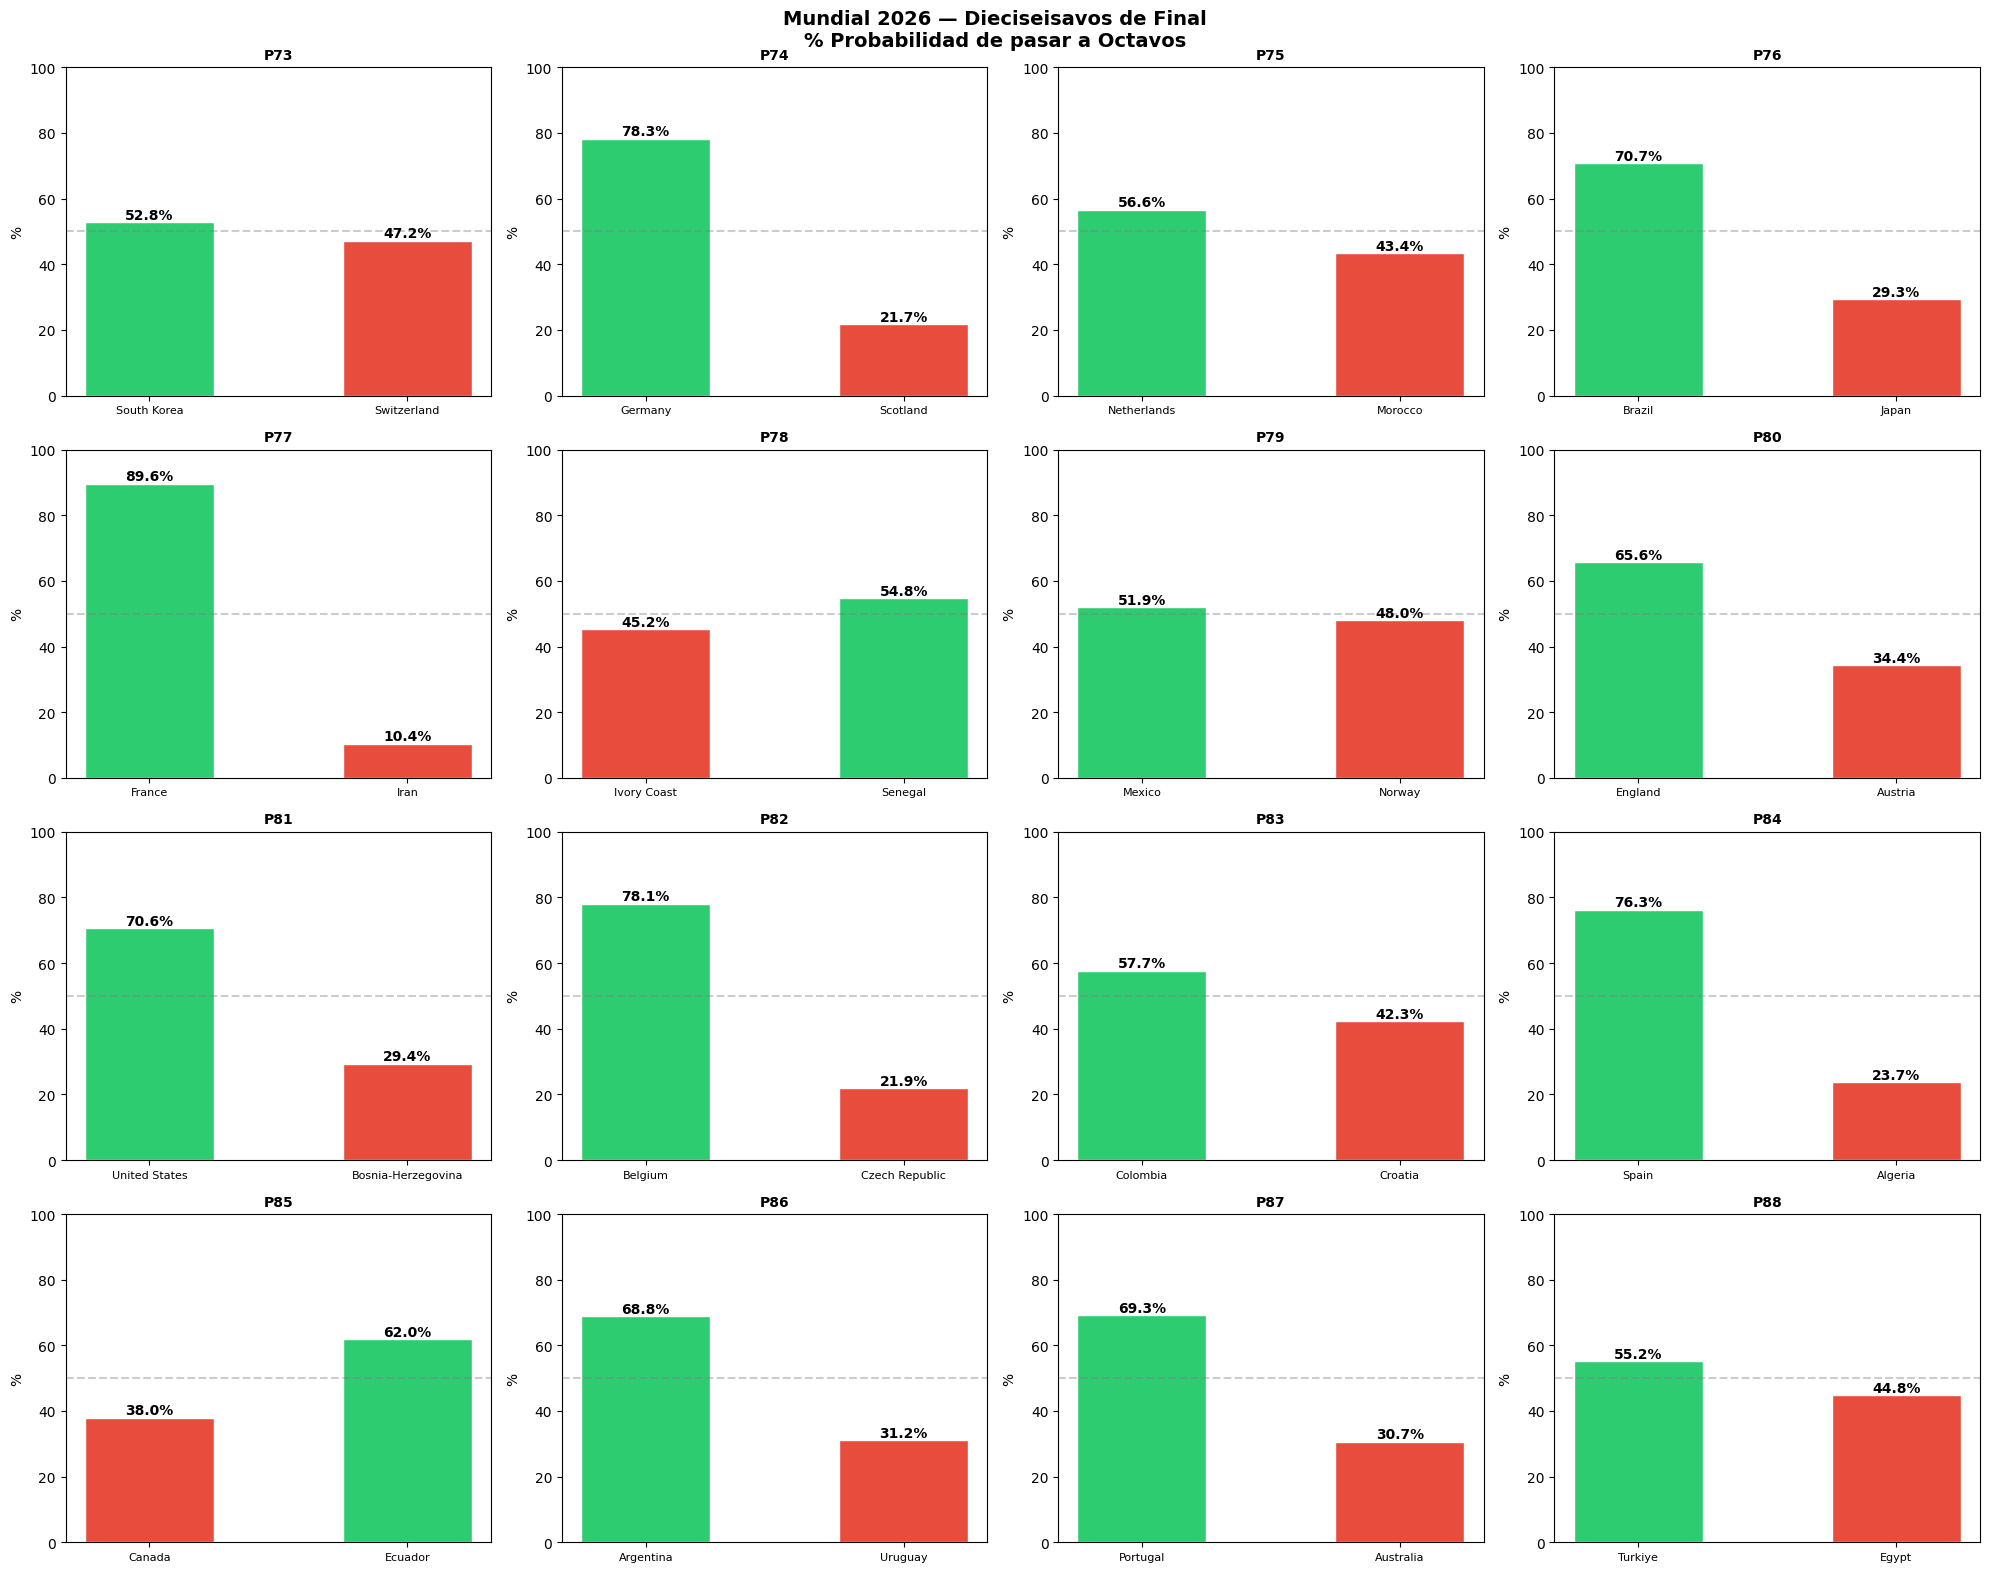

In [ ]:
# --- GRÁFICA DIECISEISAVOS ---
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('Mundial 2026 — Dieciseisavos de Final\n% Probabilidad de pasar a Octavos',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, (home, away) in enumerate(dieciseisavos):
    p_home = resultados_dieciseisavos[home]
    p_away = resultados_dieciseisavos[away]

    equipos = [home, away]
    pcts = [p_home, p_away]
    colores = ['#2ecc71' if p_home > p_away else '#e74c3c',
               '#2ecc71' if p_away > p_home else '#e74c3c']

    bars = axes[idx].bar(equipos, pcts, color=colores, edgecolor='white', width=0.5)
    axes[idx].set_title(f'P{73+idx}', fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('%')
    axes[idx].set_ylim(0, 100)
    axes[idx].axhline(y=50, color='gray', linestyle='--', alpha=0.4)
    axes[idx].tick_params(axis='x', labelsize=8)

    for bar, pct in zip(bars, pcts):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                      f'{pct}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# --- SIMULAMOS QUIÉN PASA DE DIECISEISAVOS ---
def simular_fase(partidos, modelo, features_dict, n_simulaciones=10000):
    conteo_pase = {e: 0 for partido in partidos for e in partido}

    for _ in range(n_simulaciones):
        for home, away in partidos:
            ganador = simular_eliminatoria(home, away, modelo, features_dict)
            conteo_pase[ganador] += 1

    return {e: round(conteo_pase[e] / n_simulaciones * 100, 1) for e in conteo_pase}

pase_dieciseisavos = simular_fase(dieciseisavos, modelo_bal, features_dict)

# Clasificados más probables de cada partido
print('=== CLASIFICADOS A OCTAVOS (más probable) ===\n')
octavos = []
for i, (home, away) in enumerate(dieciseisavos):
    p_home = pase_dieciseisavos[home]
    p_away = pase_dieciseisavos[away]
    ganador = home if p_home > p_away else away
    perdedor = away if p_home > p_away else home
    octavos.append(ganador)
    print(f'P{73+i}: {ganador} ({max(p_home,p_away)}%) elimina a {perdedor} ({min(p_home,p_away)}%)')

=== CLASIFICADOS A OCTAVOS (más probable) ===

P73: South Korea (51.2%) elimina a Switzerland (48.8%)
P74: Germany (78.3%) elimina a Scotland (21.7%)
P75: Netherlands (56.7%) elimina a Morocco (43.3%)
P76: Brazil (69.0%) elimina a Japan (31.0%)
P77: France (89.5%) elimina a Iran (10.5%)
P78: Senegal (54.5%) elimina a Ivory Coast (45.5%)
P79: Mexico (52.4%) elimina a Norway (47.6%)
P80: England (66.3%) elimina a Austria (33.7%)
P81: United States (71.0%) elimina a Bosnia-Herzegovina (29.0%)
P82: Belgium (77.6%) elimina a Czech Republic (22.4%)
P83: Colombia (57.0%) elimina a Croatia (43.0%)
P84: Spain (76.3%) elimina a Algeria (23.7%)
P85: Ecuador (62.2%) elimina a Canada (37.8%)
P86: Argentina (68.0%) elimina a Uruguay (32.0%)
P87: Portugal (70.1%) elimina a Australia (29.9%)
P88: Turkiye (53.8%) elimina a Egypt (46.2%)


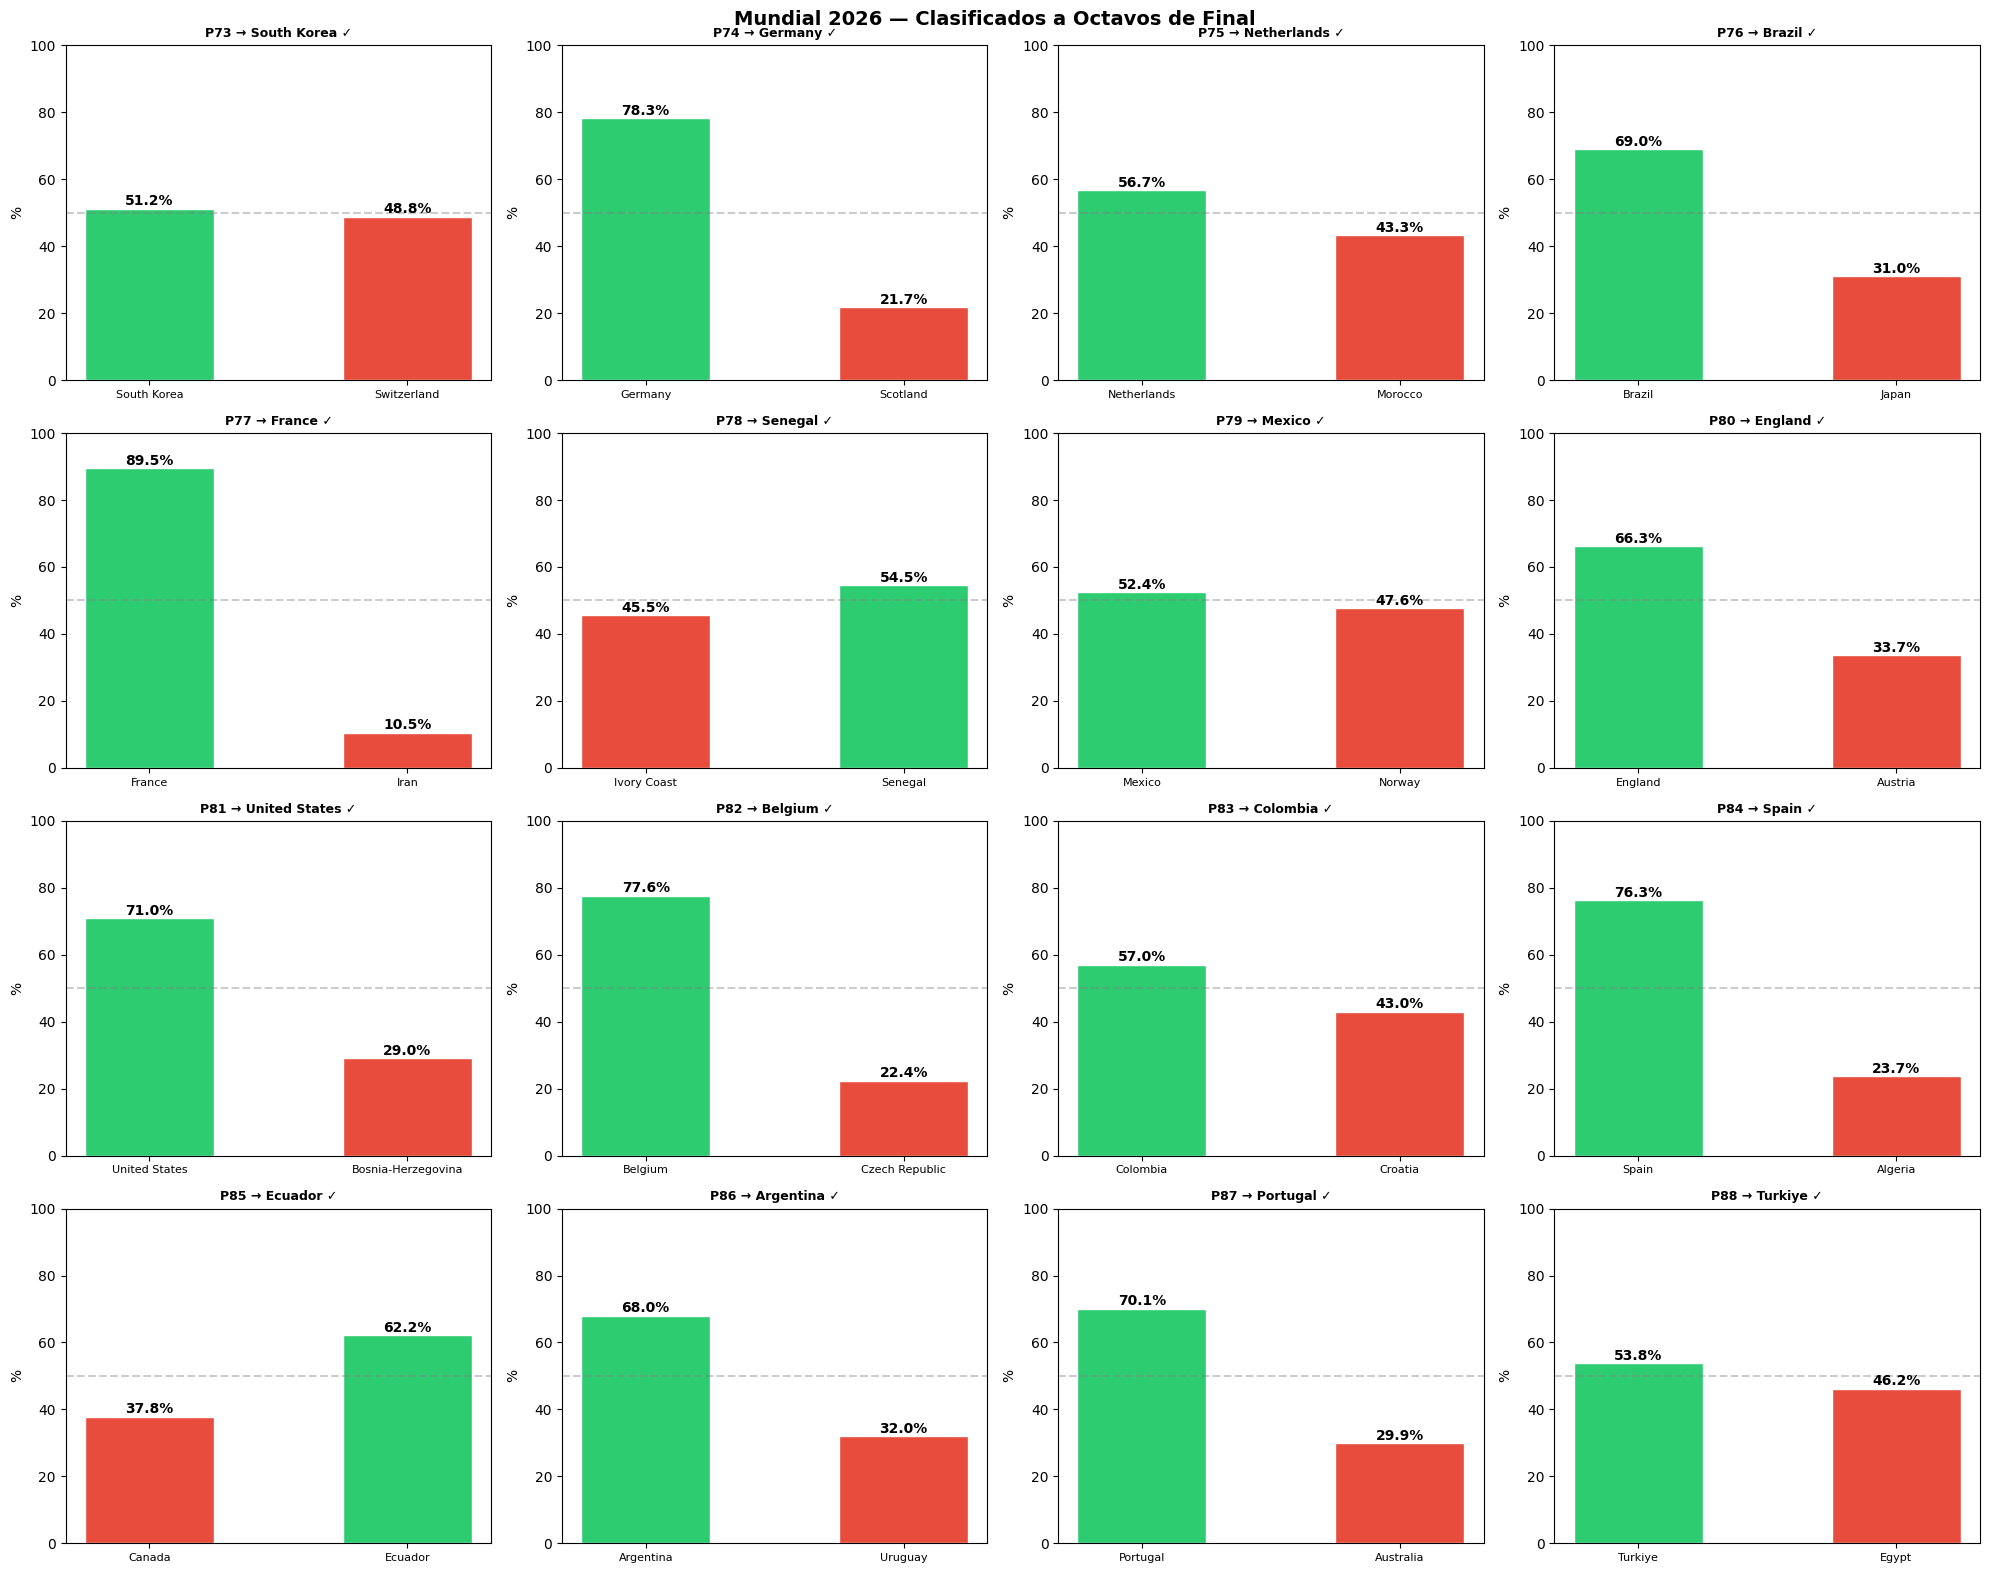


=== 16 CLASIFICADOS A OCTAVOS ===
1. South Korea
2. Germany
3. Netherlands
4. Brazil
5. France
6. Senegal
7. Mexico
8. England
9. United States
10. Belgium
11. Colombia
12. Spain
13. Ecuador
14. Argentina
15. Portugal
16. Turkiye


In [ ]:
# --- GRÁFICA CLASIFICADOS A OCTAVOS ---
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('Mundial 2026 — Clasificados a Octavos de Final',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, (home, away) in enumerate(dieciseisavos):
    p_home = pase_dieciseisavos[home]
    p_away = pase_dieciseisavos[away]
    ganador = home if p_home > p_away else away

    equipos = [home, away]
    pcts = [p_home, p_away]
    colores = ['#2ecc71' if e == ganador else '#e74c3c' for e in equipos]

    bars = axes[idx].bar(equipos, pcts, color=colores, edgecolor='white', width=0.5)
    axes[idx].set_title(f'P{73+idx} → {ganador} ✓', fontweight='bold', fontsize=9)
    axes[idx].set_ylabel('%')
    axes[idx].set_ylim(0, 100)
    axes[idx].axhline(y=50, color='gray', linestyle='--', alpha=0.4)
    axes[idx].tick_params(axis='x', labelsize=8)

    for bar, pct in zip(bars, pcts):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                      f'{pct}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== 16 CLASIFICADOS A OCTAVOS ===')
for i, eq in enumerate(octavos):
    print(f'{i+1}. {eq}')

In [ ]:
# --- OCTAVOS DE FINAL ---
octavos_partidos = [
    (octavos[1],  octavos[4]),   # P89 — G74 vs G77 — Germany vs France
    (octavos[0],  octavos[2]),   # P90 — G73 vs G75 — South Korea vs Netherlands
    (octavos[3],  octavos[5]),   # P91 — G76 vs G78 — Brazil vs Senegal
    (octavos[6],  octavos[7]),   # P92 — G79 vs G80 — Sweden vs England
    (octavos[10], octavos[11]),  # P93 — G83 vs G84 — Colombia vs Spain
    (octavos[8],  octavos[9]),   # P94 — G81 vs G82 — United States vs Belgium
    (octavos[13], octavos[15]),  # P95 — G86 vs G88 — Argentina vs Turkiye
    (octavos[12], octavos[14]),  # P96 — G85 vs G87 — Canada vs Portugal
]

print('=== OCTAVOS DE FINAL ===')
for i, (home, away) in enumerate(octavos_partidos):
    print(f'P{89+i}: {home} vs {away}')

=== OCTAVOS DE FINAL ===
P89: Germany vs France
P90: South Korea vs Netherlands
P91: Brazil vs Senegal
P92: Mexico vs England
P93: Colombia vs Spain
P94: United States vs Belgium
P95: Argentina vs Turkiye
P96: Ecuador vs Portugal


In [ ]:
# --- SIMULAMOS OCTAVOS ---
pase_octavos = simular_fase(octavos_partidos, modelo_bal, features_dict)

cuartos = []
for i, (home, away) in enumerate(octavos_partidos):
    p_home = pase_octavos[home]
    p_away = pase_octavos[away]
    ganador = home if p_home > p_away else away
    perdedor = away if p_home > p_away else home
    cuartos.append(ganador)
    print(f'P{89+i}: {ganador} ({max(p_home,p_away)}%) elimina a {perdedor} ({min(p_home,p_away)}%)')

P89: France (57.7%) elimina a Germany (42.3%)
P90: Netherlands (64.1%) elimina a South Korea (35.9%)
P91: Brazil (64.9%) elimina a Senegal (35.1%)
P92: England (65.0%) elimina a Mexico (35.0%)
P93: Spain (64.6%) elimina a Colombia (35.4%)
P94: Belgium (60.9%) elimina a United States (39.1%)
P95: Argentina (67.0%) elimina a Turkiye (33.0%)
P96: Portugal (70.2%) elimina a Ecuador (29.8%)


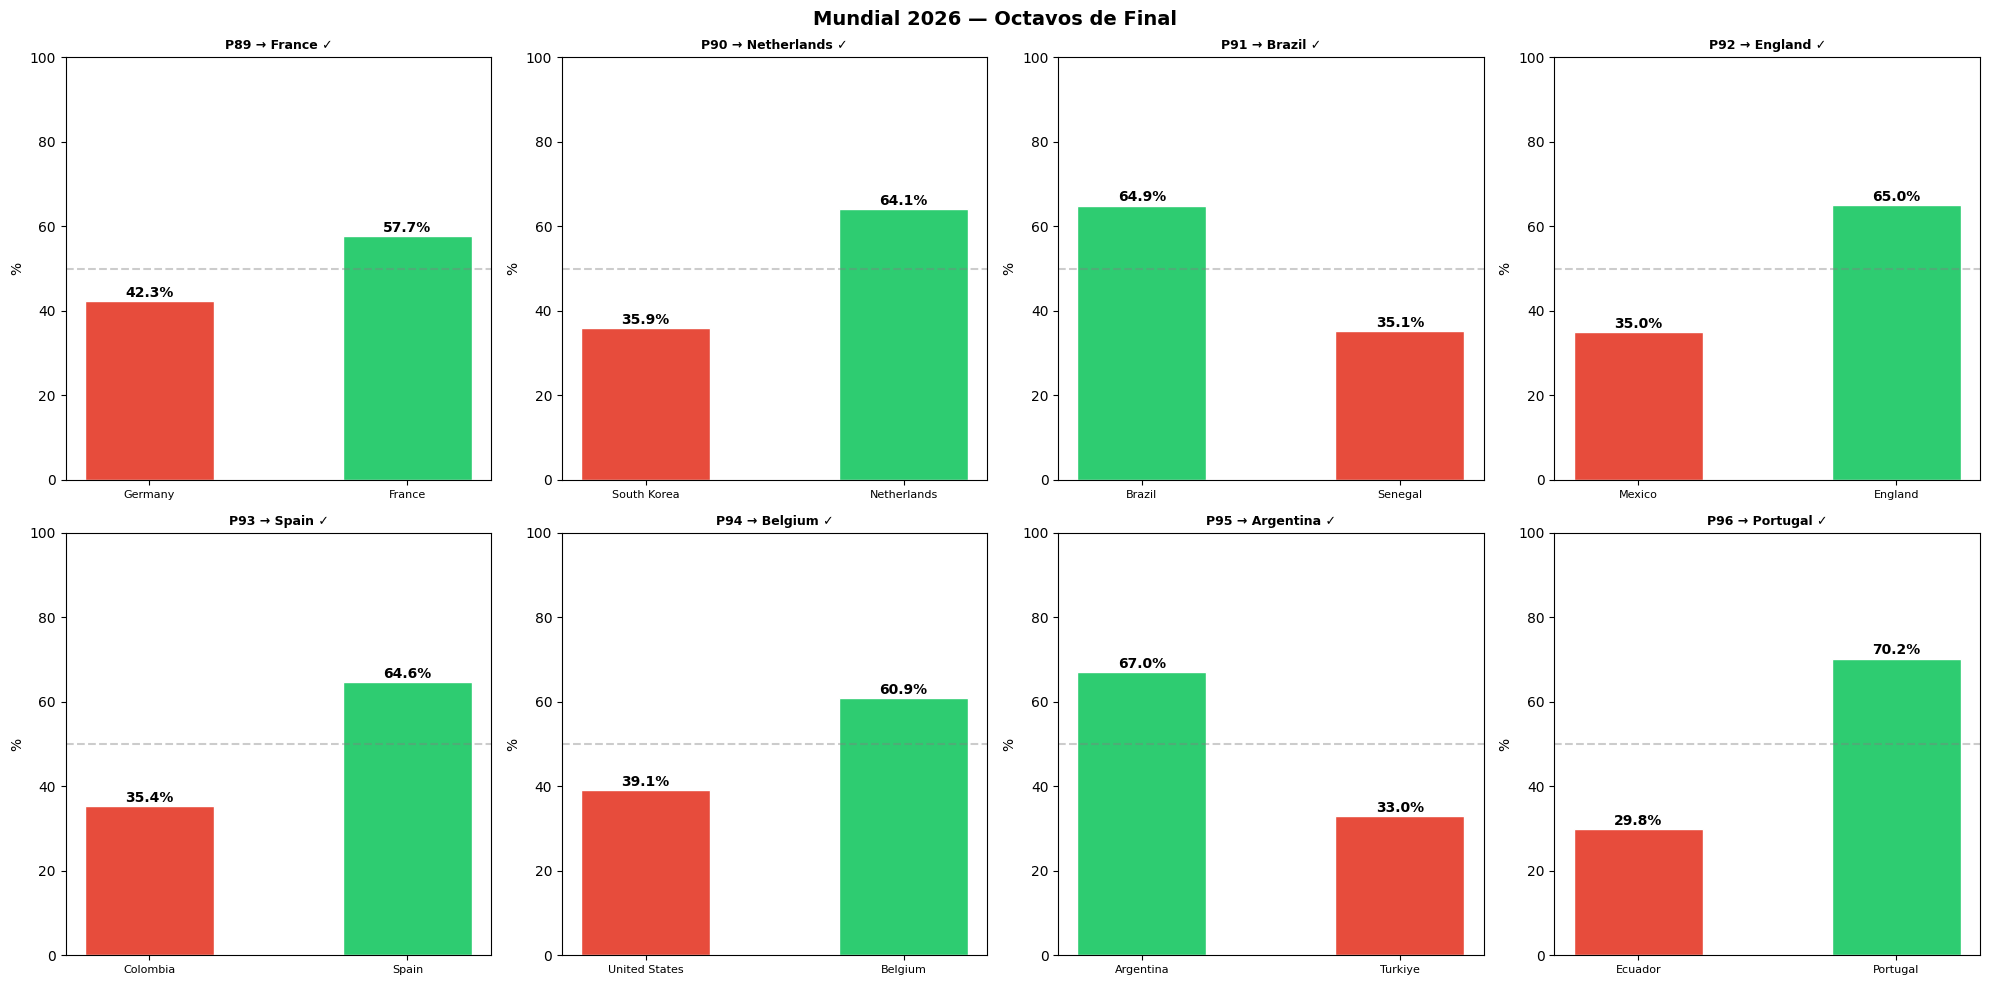


=== 8 CLASIFICADOS A CUARTOS ===
1. France
2. Netherlands
3. Brazil
4. England
5. Spain
6. Belgium
7. Argentina
8. Portugal


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Mundial 2026 — Octavos de Final', fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, (home, away) in enumerate(octavos_partidos):
    p_home = pase_octavos[home]
    p_away = pase_octavos[away]
    ganador = home if p_home > p_away else away

    equipos = [home, away]
    pcts = [p_home, p_away]
    colores = ['#2ecc71' if e == ganador else '#e74c3c' for e in equipos]

    bars = axes[idx].bar(equipos, pcts, color=colores, edgecolor='white', width=0.5)
    axes[idx].set_title(f'P{89+idx} → {ganador} ✓', fontweight='bold', fontsize=9)
    axes[idx].set_ylabel('%')
    axes[idx].set_ylim(0, 100)
    axes[idx].axhline(y=50, color='gray', linestyle='--', alpha=0.4)
    axes[idx].tick_params(axis='x', labelsize=8)

    for bar, pct in zip(bars, pcts):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                      f'{pct}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== 8 CLASIFICADOS A CUARTOS ===')
for i, eq in enumerate(cuartos):
    print(f'{i+1}. {eq}')

In [ ]:
# --- CUARTOS DE FINAL ---
cuartos_partidos = [
    (cuartos[0], cuartos[1]),  # P97 — France vs Netherlands
    (cuartos[4], cuartos[5]),  # P98 — Spain vs Belgium
    (cuartos[2], cuartos[3]),  # P99 — Brazil vs England
    (cuartos[6], cuartos[7]),  # P100 — Argentina vs Portugal
]

print('=== CUARTOS DE FINAL ===')
for i, (home, away) in enumerate(cuartos_partidos):
    print(f'P{97+i}: {home} vs {away}')

# --- SIMULAMOS ---
pase_cuartos = simular_fase(cuartos_partidos, modelo_bal, features_dict)

semifinales = []
for i, (home, away) in enumerate(cuartos_partidos):
    p_home = pase_cuartos[home]
    p_away = pase_cuartos[away]
    ganador = home if p_home > p_away else away
    perdedor = away if p_home > p_away else home
    semifinales.append(ganador)
    print(f'P{97+i}: {ganador} ({max(p_home,p_away)}%) elimina a {perdedor} ({min(p_home,p_away)}%)')

=== CUARTOS DE FINAL ===
P97: France vs Netherlands
P98: Spain vs Belgium
P99: Brazil vs England
P100: Argentina vs Portugal
P97: France (62.8%) elimina a Netherlands (37.2%)
P98: Spain (76.9%) elimina a Belgium (23.1%)
P99: Brazil (54.0%) elimina a England (46.0%)
P100: Argentina (62.7%) elimina a Portugal (37.3%)


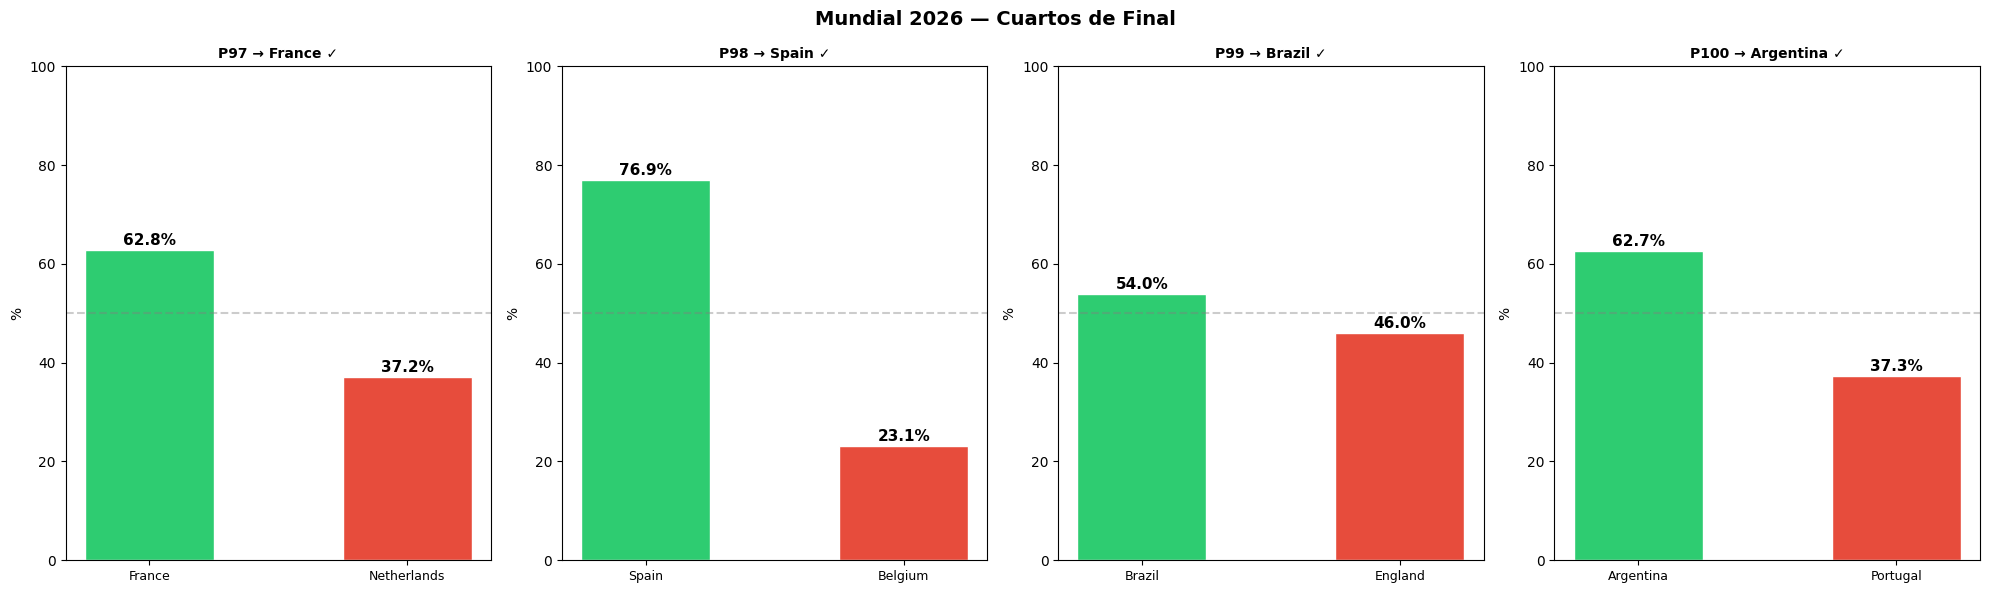


=== 4 SEMIFINALISTAS ===
1. France
2. Spain
3. Brazil
4. Argentina


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Mundial 2026 — Cuartos de Final', fontsize=14, fontweight='bold')

for idx, (home, away) in enumerate(cuartos_partidos):
    p_home = pase_cuartos[home]
    p_away = pase_cuartos[away]
    ganador = home if p_home > p_away else away

    equipos = [home, away]
    pcts = [p_home, p_away]
    colores = ['#2ecc71' if e == ganador else '#e74c3c' for e in equipos]

    bars = axes[idx].bar(equipos, pcts, color=colores, edgecolor='white', width=0.5)
    axes[idx].set_title(f'P{97+idx} → {ganador} ✓', fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('%')
    axes[idx].set_ylim(0, 100)
    axes[idx].axhline(y=50, color='gray', linestyle='--', alpha=0.4)
    axes[idx].tick_params(axis='x', labelsize=9)

    for bar, pct in zip(bars, pcts):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                      f'{pct}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== 4 SEMIFINALISTAS ===')
for i, eq in enumerate(semifinales):
    print(f'{i+1}. {eq}')

In [ ]:
# --- SEMIFINALES ---
semifinales_partidos = [
    (semifinales[0], semifinales[1]),  # P101 — France vs Spain
    (semifinales[2], semifinales[3]),  # P102 — Brazil vs Argentina
]

print('=== SEMIFINALES ===')
for i, (home, away) in enumerate(semifinales_partidos):
    print(f'P{101+i}: {home} vs {away}')

# --- SIMULAMOS ---
pase_semifinales = simular_fase(semifinales_partidos, modelo_bal, features_dict)

finalistas = []
for i, (home, away) in enumerate(semifinales_partidos):
    p_home = pase_semifinales[home]
    p_away = pase_semifinales[away]
    ganador = home if p_home > p_away else away
    perdedor = away if p_home > p_away else home
    finalistas.append(ganador)
    print(f'P{101+i}: {ganador} ({max(p_home,p_away)}%) elimina a {perdedor} ({min(p_home,p_away)}%)')


=== SEMIFINALES ===
P101: France vs Spain
P102: Brazil vs Argentina
P101: Spain (55.8%) elimina a France (44.2%)
P102: Argentina (54.2%) elimina a Brazil (45.8%)


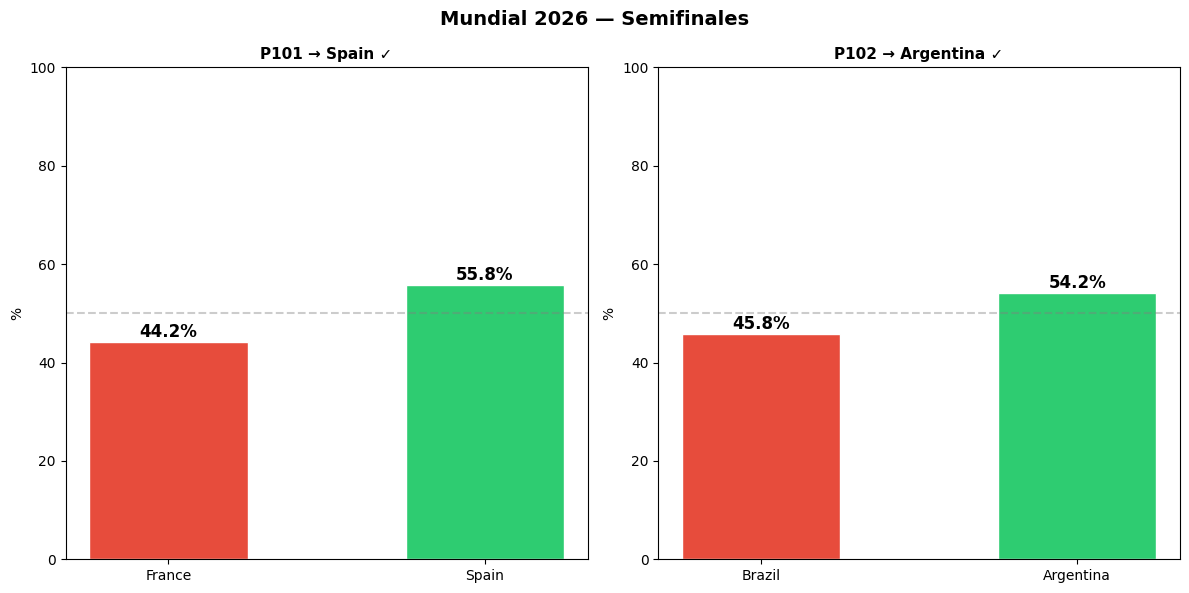


=== FINALISTAS ===
1. Spain
2. Argentina


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Mundial 2026 — Semifinales', fontsize=14, fontweight='bold')

for idx, (home, away) in enumerate(semifinales_partidos):
    p_home = pase_semifinales[home]
    p_away = pase_semifinales[away]
    ganador = home if p_home > p_away else away

    equipos = [home, away]
    pcts = [p_home, p_away]
    colores = ['#2ecc71' if e == ganador else '#e74c3c' for e in equipos]

    bars = axes[idx].bar(equipos, pcts, color=colores, edgecolor='white', width=0.5)
    axes[idx].set_title(f'P{101+idx} → {ganador} ✓', fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('%')
    axes[idx].set_ylim(0, 100)
    axes[idx].axhline(y=50, color='gray', linestyle='--', alpha=0.4)
    axes[idx].tick_params(axis='x', labelsize=10)

    for bar, pct in zip(bars, pcts):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                      f'{pct}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== FINALISTAS ===')
for i, eq in enumerate(finalistas):
    print(f'{i+1}. {eq}')

In [ ]:
final = (finalistas[0], finalistas[1])  # Spain vs Argentina

print(f'=== FINAL MUNDIAL 2026 ===')
print(f'{final[0]} vs {final[1]}')

# Simulamos
pase_final = simular_fase([final], modelo_bal, features_dict)

p_home = pase_final[final[0]]
p_away = pase_final[final[1]]
campeon = final[0] if p_home > p_away else final[1]

print(f'\n{final[0]}: {p_home}%')
print(f'{final[1]}: {p_away}%')
print(f'\n🏆 CAMPEÓN: {campeon}')

=== FINAL MUNDIAL 2026 ===
Spain vs Argentina

Spain: 48.0%
Argentina: 52.0%

🏆 CAMPEÓN: Argentina


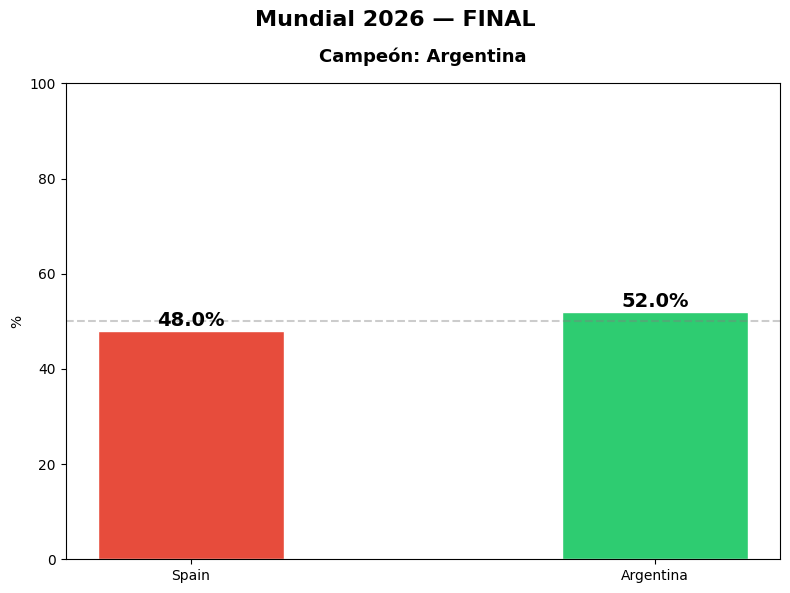

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Mundial 2026 — FINAL', fontsize=16, fontweight='bold')

equipos = [final[0], final[1]]
pcts = [p_home, p_away]
colores = ['#2ecc71' if e == campeon else '#e74c3c' for e in equipos]

bars = ax.bar(equipos, pcts, color=colores, edgecolor='white', width=0.4)
ax.set_ylabel('%')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.4)

for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct}%', ha='center', fontsize=14, fontweight='bold')

ax.set_title(f'Campeón: {campeon}', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
import pickle

datos_torneo = {
    'resultados_grupos': resultados_grupos,
    'dieciseisavos': dieciseisavos,
    'pase_dieciseisavos': pase_dieciseisavos,
    'octavos_partidos': octavos_partidos,
    'pase_octavos': pase_octavos,
    'cuartos_partidos': cuartos_partidos,
    'pase_cuartos': pase_cuartos,
    'semifinales_partidos': semifinales_partidos,
    'pase_semifinales': pase_semifinales,
    'final': final,
    'pase_final': pase_final,
    'grupos': grupos,
}

with open('/content/drive/MyDrive/mundial2026/datos_torneo.pkl', 'wb') as f:
    pickle.dump(datos_torneo, f)

df_mundial.to_csv('/content/drive/MyDrive/mundial2026/df_mundial.csv', index=False)

print('OK')

OK
